# Preliminary study: baselines 

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from metrics import *
from scipy.stats import entropy

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


In [189]:
jax.config.update("jax_enable_x64", True)

# Twobody

In [2]:
def F_twobody(s):
    x, y, x_prime, y_prime = s
    x_second = -x/ (x**2 + y**2)**(3/2)
    y_second = -y/ (x**2 + y**2)**(3/2)
    return jnp.array([x_prime, y_prime, x_second, y_second])

## 1. Long-term performances

In [833]:
# niter= 1
baseline_twobody_03=pd.read_json("/Users/mayajanvier/jax-phynity/data_exp/twobody_gridsearch/none_aug_0.3_8_8gm8bmkt/model_3.720e-06_longrun_dt_50.0_0.1.json").T
#baseline_twobody_1=pd.read_json("/Users/mayajanvier/jax-phynity/data_exp/twobody_gridsearch/none_aug_1.0_8_btwglskr/model_3.739e-07_longrun_dt_50.0_0.1.json").T

In [834]:
# niter=5
baseline_twobody_1=pd.read_json("/Users/mayajanvier/jax-phynity/data_exp/twobody_gridsearch/none_aug_1.0_2_odcg867i/model_1.879e-07_longrun_dt_50.0_0.1.json").T
# niter=1
baseline_twobody_03_longer=pd.read_json("/Users/mayajanvier/jax-phynity/data_exp/twobody_gridsearch/none_aug_0.3_5_pioi4o2d/model_3.166e-06_longrun_dt_50.0_0.1.json").T

In [844]:
baseline_twobody_01 = pd.read_json("/Users/mayajanvier/jax-phynity/data_exp/twobody_gridsearch/none_aug_0.1_12_6jwn1iuk/model_2.136e-08_longrun_dt_50.0_0.1.json").T
baseline_twobody_5 = pd.read_json("/Users/mayajanvier/jax-phynity/data_exp/twobody_gridsearch/none_aug_5.0_18_msc3odwy/model_2.268e-05_longrun_dt_50.0_0.1.json").T
baseline_twobody_02 = pd.read_json("/Users/mayajanvier/jax-phynity/data_exp/twobody_gridsearch/none_aug_0.2_24_qetlxda0/model_1.118e-07_longrun_dt_50.0_0.1.json").T

In [836]:
baseline_twobody_05 = pd.read_json("/Users/mayajanvier/jax-phynity/data_exp/twobody_gridsearch/none_aug_0.5_15_x94kqj0e/model_1.768e-07_longrun_dt_50.0_0.1.json").T

In [1246]:
data_twobody_dt01 = np.load("/Users/mayajanvier/jax-phynity/data_exp/twobody_gridsearch/twobody100_0.1_test.npy", allow_pickle=True).item()
data_twobody_dt001 = np.load("/Users/mayajanvier/jax-phynity/data_exp/twobody_gridsearch/twobody100_0.01_test.npy", allow_pickle=True).item()

data = data_twobody_dt01
states = jnp.array(data['states'])[:,::,:] 
results = {}
for k in range(data["states"].shape[0]):
    results[k] = {
                    'y_pred': np.array(states[k]).tolist(),
                }
baseline_twobody_dt01 = pd.DataFrame(results).T

data = data_twobody_dt001
states = jnp.array(data['states'])[:,::10,:]
results = {}
for k in range(data["states"].shape[0]):
    results[k] = {
                    'y_true': np.array(states[k]).tolist(),
                }
baseline_twobody_dt001 = pd.DataFrame(results).T

In [1254]:
baseline_twobody_dt01["y_true"] = baseline_twobody_dt001["y_true"]
baseline_twobody_dt01 = compute_metrics(baseline_twobody_dt01)

In [1210]:
baseline_twobody_03=compute_metrics(baseline_twobody_03)
baseline_twobody_03_longer = compute_metrics(baseline_twobody_03_longer)
baseline_twobody_1=compute_metrics(baseline_twobody_1)
baseline_twobody_01=compute_metrics(baseline_twobody_01)
baseline_twobody_05=compute_metrics(baseline_twobody_05)
baseline_twobody_02=compute_metrics(baseline_twobody_02)
baseline_twobody_5=compute_metrics(baseline_twobody_5)

In [6]:
baseline_twobody_03_longer["L2"].mean(), baseline_twobody_03["L2"].mean()

(253.8802142136337, 1148.6811472823426)

In [7]:
# rk4 dt=0.1 solution
from solvers.runge_kutta import RK_tableaux, RK_solver_fixed
from networks import TwoBody
import jax.numpy as jnp

def F(s, t): 
    x, y, x_prime, y_prime = s
    x_second = -x/ (x**2 + y**2)**(3/2)
    y_second = -y/ (x**2 + y**2)**(3/2)
    return jnp.array([x_prime, y_prime, x_second, y_second])

y_rk4_dt01,_,_,_ = RK_solver_fixed(F, jnp.array(baseline_twobody_1["y_true"][0])[0,:], dt=0.1, num_steps=500, tableau=RK_tableaux['RK4'])

Text(0.5, 1.0, 'N=10')

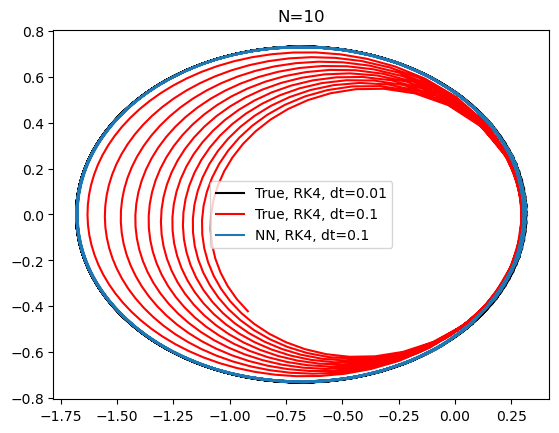

In [840]:
plt.plot(baseline_twobody_1["y_true"][0][:,0], baseline_twobody_1["y_true"][0][:,1], label="True, RK4, dt=0.01", color="black")
plt.plot(y_rk4_dt01[0,:], y_rk4_dt01[1,:], label="True, RK4, dt=0.1 ", color="red")
plt.plot(baseline_twobody_1["y_pred"][0][:,0], baseline_twobody_1["y_pred"][0][:,1], label="NN, RK4, dt=0.1")
plt.legend()
plt.title("N=10")

Text(0.5, 1.0, 'N=3, Tdecrochage=401')

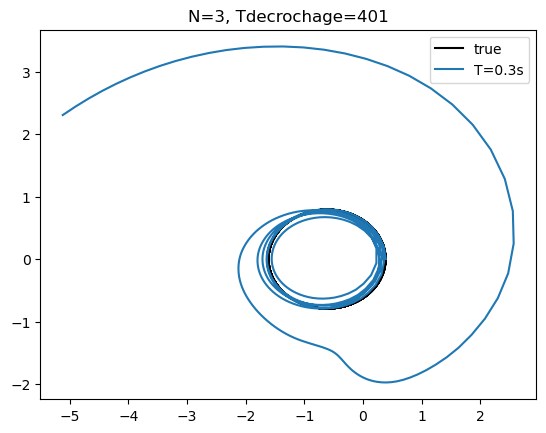

In [841]:
plt.figure()
time=451
k=65
plt.plot(baseline_twobody_1["y_true"][k][:,0], baseline_twobody_1["y_true"][k][:,1], label="true", color="black")
#plt.plot(baseline_twobody_03_longer["y_pred"][k][:time,0], baseline_twobody_03["y_pred"][k][:time,1], label="T=0.3s longer")
plt.plot(baseline_twobody_03["y_pred"][k][:time,0], baseline_twobody_03["y_pred"][k][:time,1], label="T=0.3s")
plt.legend()
plt.title(f'N=3, Tdecrochage={401}')

Text(0.5, 1.0, 'N=3, longer')

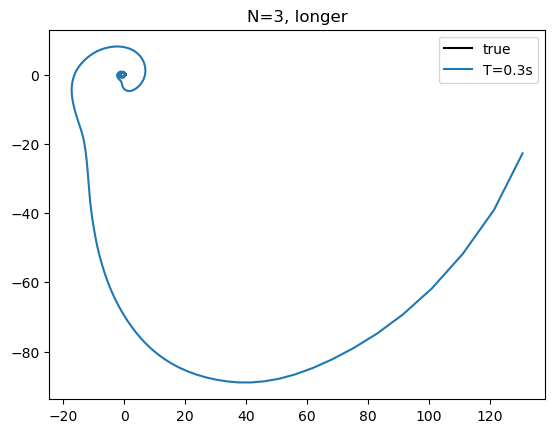

In [842]:
plt.figure()
time=451
k=baseline_twobody_03_longer["L2"].idxmax()
plt.plot(baseline_twobody_1["y_true"][k][:,0], baseline_twobody_1["y_true"][k][:,1], label="true", color="black")
#plt.plot(baseline_twobody_03_longer["y_pred"][k][:time,0], baseline_twobody_03["y_pred"][k][:time,1], label="T=0.3s longer")
plt.plot(baseline_twobody_03_longer["y_pred"][k][:time,0], baseline_twobody_03_longer["y_pred"][k][:time,1], label="T=0.3s")
plt.legend()
plt.title(f'N=3, longer')

Text(0.5, 1.0, 'N=5')

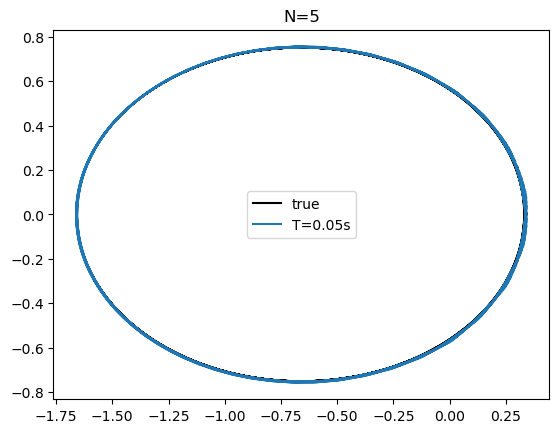

In [843]:
plt.figure()
time=-1
k=2
plt.plot(baseline_twobody_1["y_true"][k][:,0], baseline_twobody_1["y_true"][k][:,1], label="true", color="black")
#plt.plot(baseline_twobody_03_longer["y_pred"][k][:time,0], baseline_twobody_03["y_pred"][k][:time,1], label="T=0.3s longer")
plt.plot(baseline_twobody_05["y_pred"][k][:time,0], baseline_twobody_05["y_pred"][k][:time,1], label="T=0.05s")
plt.legend()
plt.title(f'N=5')

Text(0.5, 1.0, 'N=1')

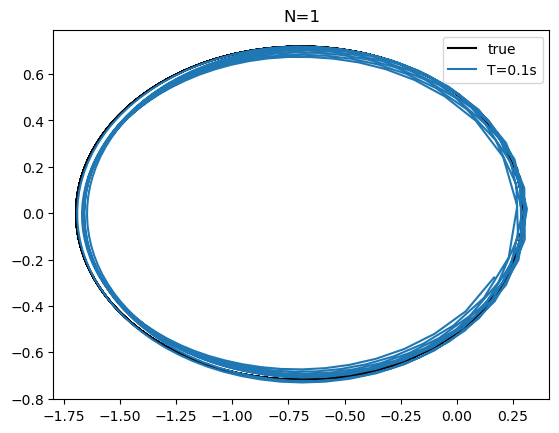

In [854]:
plt.figure()
time=-1
k=baseline_twobody_01["L2"].idxmax()
plt.plot(baseline_twobody_1["y_true"][k][:,0], baseline_twobody_1["y_true"][k][:,1], label="true", color="black")
#plt.plot(baseline_twobody_03_longer["y_pred"][k][:time,0], baseline_twobody_03["y_pred"][k][:time,1], label="T=0.3s longer")
plt.plot(baseline_twobody_01["y_pred"][k][:time,0], baseline_twobody_01["y_pred"][k][:time,1], label="T=0.1s")
plt.legend()
plt.title(f'N=1')

In [831]:
int(0.3/0.1), int(2/10)*100 +400

(2, 400)

In [824]:
data03 = np.load("/Users/mayajanvier/jax-phynity/data_exp/twobody_gridsearch/twobody0.3_train.npy", allow_pickle=True).item()
data1 = np.load("/Users/mayajanvier/jax-phynity/data_exp/twobody_gridsearch/twobody1.0_train.npy", allow_pickle=True).item()
data05 = np.load("/Users/mayajanvier/jax-phynity/data_exp/twobody_gridsearch/twobody0.5_train.npy", allow_pickle=True).item()
data01 = np.load("/Users/mayajanvier/jax-phynity/data_exp/twobody_gridsearch/twobody0.1_train.npy", allow_pickle=True).item()
data03["states"].shape, data1["states"].shape, data05["states"].shape, data01["states"].shape

((1320, 31, 4), (400, 101, 4), (800, 51, 4), (4000, 11, 4))

In [853]:
400 *100, 800*50, 4000*10, 1320*30

(40000, 40000, 40000, 39600)

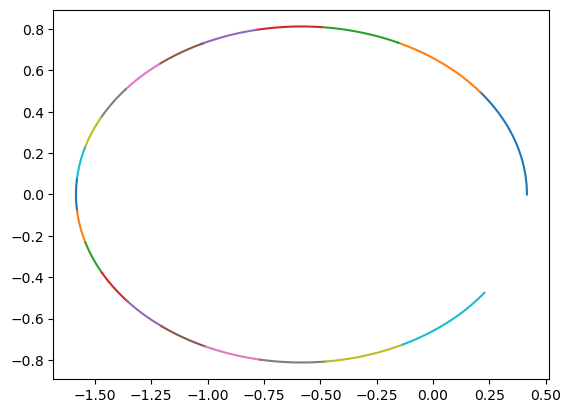

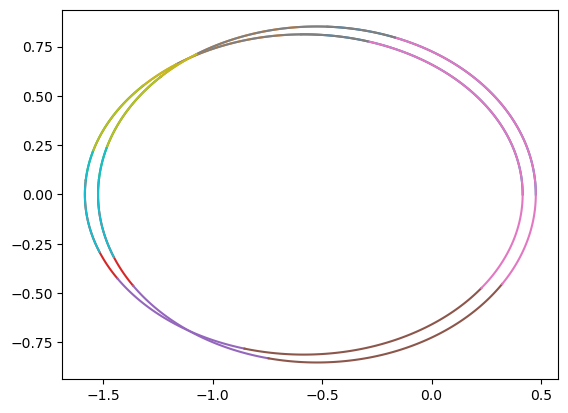

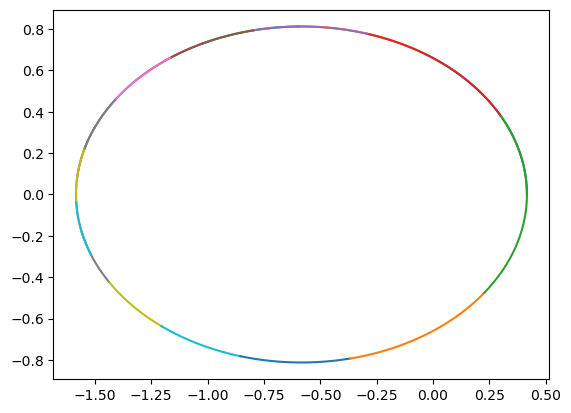

In [795]:
for k in range(len(data03["states"])):
    plt.plot(data03["states"][k][:,0], data03["states"][k][:,1], label="data 0.3")
    if k ==19:
        break
    
plt.figure()
for k in range(len(data1["states"])):
    plt.plot(data1["states"][k][:,0], data1["states"][k][:,1], label="data 1")
    if k ==19:
        break

plt.figure()
for k in range(len(data1["states"])):
    plt.plot(data05["states"][k][:,0], data05["states"][k][:,1], label="data 0.5")
    if k ==19:
        break

In [786]:
1320*31, 400*101, 800*51

(40920, 40400, 40800)

Text(0.5, 1.0, 'MSE (momentum) over time averaged over all trajectories')

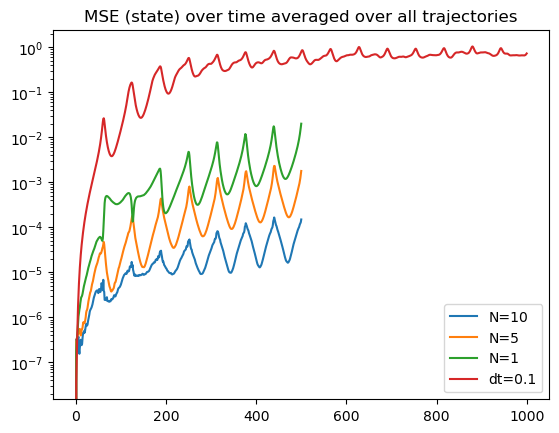

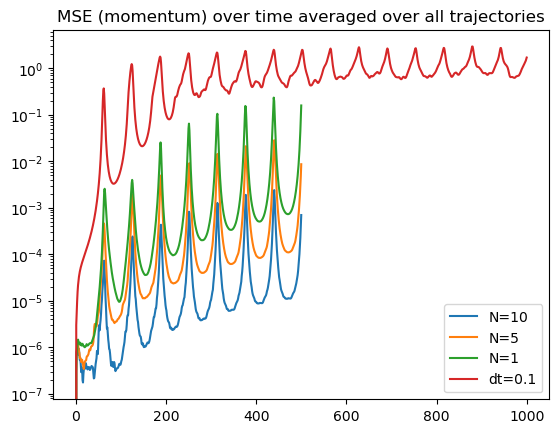

In [1255]:
# plots White et al. 

# plot White et al. MSE en fonction du temps, averaged over all trajectories
#plt.plot(baseline_twobody_5['L2_state_time'].mean(), label='N=50')
plt.plot(baseline_twobody_1['L2_state_time'].mean(), label='N=10')
plt.plot(baseline_twobody_05['L2_state_time'].mean(), label='N=5')
#plt.plot(baseline_twobody_03['L2_state_time'].mean(), label='N=3')
#plt.plot(baseline_twobody_03_longer['L2_state_time'].mean(), label='N=3, longer')
#plt.plot(baseline_twobody_02['L2_state_time'].mean(), label='N=2')
plt.plot(baseline_twobody_01["L2_state_time"].mean(), label='N=1')
plt.plot(baseline_twobody_dt01["L2_state_time"].mean(), label='dt=0.1')
plt.yscale('log')   
plt.legend()
plt.title("MSE (state) over time averaged over all trajectories")

plt.figure()
#plt.plot(baseline_twobody_5['L2_momentum_time'].mean(), label='N=50')
plt.plot(baseline_twobody_1['L2_momentum_time'].mean(), label='N=10')
plt.plot(baseline_twobody_05['L2_momentum_time'].mean(), label='N=5')
#plt.plot(baseline_twobody_03['L2_momentum_time'].mean(), label='N=3')
##plt.plot(baseline_twobody_03_longer['L2_momentum_time'].mean(), label='N=3, longer')
#plt.plot(baseline_twobody_02['L2_momentum_time'].mean(), label='N=2')
plt.plot(baseline_twobody_01["L2_momentum_time"].mean(), label='N=1')
plt.plot(baseline_twobody_dt01["L2_momentum_time"].mean(), label='dt=0.1')
plt.yscale('log')   
plt.legend()
plt.title("MSE (momentum) over time averaged over all trajectories")

Text(0.5, 1.0, 'L2 norms')

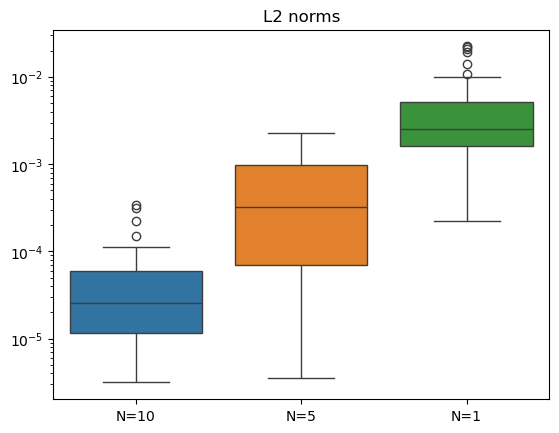

In [866]:
sns.boxplot(data=pd.DataFrame({
    #'N=50': baseline_twobody_5['L2'],
    'N=10': baseline_twobody_1['L2'],
    'N=5': baseline_twobody_05['L2'],
    #'N=3': baseline_twobody_03['L2'],
   # "N=3 ": baseline_twobody_03_longer['L2'],
    #'N=2': baseline_twobody_02['L2'],
    'N=1': baseline_twobody_01['L2']
}))
plt.yscale('log')
plt.title("L2 norms")

Conservation of momentum: $x \dot{y} - \dot{x} y = L_0$

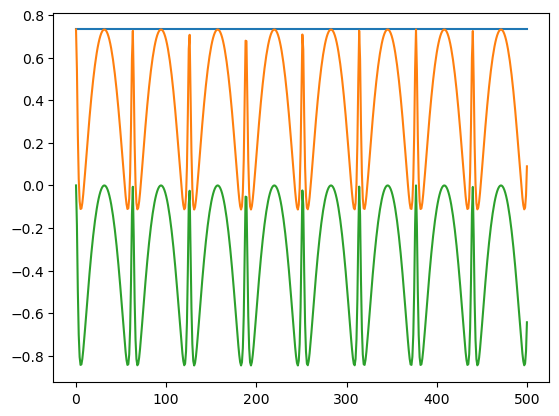

In [1208]:
plt.plot(baseline_twobody_1["y_true"][0][:,0] * baseline_twobody_1["y_true"][0][:,3] -baseline_twobody_1["y_true"][0][:,1] * baseline_twobody_1["y_true"][0][:,2])
plt.plot(baseline_twobody_1["y_true"][0][:,0] * baseline_twobody_1["y_true"][0][:,3])
plt.plot(baseline_twobody_1["y_true"][0][:,1] * baseline_twobody_1["y_true"][0][:,2])




Text(0.5, 1.0, 'Conservation of momentum over time for one trajectory 6')

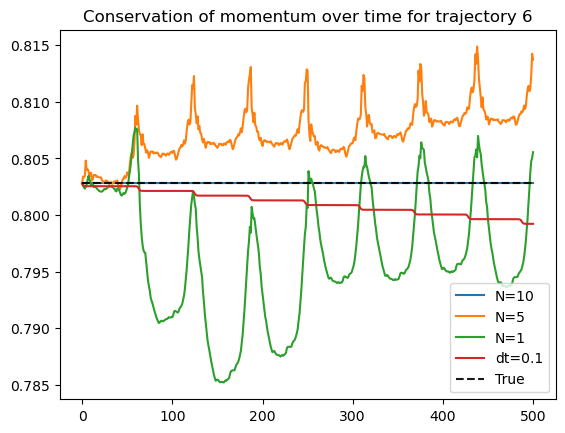

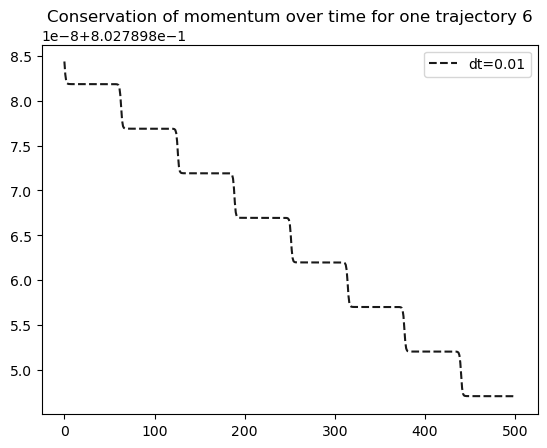

In [1260]:
# conservation of momentum 
k=6
plt.plot(baseline_twobody_1['momentum_true'][k], label='N=10')
plt.plot(baseline_twobody_05['momentum_pred'][k], label='N=5')
plt.plot(baseline_twobody_01['momentum_pred'][k], label='N=1')
plt.plot(baseline_twobody_dt01['momentum_pred'][k][:501], label='dt=0.1')
plt.plot(baseline_twobody_1['momentum_true'][k], label='True', color="black", linestyle='dashed', alpha=0.9)
plt.legend()
plt.title(f"Conservation of momentum over time for trajectory {k}")

plt.figure()
plt.plot(baseline_twobody_1['momentum_true'][k], label='dt=0.01', color="black", linestyle='dashed', alpha=0.9)
#plt.plot(baseline_twobody_dt01['momentum_pred'][k][:501], label='dt=0.1', color="red")
plt.legend()
plt.title(f"Conservation of momentum over time for one trajectory {k}")

Text(0.5, 1.0, 'Conservation of momentum over time averaged over all trajectories')

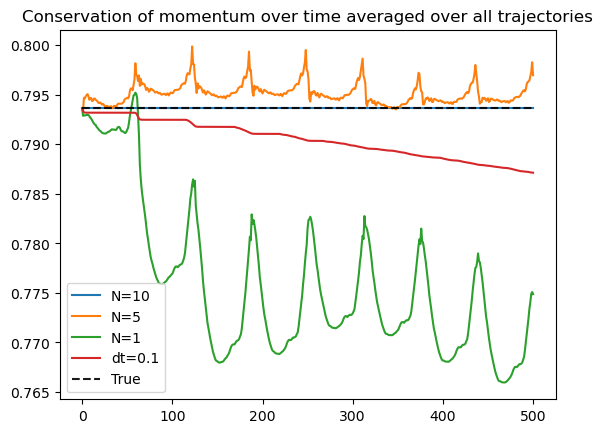

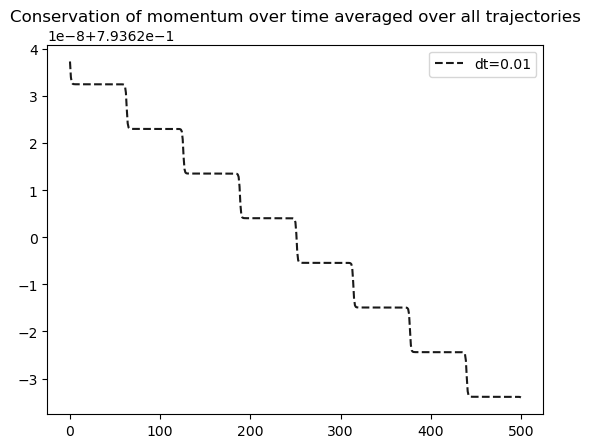

In [1267]:
# conservation of momentum 
k=6
plt.plot(baseline_twobody_1['momentum_true'].mean(), label='N=10')
plt.plot(baseline_twobody_05['momentum_pred'].mean(), label='N=5')
plt.plot(baseline_twobody_01['momentum_pred'].mean(), label='N=1')
plt.plot(baseline_twobody_dt01['momentum_pred'].mean()[:501], label='dt=0.1')
plt.plot(baseline_twobody_1['momentum_true'].mean(), label='True', color="black", linestyle='dashed', alpha=0.9)
plt.legend()
plt.title(f"Conservation of momentum over time averaged over all trajectories")
plt.figure()
plt.plot(baseline_twobody_1['momentum_true'].mean(), label='dt=0.01', color="black", linestyle='dashed', alpha=0.9)
#plt.plot(baseline_twobody_dt01['momentum_pred'][:,:501].mean(), label='dt=0.1', color="red")
plt.legend()
plt.title(f"Conservation of momentum over time averaged over all trajectories")


## 2. $L_\theta$ and $||J_{F_\theta}||$ vs $||J_F||$

In [11]:
dtTB=0.1
integration_method="RK4"

In [12]:
experiment_path1 = "/Users/mayajanvier/jax-phynity/data_exp/twobody_gridsearch/none_aug_1.0_2_odcg867i"
model_baseline_twobody_1 = load_best_model_dt(dtTB, experiment_path1, "twobody", integration_method, data_integration_method="RK4", dt_num=0.01, duration=50)

experiment_path03 = "/Users/mayajanvier/jax-phynity/data_exp/twobody_gridsearch/none_aug_0.3_5_pioi4o2d"
model_baseline_twobody03 =load_best_model_dt(dtTB, experiment_path03, "twobody", integration_method, data_integration_method="RK4", dt_num=0.01, duration=50)

/Users/mayajanvier/jax-phynity/data_exp/twobody_gridsearch/none_aug_1.0_2_odcg867i/model_1.879e-07.eqx
{'dt': 0.1, 'test data dt': 0.01, 'dt factor': 10}
/Users/mayajanvier/jax-phynity/data_exp/twobody_gridsearch/none_aug_0.3_5_pioi4o2d/model_3.166e-06.eqx
{'dt': 0.1, 'test data dt': 0.01, 'dt factor': 10}


In [857]:
experiment_path05 = "/Users/mayajanvier/jax-phynity/data_exp/twobody_gridsearch/none_aug_0.5_15_x94kqj0e"
model_baseline_twobody05 =load_best_model_dt(dtTB, experiment_path05, "twobody", integration_method, data_integration_method="RK4", dt_num=0.01, duration=50)

experiment_path01 = "/Users/mayajanvier/jax-phynity/data_exp/twobody_gridsearch/none_aug_0.1_12_6jwn1iuk"
model_baseline_twobody01 =load_best_model_dt(dtTB, experiment_path01, "twobody", integration_method, data_integration_method="RK4", dt_num=0.01, duration=50)

/Users/mayajanvier/jax-phynity/data_exp/twobody_gridsearch/none_aug_0.5_15_x94kqj0e/model_1.768e-07.eqx
{'dt': 0.1, 'test data dt': 0.01, 'dt factor': 10}
/Users/mayajanvier/jax-phynity/data_exp/twobody_gridsearch/none_aug_0.1_12_6jwn1iuk/model_2.136e-08.eqx
{'dt': 0.1, 'test data dt': 0.01, 'dt factor': 10}


In [13]:
yTB_50s = get_states(baseline_twobody_1, type='twobody')

(50100, 4) (4,)


In [859]:
yTB_50s_pred1 = get_states(baseline_twobody_1, type='twobody', bool_true=False)
yTB_50s_pred03 = get_states(baseline_twobody_03, type='twobody', bool_true=False)
yTB_50s_pred05 = get_states(baseline_twobody_05, type='twobody', bool_true=False)
yTB_50s_pred01 = get_states(baseline_twobody_01, type='twobody', bool_true=False)

(50100, 4) (4,)
(50100, 4) (4,)
(50100, 4) (4,)
(50100, 4) (4,)


In [15]:
jac_true_twobody = compute_jacobian_test(F_twobody, yTB_50s, bool_true=True)

In [858]:
jac_baseline_twobody1 = compute_jacobian_test(model_baseline_twobody_1, yTB_50s, bool_true=False)
jac_baseline_twobody03 = compute_jacobian_test(model_baseline_twobody03, yTB_50s, bool_true=False)
jac_baseline_twobody05 = compute_jacobian_test(model_baseline_twobody05, yTB_50s, bool_true=False)
jac_baseline_twobody01 = compute_jacobian_test(model_baseline_twobody01, yTB_50s, bool_true=False)

In [860]:
jac_baseline_twobody1_pred = compute_jacobian_test(model_baseline_twobody_1, yTB_50s_pred1, bool_true=False)
jac_baseline_twobody03_pred = compute_jacobian_test(model_baseline_twobody03, yTB_50s_pred03, bool_true=False)
jac_baseline_twobody05_pred = compute_jacobian_test(model_baseline_twobody05, yTB_50s_pred05, bool_true=False)
jac_baseline_twobody01_pred = compute_jacobian_test(model_baseline_twobody01, yTB_50s_pred01, bool_true=False)

Text(0.5, 1.0, 'Jacobian norms of 100 trajectories (their own predictions)')

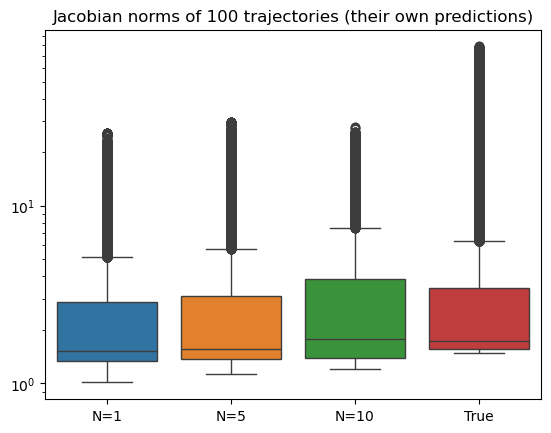

In [862]:
sns.boxplot(pd.DataFrame({
    #"N=3": jac_baseline_twobody03_pred,
    "N=1": jac_baseline_twobody01_pred,
    "N=5": jac_baseline_twobody05_pred,
    "N=10": jac_baseline_twobody1_pred,
    "True": jac_true_twobody
}))
plt.yscale("log")
plt.title("Jacobian norms of 100 trajectories (their own predictions)")

Text(0.5, 1.0, 'Jacobian norms of 100 true trajectories')

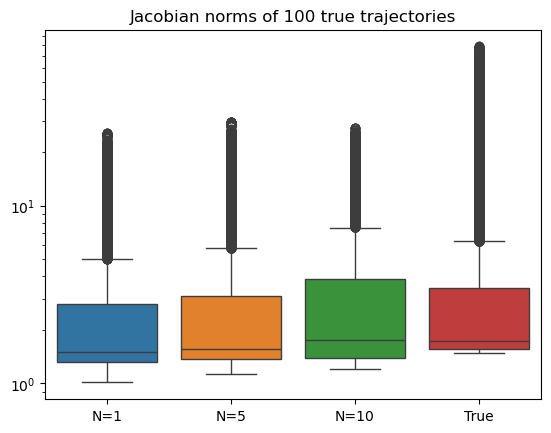

In [863]:
sns.boxplot(pd.DataFrame({
    #"N=3": jac_baseline_twobody03,
    "N=1": jac_baseline_twobody01,
    "N=5": jac_baseline_twobody05,
    "N=10": jac_baseline_twobody1,
    "True": jac_true_twobody
}))
plt.yscale("log")
plt.title("Jacobian norms of 100 true trajectories")

In [104]:
jac_baseline_twobody03.max(), jac_baseline_twobody1.max(), jac_true_twobody.max()

(Array(23.23212346, dtype=float64),
 Array(27.57814696, dtype=float64),
 Array(78.84399777, dtype=float64))

In [105]:
jac_baseline_twobody03.min(), jac_baseline_twobody1.min(), jac_true_twobody.min()

(Array(1.11709367, dtype=float64),
 Array(1.20535819, dtype=float64),
 Array(1.48688597, dtype=float64))

In [106]:
jac_baseline_twobody03.mean(), jac_baseline_twobody1.mean(), jac_true_twobody.mean()

(Array(3.37003942, dtype=float64),
 Array(3.61964559, dtype=float64),
 Array(5.07777276, dtype=float64))

In [103]:
# errors
((jac_baseline_twobody03-jac_true_twobody)**2).mean(), ((jac_baseline_twobody1-jac_true_twobody)**2).mean()

(Array(32.98435807, dtype=float64), Array(30.52202775, dtype=float64))

Mediane plutôt respectée, mais constantes de Lipschitz trop faibles/normes minimales trop basses. Sûrement signe que la jacobienne est différente.

## 3. $F_\theta$ vs $F$

In [81]:
out_2body = jax.vmap(F_twobody)(yTB_50s)
out_2body_1 = jax.vmap(model_baseline_twobody_1.model_aug)(yTB_50s)
out_2body_03 = jax.vmap(model_baseline_twobody03.model_aug)(yTB_50s)

In [83]:
offline_coord1 = np.mean((out_2body-out_2body_1)**2, axis=0)
offline_coord03 = np.mean((out_2body-out_2body_03)**2, axis=0)

In [88]:
print(f"Offline error mean: N=3: {np.mean((out_2body-out_2body_03)**2)}, N=10: {np.mean((out_2body-out_2body_1)**2)}")
for i, coord in enumerate(["x", "y", "x prime", "y prime"]):
    print(f"Offline error mean, {coord} coordinate: N=3: {offline_coord03[i]}, N=10: {offline_coord1[i]}")

Offline error mean: N=3: 0.0006953368457372895, N=10: 0.00013740558082259258
Offline error mean, x coordinate: N=3: 0.00010629881817990492, N=10: 3.5636083960924024e-05
Offline error mean, y coordinate: N=3: 5.138343643164463e-05, N=10: 2.326779437367841e-05
Offline error mean, x prime coordinate: N=3: 0.0015905523035236954, N=10: 0.00032315528606734743
Offline error mean, y prime coordinate: N=3: 0.0010331128248139137, N=10: 0.00016756315888842037


On voit que les erreurs de $F_\theta$ sont très similaires entre les deux modèles, avec plus d'erreurs sur les dérivées, notamment plus pour N=3 que N=10. 

## 4. Eigenvalues of $J_{F_\theta}$

In [20]:
def get_eigenvalues_jacobian(model, x):
    """Compute eigenvalues of the Jacobian of the model at point x."""
    J = jax.jacfwd(model)(x)
    eigvals = jnp.linalg.eigvals(J)
    return eigvals

In [21]:
#get_eigenvalues_jacobian = jax.jit(get_eigenvalues_jacobian)

In [22]:
eigens = jax.vmap(lambda x: get_eigenvalues_jacobian(model_baseline_twobody_1.model_aug, x))(yTB_50s)

In [23]:
true_eigens = jax.vmap(lambda x: get_eigenvalues_jacobian(F_twobody, x))(yTB_50s)

In [869]:
eigens_03 = jax.vmap(lambda x: get_eigenvalues_jacobian(model_baseline_twobody03.model_aug, x))(yTB_50s)
eigens_05 = jax.vmap(lambda x: get_eigenvalues_jacobian(model_baseline_twobody05.model_aug, x))(yTB_50s)
eigens_01 = jax.vmap(lambda x: get_eigenvalues_jacobian(model_baseline_twobody01.model_aug, x))(yTB_50s)

In [25]:
dt=0.1

/Users/mayajanvier/jax-phynity/metrics.py:296: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


Text(0.7, 1.0, 'True $J_F$ eigenvalues')

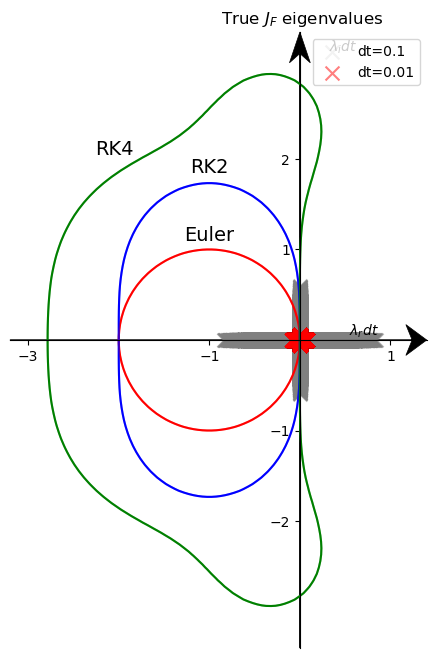

In [27]:
fig, ax = plot_stability_domains()
#fig, ax = plt.subplots()
ax.scatter(true_eigens.real*dt, true_eigens.imag*dt, label="dt=0.1", color='grey', s=100, marker="x", alpha=0.1)
ax.scatter(true_eigens.real*0.01, true_eigens.imag*0.01, label="dt=0.01", color='red', s=100, marker="x", alpha=0.5)
plt.legend()
plt.title(r"True $J_F$ eigenvalues")

Text(0.5, 1.0, '$J_{F_\\theta}$')

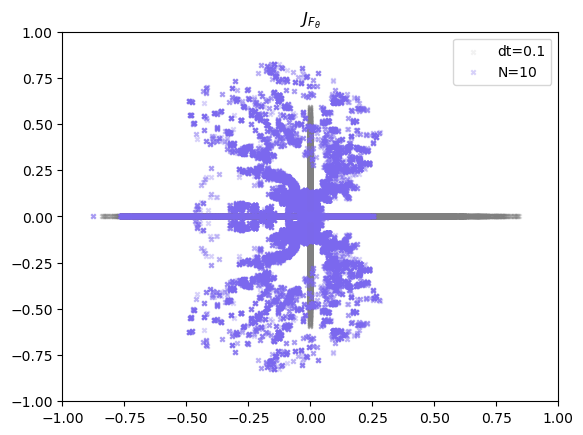

In [876]:
#fig, ax = plot_stability_domains()
fig, ax= plt.subplots()
ax.scatter(true_eigens.real*dt, true_eigens.imag*dt, label="dt=0.1", color='grey', s=10, marker="x", alpha=0.1)
ax.scatter(eigens.real*dt, eigens.imag*dt, label="N=10", color='mediumslateblue', s=10, marker="x", alpha=0.3)
plt.legend()
plt.xlim(-1,1)
plt.ylim(-1,1)
plt.title(r"$J_{F_\theta}$")

Text(0.7, 1.0, '$J_{F_\\theta}$')

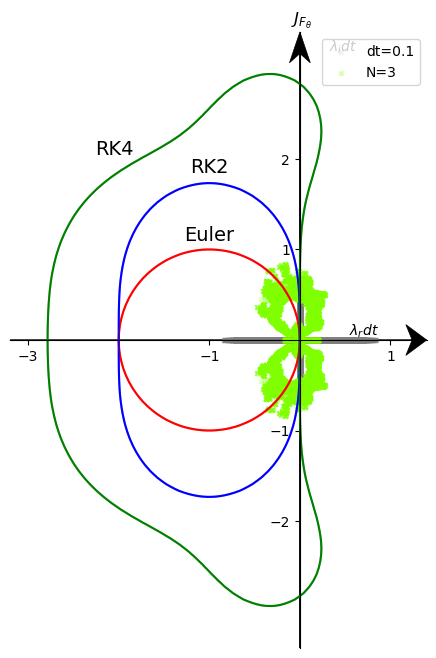

In [645]:
fig, ax = plot_stability_domains()
#fig, ax = plt.subplots()
ax.scatter(true_eigens.real*dt, true_eigens.imag*dt, label="dt=0.1", color='grey', s=10, marker="x", alpha=0.1)
ax.scatter(eigens_03.real*dt, eigens_03.imag*dt, label="N=3", color='chartreuse', s=10, marker="x", alpha=0.3)
plt.legend()
plt.title(r"$J_{F_\theta}$")

Text(0.5, 1.0, '$J_{F_\\theta}$')

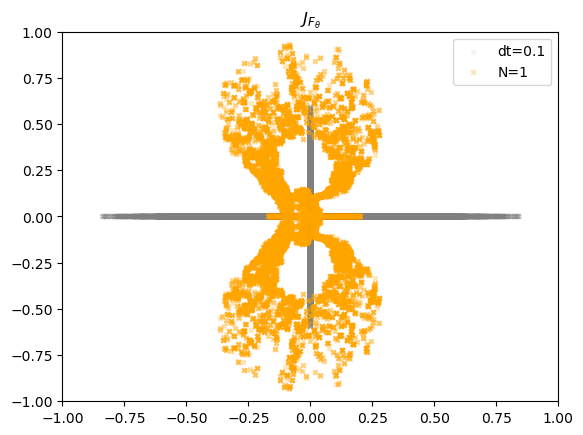

In [877]:
#fig, ax = plot_stability_domains()
fig, ax = plt.subplots()
ax.scatter(true_eigens.real*dt, true_eigens.imag*dt, label="dt=0.1", color='grey', s=10, marker="x", alpha=0.1)
ax.scatter(eigens_01.real*dt, eigens_01.imag*dt, label="N=1", color='orange', s=10, marker="x", alpha=0.3)
plt.legend()
plt.xlim(-1,1)
plt.ylim(-1,1)
plt.title(r"$J_{F_\theta}$")

Text(0.5, 1.0, '$J_{F_\\theta}$')

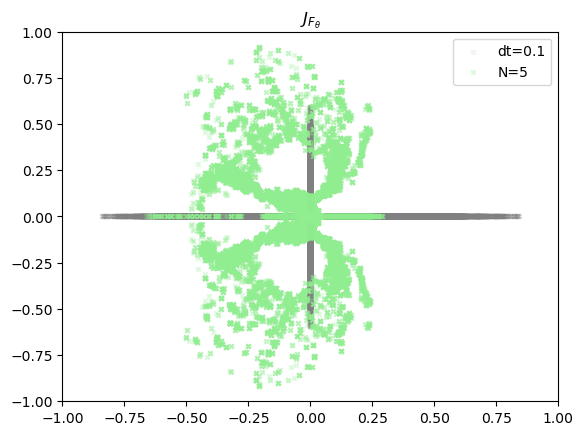

In [878]:
#fig, ax = plot_stability_domains()
fig, ax = plt.subplots()
ax.scatter(true_eigens.real*dt, true_eigens.imag*dt, label="dt=0.1", color='grey', s=10, marker="x", alpha=0.1)
ax.scatter(eigens_05.real*dt, eigens_05.imag*dt, label="N=5", color='lightgreen', s=10, marker="x", alpha=0.3)
plt.legend()
plt.xlim(-1,1)
plt.ylim(-1,1)
plt.title(r"$J_{F_\theta}$")

In [159]:
eigens_03[99], true_eigens[99]

(Array([-0.03920674+0.34911405j, -0.03920674-0.34911405j,
         0.11972668+0.07206332j,  0.11972668-0.07206332j],      dtype=complex128),
 Array([ 6.64819867e-01+0.j        , -6.64819867e-01+0.j        ,
        -1.79856420e-30+0.47009864j, -1.79856420e-30-0.47009864j],      dtype=complex128))

In [135]:
len(np.where(eigens.real >0)[0]), len(np.where(eigens_03.real >0)[0]), len(np.where(true_eigens.real >0)[0])

(81232, 88082, 99896)

On their own predictions:

In [879]:
eigens_03_own = jax.vmap(lambda x: get_eigenvalues_jacobian(model_baseline_twobody03.model_aug, x))(yTB_50s_pred03)
eigens_1_own = jax.vmap(lambda x: get_eigenvalues_jacobian(model_baseline_twobody_1.model_aug, x))(yTB_50s_pred1)
eigens_05_own = jax.vmap(lambda x: get_eigenvalues_jacobian(model_baseline_twobody05.model_aug, x))(yTB_50s_pred05)
eigens_01_own = jax.vmap(lambda x: get_eigenvalues_jacobian(model_baseline_twobody01.model_aug, x))(yTB_50s_pred01)

/Users/mayajanvier/jax-phynity/metrics.py:296: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


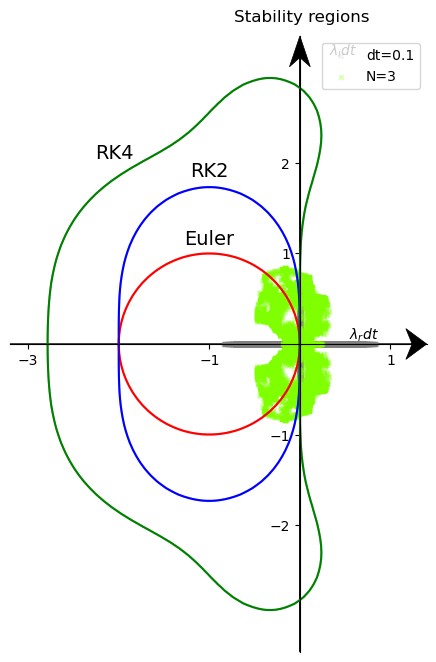

In [649]:
fig, ax = plot_stability_domains()
ax.scatter(true_eigens.real*dt, true_eigens.imag*dt, label="dt=0.1", color='grey', s=10, marker="x", alpha=0.1)
ax.scatter(eigens_03_own.real*dt, eigens_03_own.imag*dt, label="N=3", color='chartreuse', s=10, marker="x", alpha=0.3)
plt.legend()

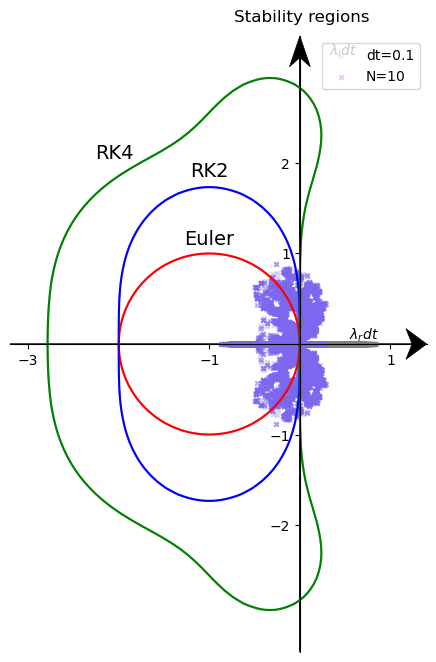

In [650]:
fig, ax = plot_stability_domains()
ax.scatter(true_eigens.real*dt, true_eigens.imag*dt, label="dt=0.1", color='grey', s=10, marker="x", alpha=0.1)
ax.scatter(eigens_1_own.real*dt, eigens_1_own.imag*dt, label="N=10", color='mediumslateblue', s=10, marker="x", alpha=0.3)
plt.legend()

/var/folders/d3/xx7sty_17dvbrq_tj5nl0_r40000gs/T/ipykernel_60399/1079648987.py:11: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[1].legend()


(-10.0, 10.0)

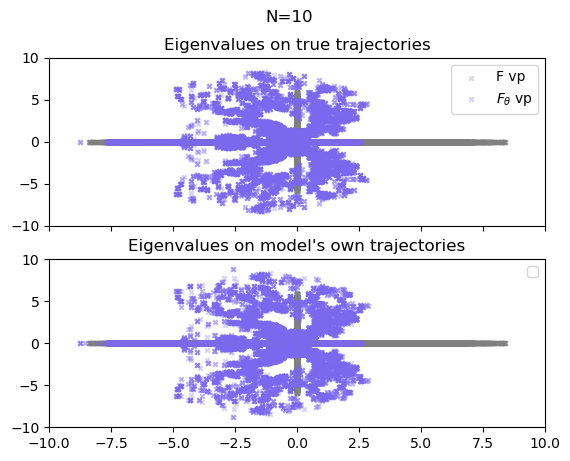

In [883]:
fig, ax = plt.subplots(2,1, sharex=True, sharey=True)
ax[0].scatter(true_eigens.real, true_eigens.imag, label="F vp", color='grey', s=10, marker="x", alpha=0.3)
ax[0].scatter(eigens.real, eigens.imag, label=r"$F_\theta$ vp", color='mediumslateblue', s=10, marker="x", alpha=0.3)
ax[0].set_title("Eigenvalues on true trajectories")

ax[1].scatter(true_eigens.real, true_eigens.imag, color='grey', s=10, marker="x", alpha=0.3)
ax[1].scatter(eigens_1_own.real, eigens_1_own.imag, color='mediumslateblue', s=10, marker="x", alpha=0.3)
ax[1].set_title("Eigenvalues on model's own trajectories")
fig.suptitle("N=10")
ax[0].legend()
ax[1].legend()
ax[0].set_xlim(-10,10)
ax[0].set_ylim(-10,10)
ax[1].set_xlim(-10,10)
ax[1].set_ylim(-10,10)

/var/folders/d3/xx7sty_17dvbrq_tj5nl0_r40000gs/T/ipykernel_60399/3949954609.py:11: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[1].legend()


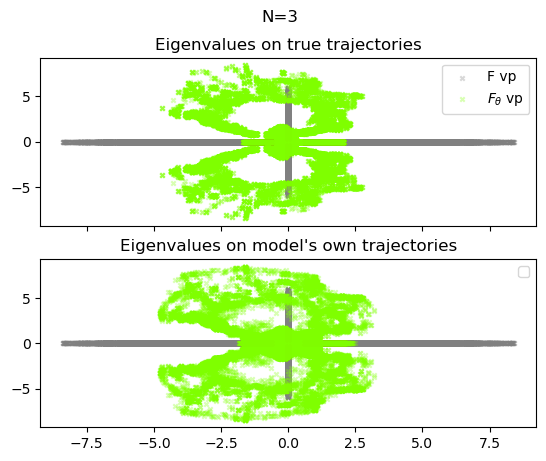

In [658]:
fig, ax = plt.subplots(2,1, sharex=True, sharey=True)
ax[0].scatter(true_eigens.real, true_eigens.imag, label="F vp", color='grey', s=10, marker="x", alpha=0.3)
ax[0].scatter(eigens_03.real, eigens_03.imag, label=r"$F_\theta$ vp", color='chartreuse', s=10, marker="x", alpha=0.3)
ax[0].set_title("Eigenvalues on true trajectories")

ax[1].scatter(true_eigens.real, true_eigens.imag, color='grey', s=10, marker="x", alpha=0.3)
ax[1].scatter(eigens_03_own.real, eigens_03_own.imag, color='chartreuse', s=10, marker="x", alpha=0.3)
ax[1].set_title("Eigenvalues on model's own trajectories")
fig.suptitle("N=3")
ax[0].legend()
ax[1].legend()

/var/folders/d3/xx7sty_17dvbrq_tj5nl0_r40000gs/T/ipykernel_60399/3453156106.py:11: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[1].legend()


(-10.0, 10.0)

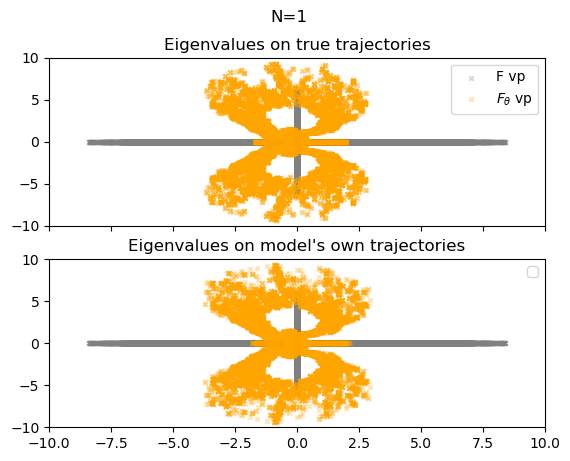

In [884]:
fig, ax = plt.subplots(2,1, sharex=True, sharey=True)
ax[0].scatter(true_eigens.real, true_eigens.imag, label="F vp", color='grey', s=10, marker="x", alpha=0.3)
ax[0].scatter(eigens_01.real, eigens_01.imag, label=r"$F_\theta$ vp", color='orange', s=10, marker="x", alpha=0.3)
ax[0].set_title("Eigenvalues on true trajectories")

ax[1].scatter(true_eigens.real, true_eigens.imag, color='grey', s=10, marker="x", alpha=0.3)
ax[1].scatter(eigens_01_own.real, eigens_01_own.imag, color='orange', s=10, marker="x", alpha=0.3)
ax[1].set_title("Eigenvalues on model's own trajectories")
fig.suptitle("N=1")
ax[0].legend()
ax[1].legend()
ax[0].set_xlim(-10,10)
ax[0].set_ylim(-10,10)
ax[1].set_xlim(-10,10)
ax[1].set_ylim(-10,10)

/var/folders/d3/xx7sty_17dvbrq_tj5nl0_r40000gs/T/ipykernel_60399/3539422834.py:11: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[1].legend()


(-10.0, 10.0)

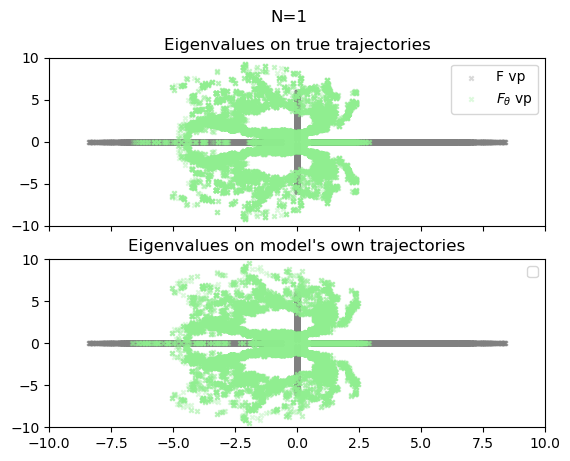

In [885]:
fig, ax = plt.subplots(2,1, sharex=True, sharey=True)
ax[0].scatter(true_eigens.real, true_eigens.imag, label="F vp", color='grey', s=10, marker="x", alpha=0.3)
ax[0].scatter(eigens_05.real, eigens_05.imag, label=r"$F_\theta$ vp", color='lightgreen', s=10, marker="x", alpha=0.3)
ax[0].set_title("Eigenvalues on true trajectories")

ax[1].scatter(true_eigens.real, true_eigens.imag, color='grey', s=10, marker="x", alpha=0.3)
ax[1].scatter(eigens_05_own.real, eigens_05_own.imag, color='lightgreen', s=10, marker="x", alpha=0.3)
ax[1].set_title("Eigenvalues on model's own trajectories")
fig.suptitle("N=1")
ax[0].legend()
ax[1].legend()
ax[0].set_xlim(-10,10)
ax[0].set_ylim(-10,10)
ax[1].set_xlim(-10,10)
ax[1].set_ylim(-10,10)

In [895]:
eps = 1e-1
np.max(true_eigens.real), np.min(true_eigens.real),np.max(true_eigens.imag), np.min(true_eigens.imag), len(np.where(true_eigens.real >0)[0]), len(np.where(np.sqrt(true_eigens.real**2 + true_eigens.imag**2) <eps)[0])
np.max(eigens_1_own.real), np.min(eigens_1_own.real),np.max(eigens.imag), np.min(eigens_1_own.imag), len(np.where(eigens_1_own.real >0)[0]), len(np.where(np.sqrt(eigens_1_own.real**2 + eigens_1_own.imag**2) <eps)[0])
np.max(eigens_05_own.real), np.min(eigens_05_own.real),np.max(eigens_05_own.imag), np.min(eigens_05_own.imag), len(np.where(eigens_05_own.real >0)[0]), len(np.where(np.sqrt(eigens_05_own.real**2 + eigens_05_own.imag**2) <eps)[0])
np.max(eigens_01_own.real), np.min(eigens_01_own.real),np.max(eigens_01_own.imag), np.min(eigens_01_own.imag), len(np.where(eigens_01_own.real >0)[0]), len(np.where(np.sqrt(eigens_01_own.real**2 + eigens_01_own.imag**2) <eps)[0])


(Array(2.92594621, dtype=float64),
 Array(-3.72481942, dtype=float64),
 Array(9.37719232, dtype=float64),
 Array(-9.37719232, dtype=float64),
 98908,
 7060)

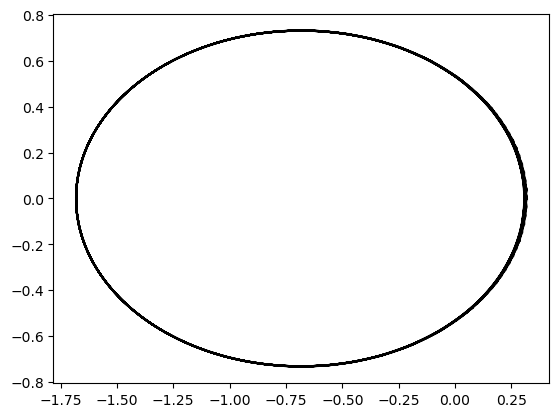

In [665]:
plt.plot(yTB_50s.reshape(100,-1,4)[0,:,0], yTB_50s.reshape(100,-1,4)[0,:,1], label="True", color="black")

In [660]:
len(np.where(eigens.real >0)[0]), len(np.where(eigens_03.real >0)[0]), len(np.where(true_eigens.real >0)[0])
len(np.where(eigens_1_own.real >0)[0]), len(np.where(eigens_03_own.real >0)[0]),

(81190, 95225)

In [750]:
eps=1e-1
len(np.where(np.sqrt(eigens.real**2 + eigens.imag**2)<eps)[0]), len(np.where(np.sqrt(eigens_03.real**2 + eigens_03.imag**2)<eps)[0]), len(np.where(np.sqrt(true_eigens.real**2 + true_eigens.imag**2)<eps)[0])
len(np.where(np.sqrt(eigens_1_own.real**2 + eigens_1_own.imag**2)<eps)[0]), len(np.where(np.sqrt(eigens_03_own.real**2 + eigens_03_own.imag**2)<eps)[0])

(12365, 2573)

In [899]:
def plot_time_shots_eigen_traj(id_traj, times, eigens_val, baseline, color, true_traj=False):
    for i, time in enumerate(times):
        fig, ax = plt.subplots(2,1, figsize=(5,5))
        if i == 1:
            old_time = times[0]
        vp_real, vp_imag = eigens_val.reshape(100,-1,4)[id_traj,:time,:].real, eigens_val.reshape(100,-1,4)[id_traj,:time,:].imag
        ax[1].plot(vp_real, vp_imag, 'x', label=f"time={time}", color=color )
        if true_traj:
            ax[0].plot(baseline["y_true"][id_traj][:time,0], baseline["y_true"][id_traj][:time,1], label=f"time={time}", color=color)
        else:
            ax[0].plot(baseline["y_pred"][id_traj][:time,0], baseline["y_pred"][id_traj][:time,1], label=f"time={time}", color=color)
        fig.suptitle(f"Trajectory {id_traj}, time={time}")
        ax[1].set_xlim([-10, 10])
        ax[1].set_ylim([-10, 10])
        if i > 0:
            vp_real_new, vp_imag_new = eigens_val.reshape(100,-1,4)[id_traj,old_time:time,:].real, eigens_val.reshape(100,-1,4)[id_traj,old_time:time,:].imag
            ax[0].plot(baseline["y_pred"][id_traj][old_time:time,0], baseline["y_pred"][id_traj][old_time:time,1], label=f"time={time} new", color='red')
            ax[1].plot(vp_real_new, vp_imag_new, 'x', label=f"time={time} new", color='red')
            old_time = time
            plt.show()

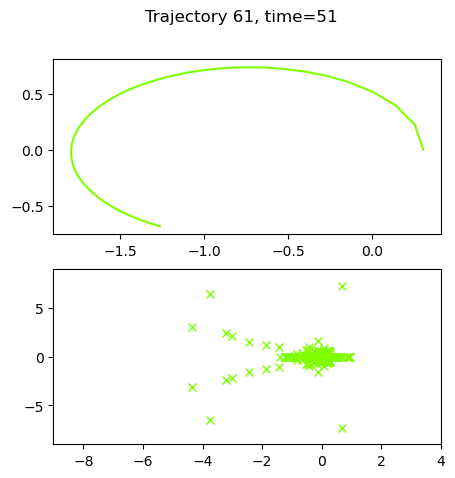

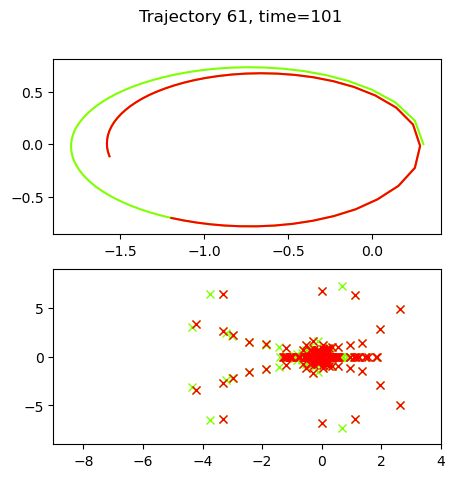

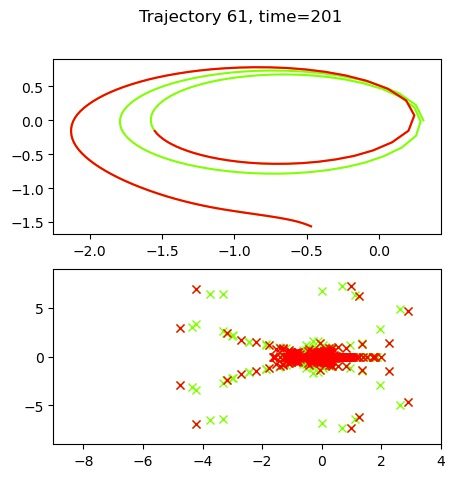

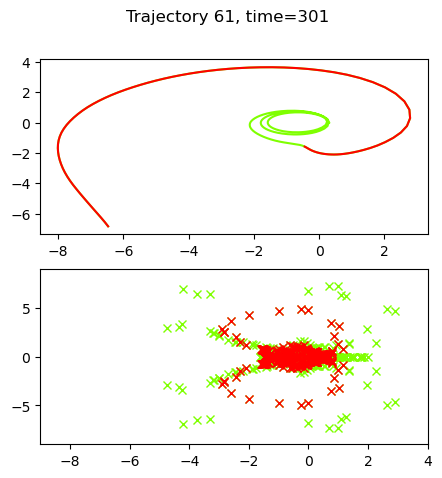

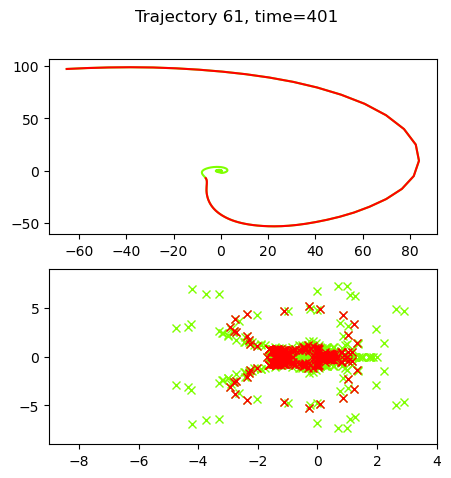

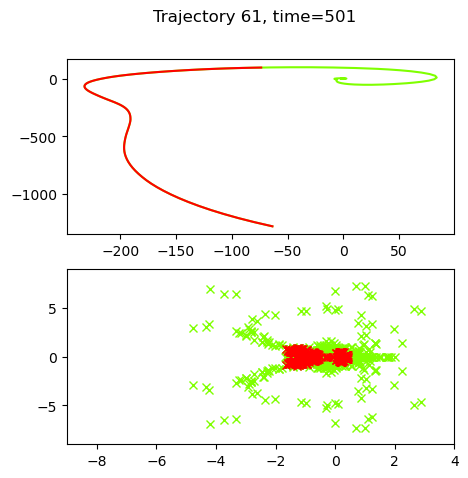

In [722]:
plot_time_shots_eigen_traj(k, [51,101,201,301,401,501], eigens_03_own, baseline_twobody_03, "chartreuse")

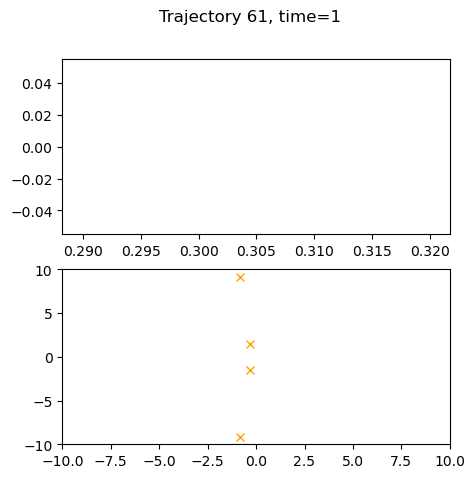

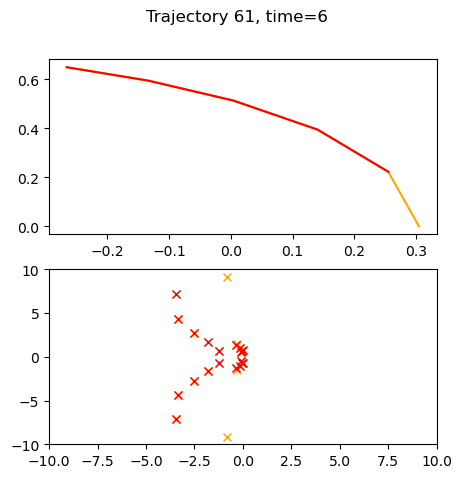

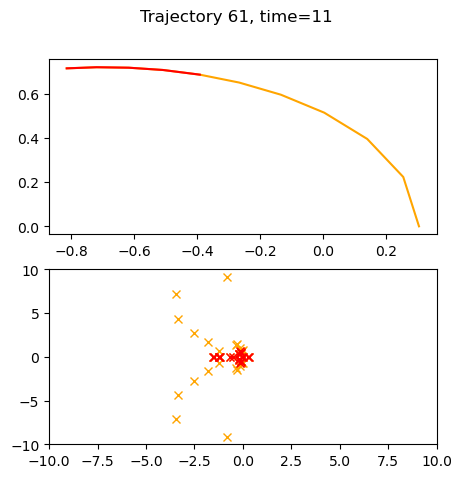

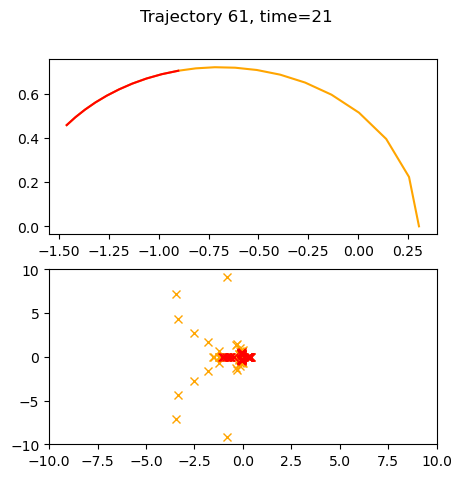

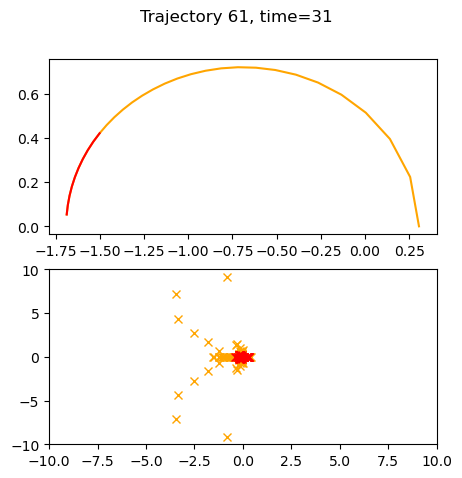

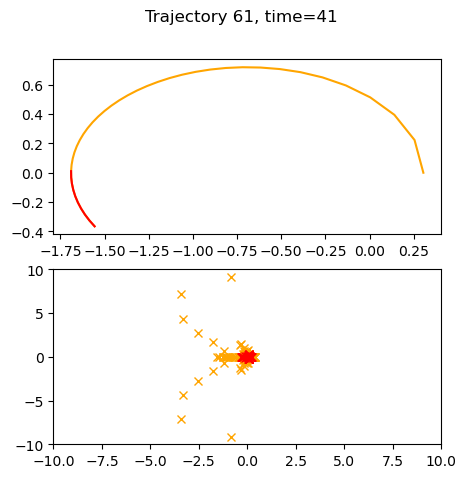

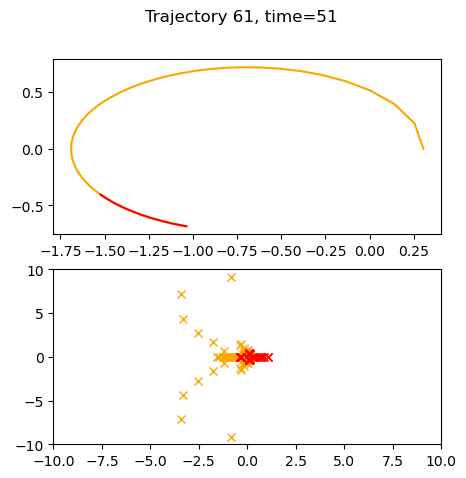

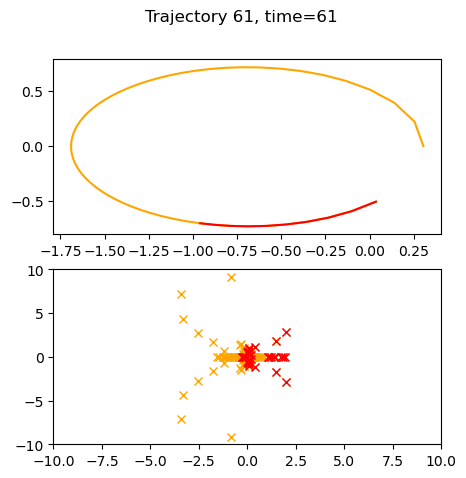

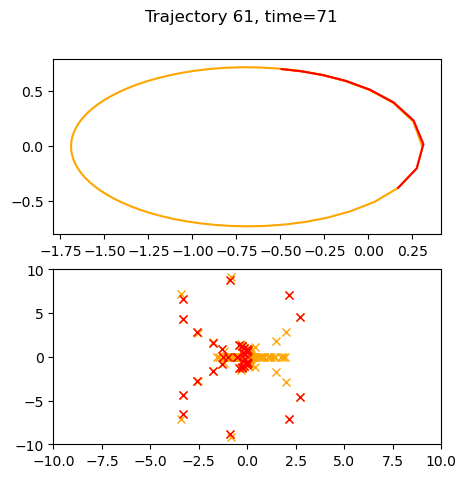

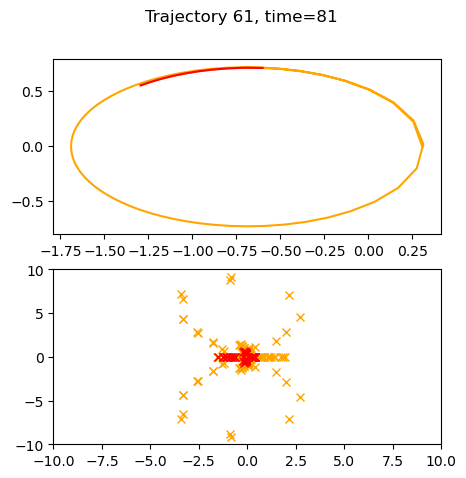

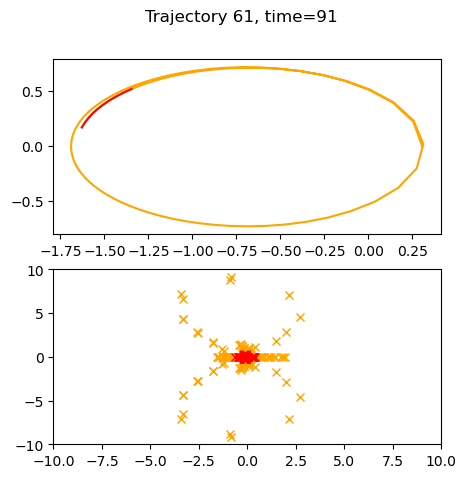

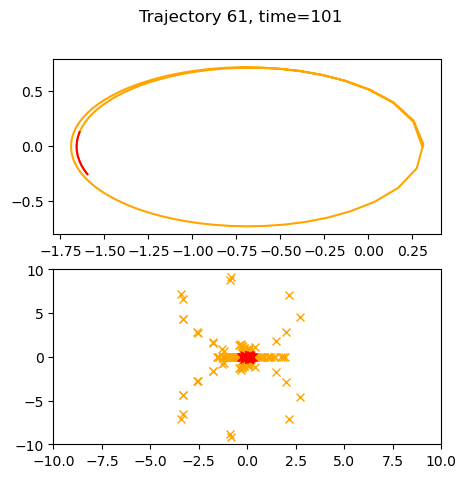

In [911]:
k = baseline_twobody_01["L2"].idxmax()
plot_time_shots_eigen_traj(k, [1,6, 11,21,31,41,51,61, 71, 81, 91, 101], eigens_01_own, baseline_twobody_01, "orange")

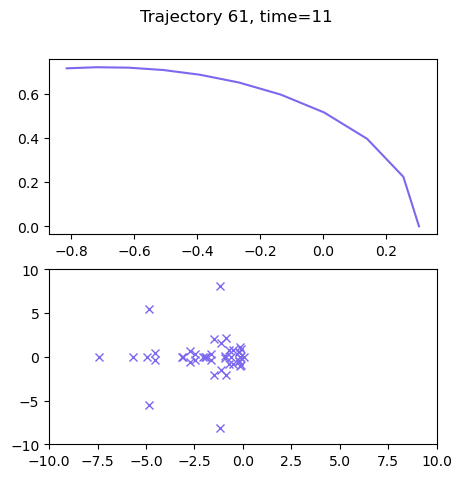

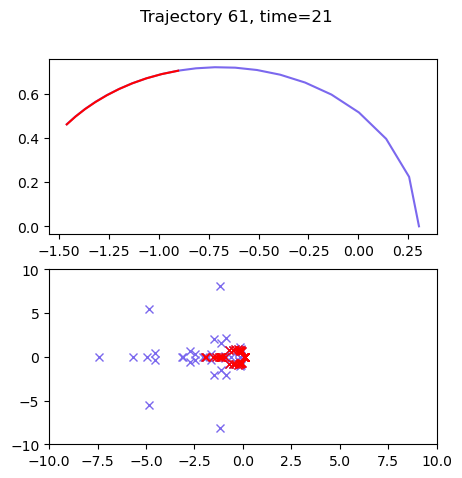

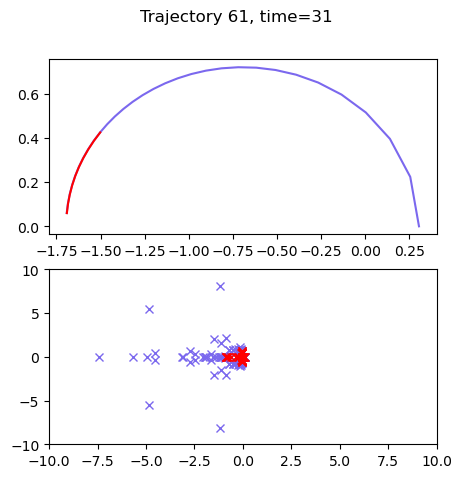

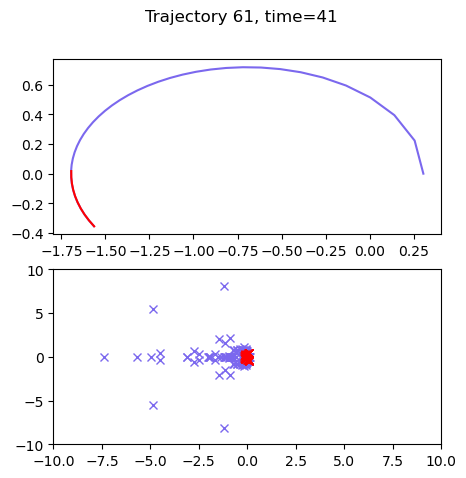

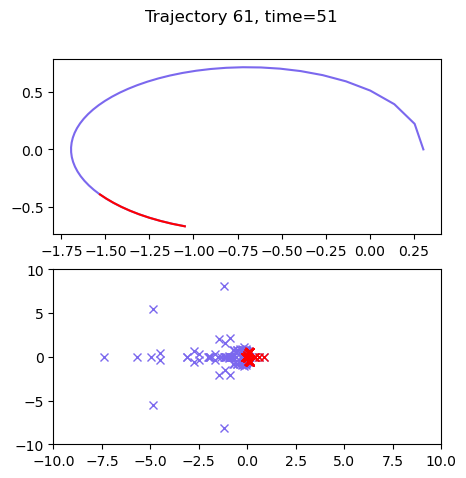

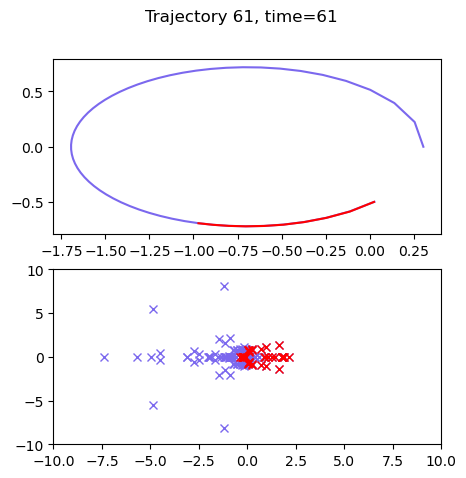

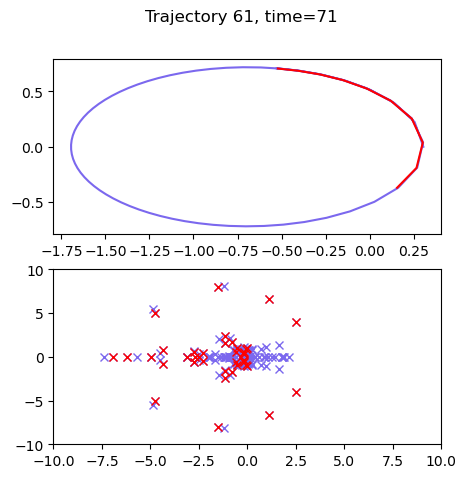

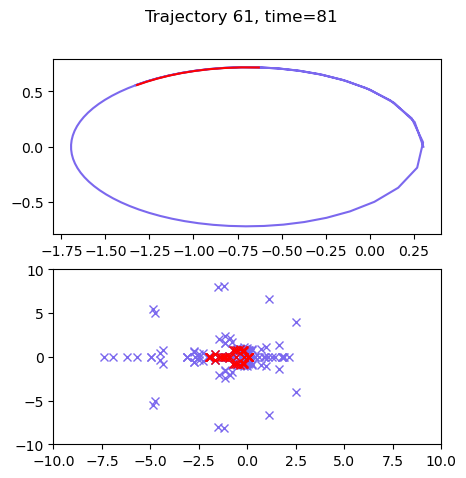

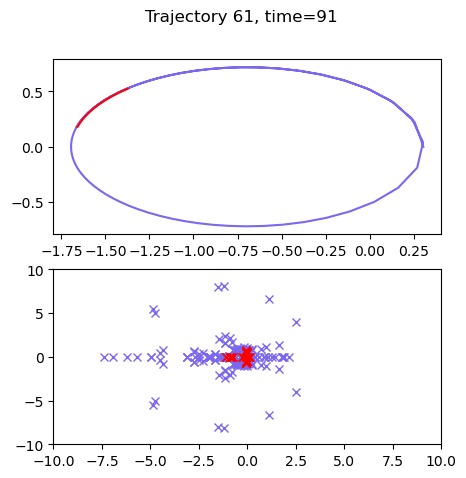

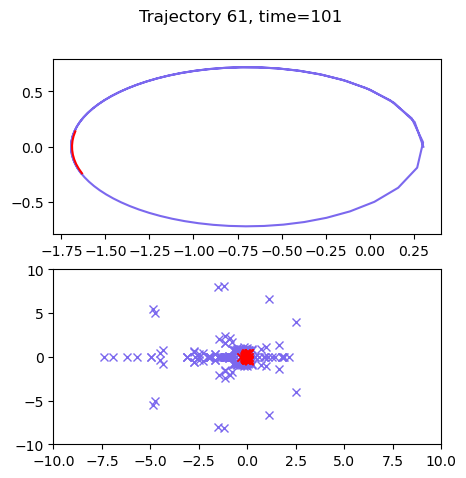

In [909]:
plot_time_shots_eigen_traj(k, [11,21,31,41,51,61, 71, 81, 91, 101], eigens_1_own, baseline_twobody_1, "mediumslateblue", true_traj=True)

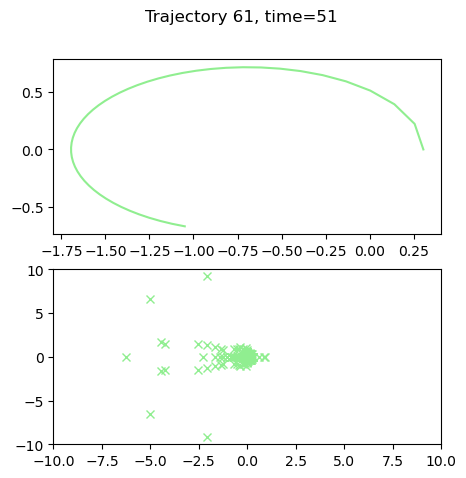

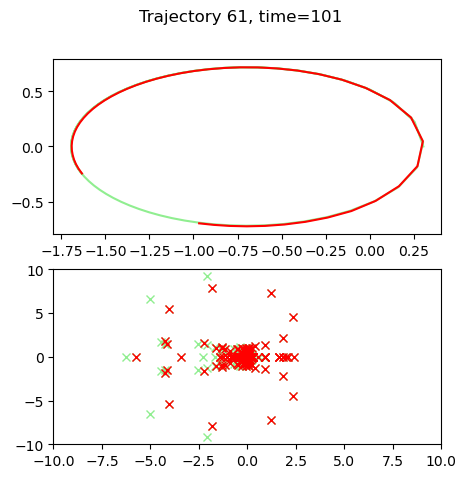

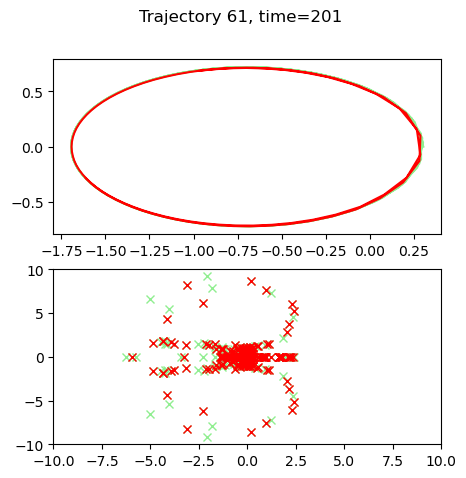

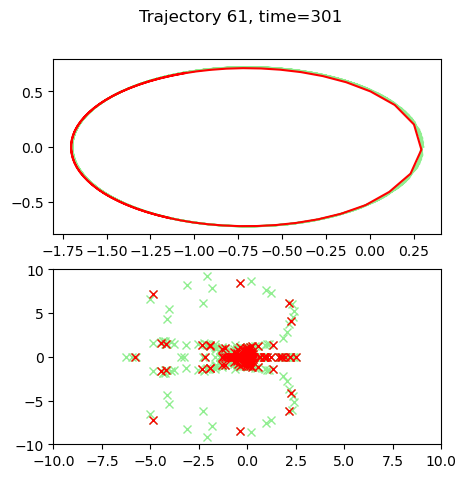

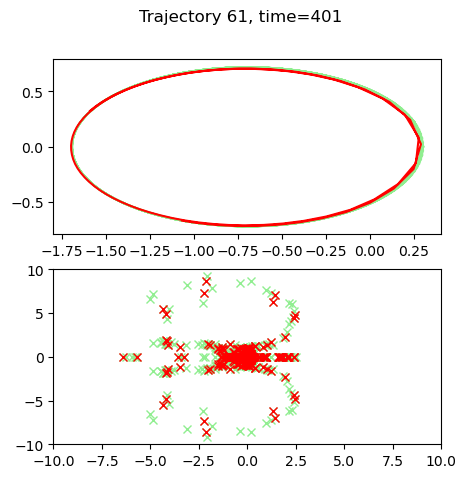

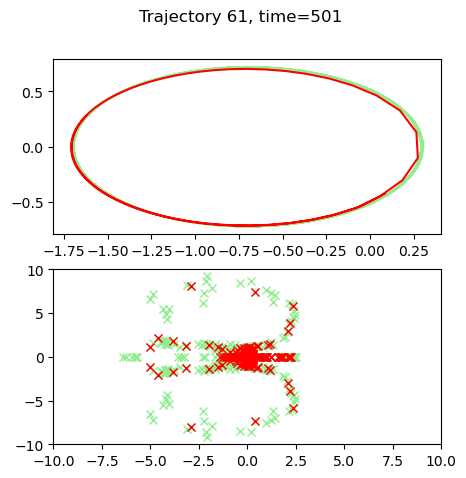

In [903]:
plot_time_shots_eigen_traj(k, [51,101,201,301,401,501], eigens_05_own, baseline_twobody_05, "lightgreen", true_traj=True)

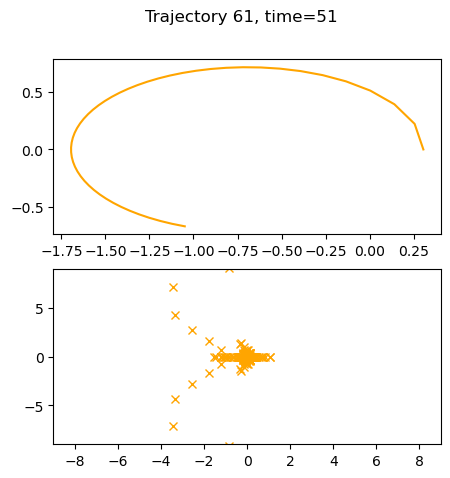

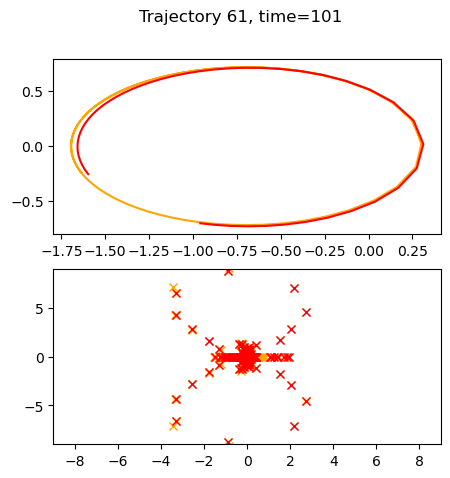

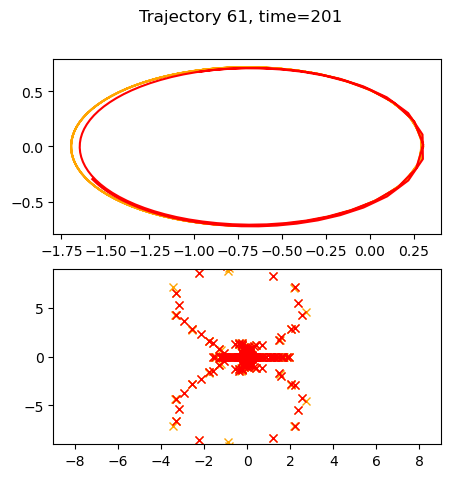

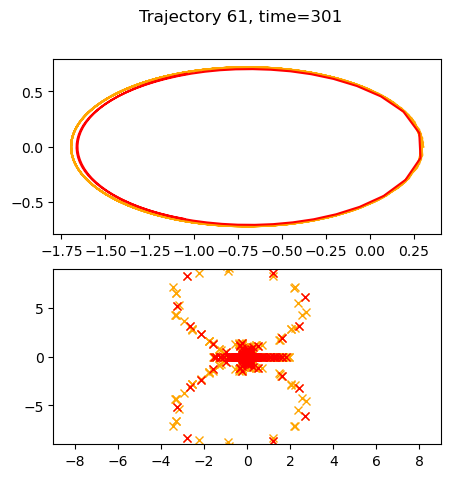

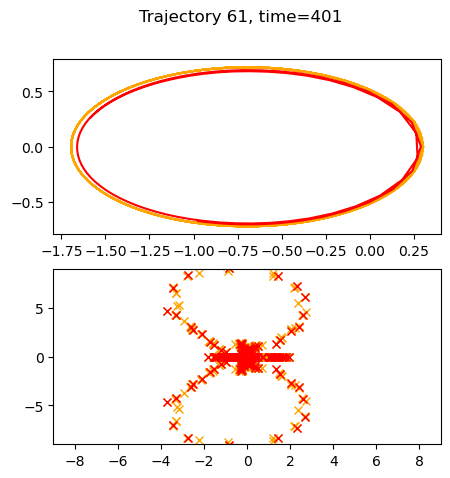

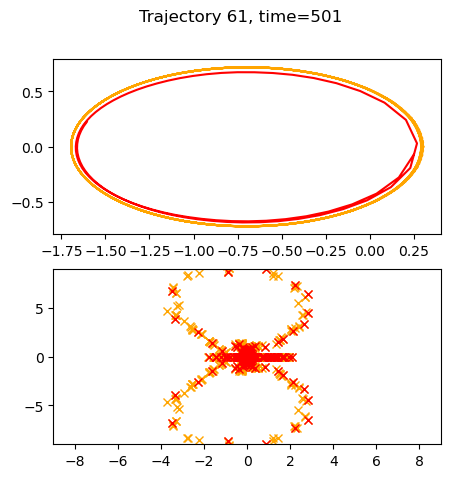

In [897]:
plot_time_shots_eigen_traj(k, [51,101,201,301,401,501], eigens_01_own, baseline_twobody_01, "orange", true_traj=True)

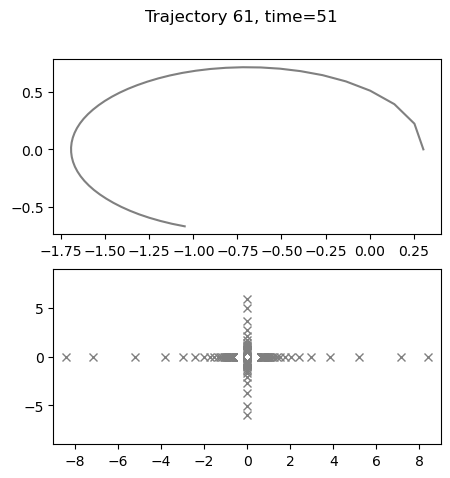

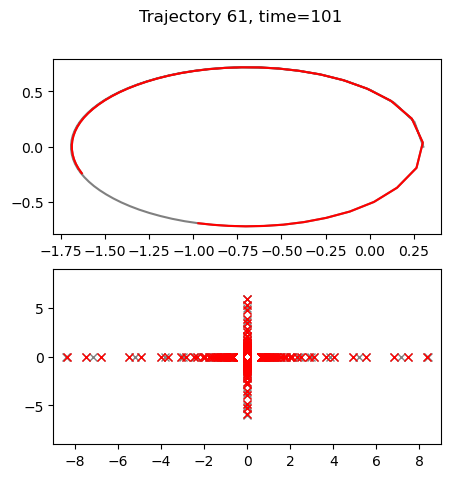

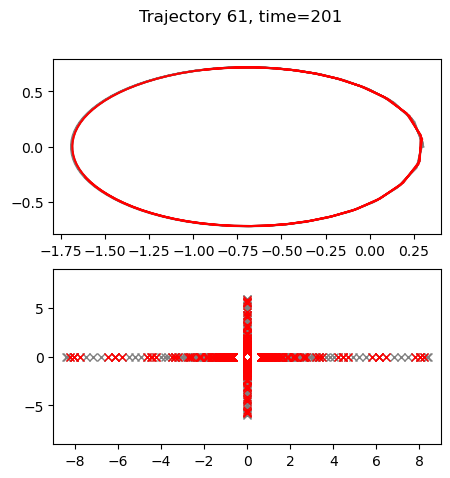

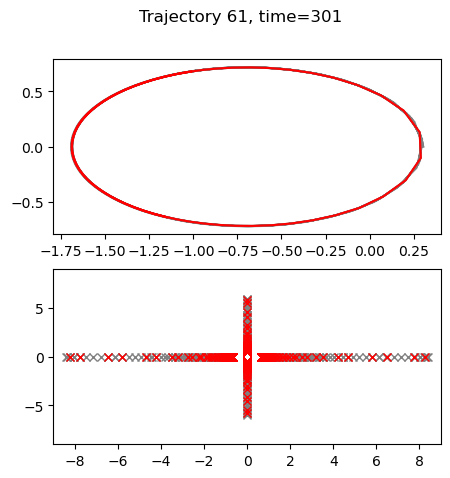

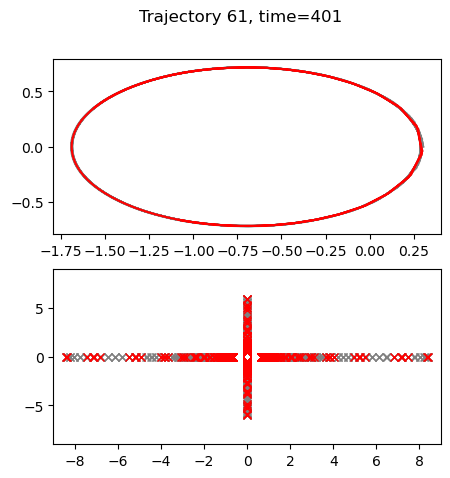

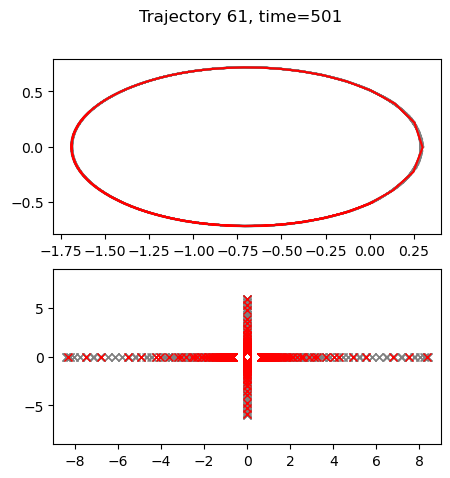

In [731]:
plot_time_shots_eigen_traj(k, np.array([51,101,201,301,401,501]), true_eigens, baseline_twobody_1, "grey")

In [737]:
y_rk4_dt01,_,_,_ = RK_solver_fixed(F, jnp.array(baseline_twobody_1["y_true"][k])[0,:], dt=0.1, num_steps=500, tableau=RK_tableaux['RK4'])
true_eigensdt01 = jax.vmap(lambda x: get_eigenvalues_jacobian(F_twobody, x))(y_rk4_dt01.T)

In [738]:
true_eigensdt01.shape

(501, 4)

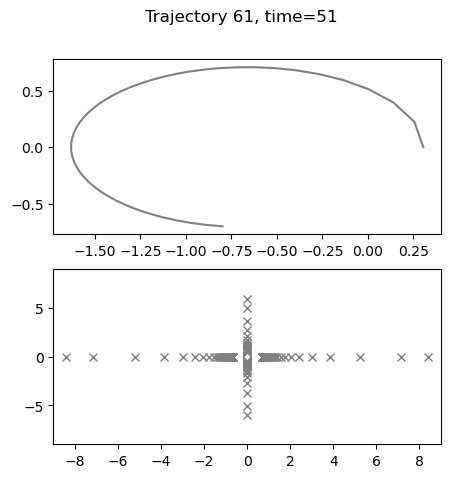

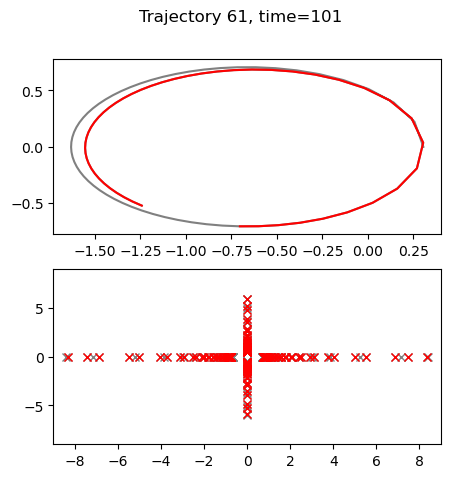

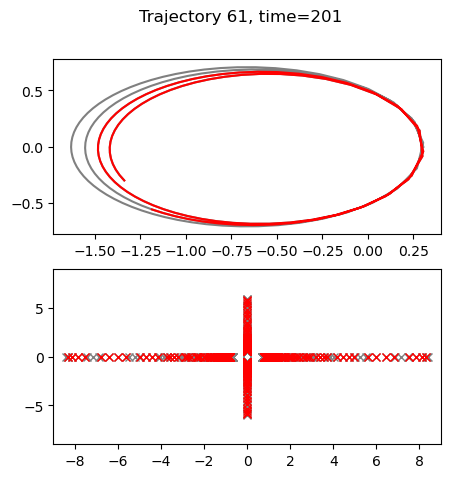

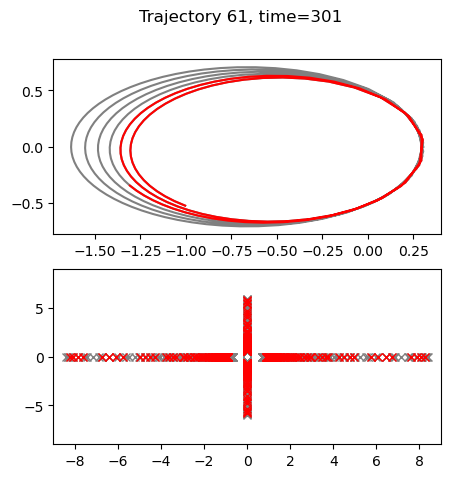

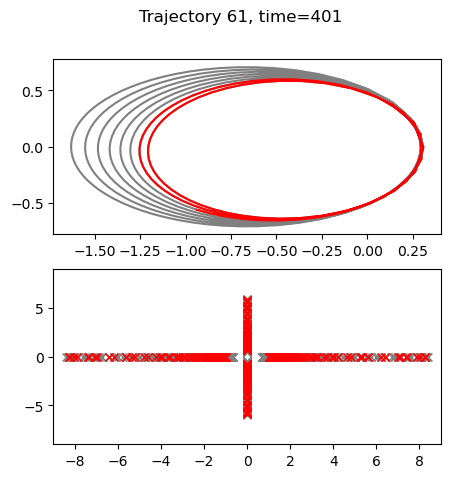

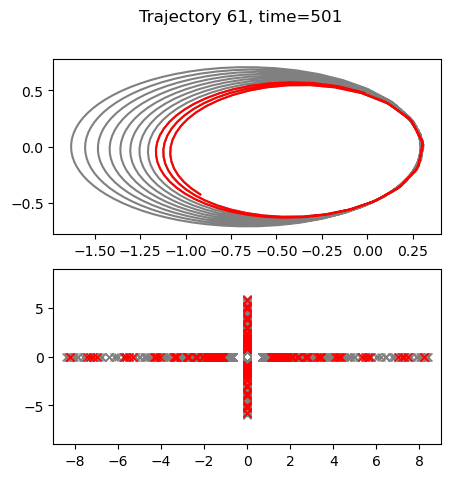

In [741]:
times = [51,101,201,301,401,501]
eigens_val = true_eigensdt01
color="grey"
baseline = y_rk4_dt01.T
for i, time in enumerate(times):
    fig, ax = plt.subplots(2,1, figsize=(5,5))
    if i == 1:
        old_time = times[0]
    vp_real, vp_imag = eigens_val[:time,:].real, eigens_val[:time,:].imag
    ax[1].plot(vp_real, vp_imag, 'x', label=f"time={time}", color=color )
    ax[0].plot(baseline[:time,0], baseline[:time,1], label=f"time={time}", color=color)
    fig.suptitle(f"Trajectory {k}, time={time}")
    ax[1].set_xlim([-9, 9])
    ax[1].set_ylim([-9, 9])
    if i > 0:
        vp_real_new, vp_imag_new = eigens_val[old_time:time,:].real, eigens_val[old_time:time,:].imag
        ax[0].plot(baseline[old_time:time,0], baseline[old_time:time,1], label=f"time={time} new", color='red')
        ax[1].plot(vp_real_new, vp_imag_new, 'x', label=f"time={time} new", color='red')
        old_time = time
        plt.show()

# Rigid body

In [1186]:
true_rigid_dt01 = np.load("/Users/mayajanvier/jax-phynity/data_exp/rigidbody_gridsearch/rigidbody400_0.1_test.npy", allow_pickle=True).item()
true_rigid_dt001 = np.load("/Users/mayajanvier/jax-phynity/data_exp/rigidbody_gridsearch/rigidbody400_0.01_test.npy", allow_pickle=True).item()
true_rigid_dt1 = np.load("/Users/mayajanvier/jax-phynity/data_exp/rigidbody_gridsearch/rigidbody400_1.0_test.npy", allow_pickle=True).item()
true_rigid_dt01["states"].shape, true_rigid_dt001["states"].shape, true_rigid_dt1["states"].shape

((100, 4001, 3), (100, 40001, 3), (100, 401, 3))

In [1191]:
np.mean(true_rigid_dt01["states"] - true_rigid_dt001["states"][:,::10,:]), np.mean(true_rigid_dt1["states"] - true_rigid_dt01["states"][:,::10,:])

(-3.268789139664366e-09, -0.00010884100186297348)

In [1270]:
true_rigid_dt01["states"].shape

(100, 4001, 3)

Text(0.5, 1.0, 'Conservation of angular momentum over time averaged over all trajectories')

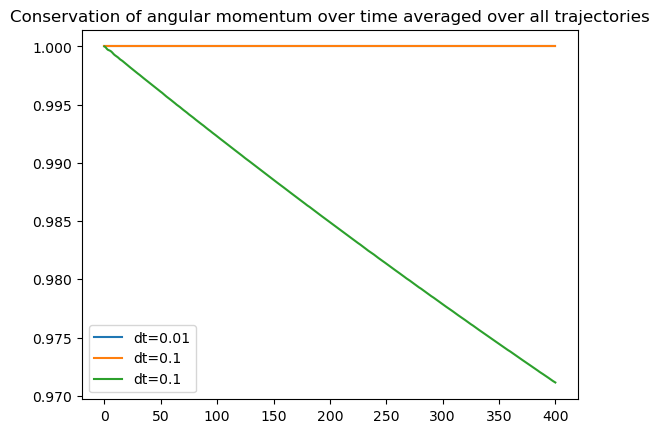

In [1280]:
plt.plot((true_rigid_dt001["states"][:,::100,0]**2 + true_rigid_dt001["states"][:,::100,1]**2+ true_rigid_dt001["states"][:,::100,2]**2).mean(axis=0), label="dt=0.01")
plt.plot((true_rigid_dt01["states"][:,::10,0]**2 + true_rigid_dt01["states"][:,::10,1]**2+ true_rigid_dt01["states"][:,::10,2]**2).mean(axis=0), label="dt=0.1")
plt.plot((true_rigid_dt1["states"][:,::,0]**2 + true_rigid_dt1["states"][:,::,1]**2+ true_rigid_dt1["states"][:,::,2]**2).mean(axis=0), label="dt=0.1")
plt.legend()
plt.title("Conservation of angular momentum over time averaged over all trajectories")


Text(0.5, 1.0, 'rigid body')

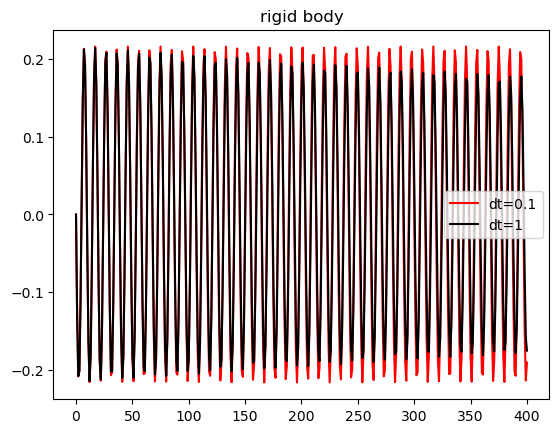

In [1268]:
plt.plot(true_rigid_dt01["states"][0][::10,1], label="dt=0.1", color="red")
#plt.plot(true_rigid_dt001["states"][0][:,1], label="dt=0.01", color="black")
plt.plot(true_rigid_dt1["states"][0][::,1], label="dt=1", color="black")
plt.legend()

plt.title("rigid body")


# Lorenz dt_num=dt_model=0.01

In [539]:
def F_lorenz(s,t):
    x, y, z = s
    sigma = 10.0
    rho = 28.0
    beta = 8.0 / 3.0
    x_prime = sigma * (y - x)
    y_prime = x * (rho - z) - y
    z_prime = x * y - beta * z
    return jnp.array([x_prime, y_prime, z_prime])

## 1. Long-term performances

In [159]:
baseline_lorenz_001=pd.read_json("/Users/mayajanvier/jax-phynity/data_exp/lorenz_gridsearch/none_aug_0.01_2_lj5ayrlu/model_6.202e-03_longrun_dt_100.0_0.01.json").T
baseline_lorenz_003=pd.read_json("/Users/mayajanvier/jax-phynity/data_exp/lorenz_gridsearch/none_aug_0.03_8_fv6pi5km/model_8.426e-02_longrun_dt_100.0_0.01.json").T
baseline_lorenz_05=pd.read_json("/Users/mayajanvier/jax-phynity/data_exp/lorenz_gridsearch/none_aug_0.5_6_az5bbul5/model_2.792e+01_longrun_dt_100.0_0.01.json").T

In [160]:
baseline_lorenz_001_01=pd.read_json("/Users/mayajanvier/jax-phynity/data_exp/lorenz_gridsearch/none_aug_0.01_2_lj5ayrlu/model_6.202e-03_longrun_dt_100.0_0.1.json").T
baseline_lorenz_003_01=pd.read_json("/Users/mayajanvier/jax-phynity/data_exp/lorenz_gridsearch/none_aug_0.03_8_fv6pi5km/model_8.426e-02_longrun_dt_100.0_0.1.json").T
baseline_lorenz_05_01=pd.read_json("/Users/mayajanvier/jax-phynity/data_exp/lorenz_gridsearch/none_aug_0.5_6_az5bbul5/model_2.792e+01_longrun_dt_100.0_0.1.json").T

In [382]:
def compute_metrics_lorenz(data, data_true=None):
    if data_true is not None:
        data["y_true"] = data_true.values
    data["y_true"] = data["y_true"].apply(lambda x: np.array(x))
    data["y_pred"] = data["y_pred"].apply(lambda x: np.array(x))
    data["L2"] = data.apply(lambda x: np.mean(np.array((x["y_true"] - x["y_pred"])**2)), axis=1)
    data["L2_5s"] = data.apply(lambda x: np.mean(np.array((x["y_true"][:,:501] - x["y_pred"][:,:501])**2)), axis=1)
    data["L2_0.5s"] = data.apply(lambda x: np.mean(np.array((x["y_true"][:,:51] - x["y_pred"][:,:51])**2)), axis=1)
    data["L2_0.1s"] = data.apply(lambda x: np.mean(np.array((x["y_true"][:,:11] - x["y_pred"][:,:11])**2)), axis=1)

    data["L2_state_time"] = data.apply(lambda x: np.array((x["y_true"] - x["y_pred"])**2)[:,:].mean(axis=1), axis=1)

    # keep same bins for true and pred to be comparable, true as reference
    for i, key in enumerate(["x_min", "y_min", "z_min"]):
        data[key] = data.apply(lambda x: np.min(x["y_true"][:,i]), axis=1)
    for i, key in enumerate(["x_max", "y_max", "z_max"]):
        data[key] = data.apply(lambda x: np.max(x["y_true"][:,i]), axis=1)

    # compute pdf
    data["x_pdf_true"] = data.apply(lambda x: np.histogram(x["y_true"][:,0], bins=50, range=(x["x_min"], x["x_max"]), density=True)[0], axis=1)
    data["x_pdf_pred"] = data.apply(lambda x: np.histogram(x["y_pred"][:,0], bins=50, range=(x["x_min"], x["x_max"]), density=True)[0],axis=1)
    
    data["y_pdf_true"] = data.apply(lambda x: np.histogram(x["y_true"][:,1], bins=50, range=(x["y_min"], x["y_max"]), density=True)[0], axis=1)
    data["y_pdf_pred"] = data.apply(lambda x: np.histogram(x["y_pred"][:,1], bins=50, range=(x["y_min"], x["y_max"]), density=True)[0],axis=1)
    
    data["z_pdf_true"] = data.apply(lambda x: np.histogram(x["y_true"][:,2], bins=50, range=(x["z_min"], x["z_max"]), density=True)[0], axis=1)
    data["z_pdf_pred"] = data.apply(lambda x: np.histogram(x["y_pred"][:,2], bins=50, range=(x["z_min"], x["z_max"]), density=True)[0],axis=1)

    # Add small epsilon to avoid log(0)
    epsilon = 1e-10
    for key in ["x_pdf_true", "x_pdf_pred", "y_pdf_true", "y_pdf_pred", "z_pdf_true", "z_pdf_pred"]:
        data[key] = data[key].apply(lambda x: x + epsilon)

    # KL divergence
    data["KL_x"] = data.apply(lambda x: entropy(x["x_pdf_true"], x["x_pdf_pred"]), axis=1)
    data["KL_y"] = data.apply(lambda x: entropy(x["y_pdf_true"], x["y_pdf_pred"]), axis=1)
    data["KL_z"] = data.apply(lambda x: entropy(x["z_pdf_true"], x["z_pdf_pred"]), axis=1)
    return data

In [383]:
baseline_lorenz_001=compute_metrics_lorenz(baseline_lorenz_001)
baseline_lorenz_003=compute_metrics_lorenz(baseline_lorenz_003)
baseline_lorenz_05 = compute_metrics_lorenz(baseline_lorenz_05)

In [384]:
baseline_lorenz_001_01=compute_metrics_lorenz(baseline_lorenz_001_01)
baseline_lorenz_003_01=compute_metrics_lorenz(baseline_lorenz_003_01)
baseline_lorenz_05_01 = compute_metrics_lorenz(baseline_lorenz_05_01)

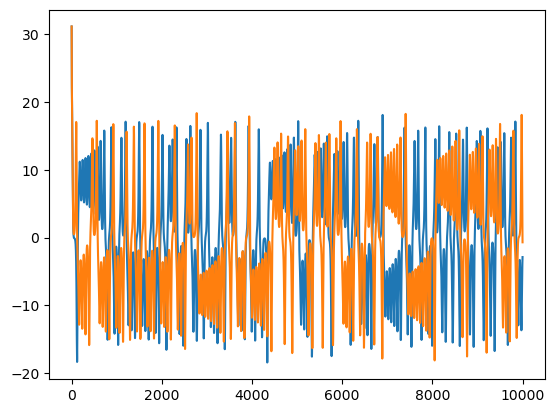

In [227]:
#plt.plot((baseline_lorenz_001["y_pred"][0][:,0]-baseline_lorenz_001["y_true"][0][:,0])**2)
plt.plot(baseline_lorenz_001["y_pred"][0][:,0])
plt.plot(baseline_lorenz_001["y_true"][0][:,0])


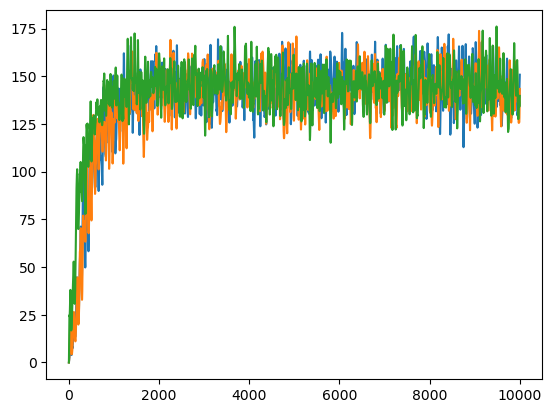

In [263]:
plt.plot(baseline_lorenz_001["L2_state_time"].mean())
plt.plot(baseline_lorenz_003["L2_state_time"].mean())
plt.plot(baseline_lorenz_05["L2_state_time"].mean())

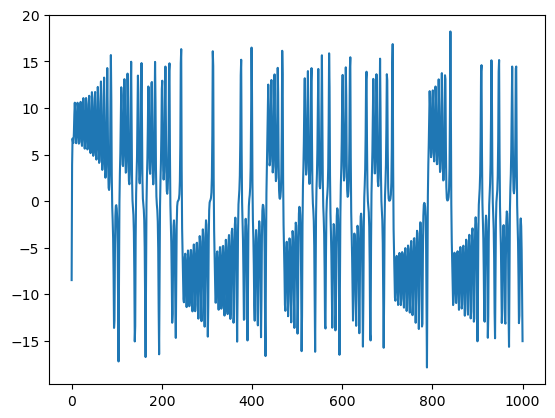

In [235]:
k=47

plt.plot(baseline_lorenz_001_01["y_true"][k][:,0])

In [241]:
baseline_lorenz_001_01["L2_state_time"][8].mean()

157.242919016523

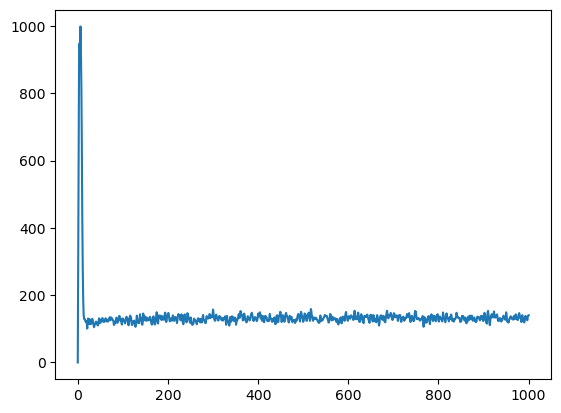

In [237]:
#plt.plot(baseline_lorenz_001_01["L2_state_time"].mean())
#plt.plot(baseline_lorenz_003_01["L2_state_time"].mean())
plt.plot(baseline_lorenz_05_01["L2_state_time"].mean())

Text(0.5, 1.0, '74')

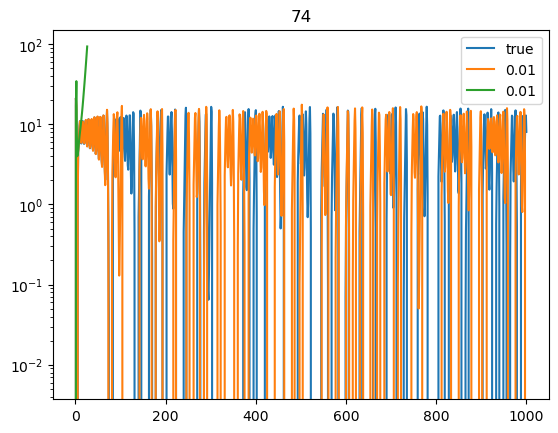

In [643]:
k = baseline_lorenz_05_01["KL_x"].idxmin()
plt.plot(baseline_lorenz_05_01["y_true"][k][:,0], label="true")
# plt.plot(baseline_lorenz_05_01["y_pred"][k][:,0], label="0.5")
# plt.plot(baseline_lorenz_003_01["y_pred"][k][:,0], label="0.03")
plt.plot(baseline_lorenz_001["y_pred"][k][::10,0], label="0.01")
plt.plot(baseline_lorenz_001_01["y_pred"][k][:27,0], label="0.01")
plt.legend()
plt.yscale("log")
plt.title(k)


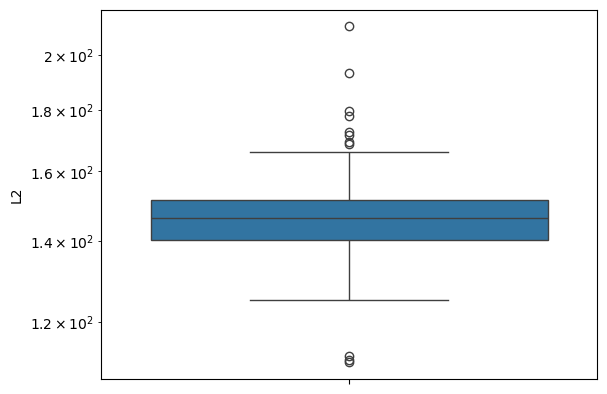

In [319]:
sns.boxplot(baseline_lorenz_001_01["L2"][np.where(baseline_lorenz_001_01["L2"] <500)[0]])
plt.yscale("log")

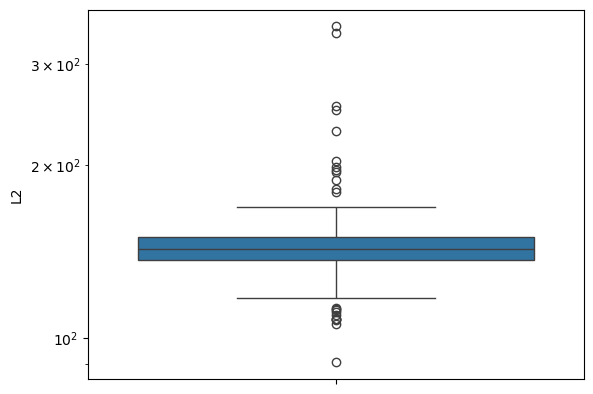

In [337]:
sns.boxplot(baseline_lorenz_003_01["L2"][np.where(baseline_lorenz_003_01["L2"] <500)[0]])
plt.yscale("log")

140

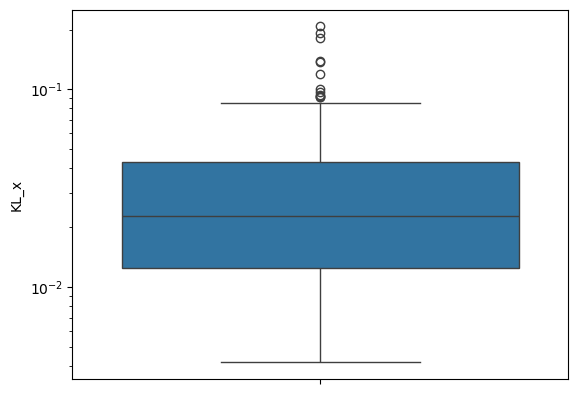

In [390]:
sns.boxplot(baseline_lorenz_001["KL_x"])
plt.yscale("log")
baseline_lorenz_001["KL_x"].idxmin()

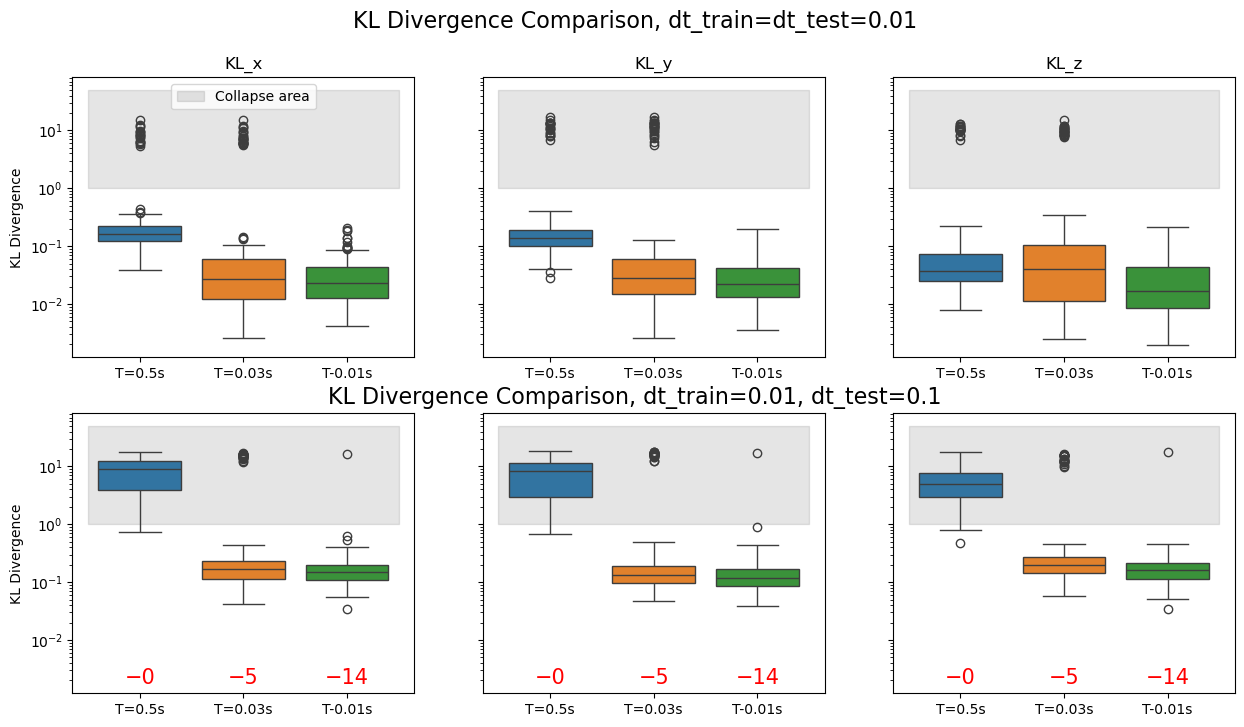

In [509]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharey=True)

for i, metric in enumerate(["KL_x", "KL_y", "KL_z"]):
    sns.boxplot(
        data=pd.DataFrame({
            'T=0.5s': baseline_lorenz_05[metric][np.where(baseline_lorenz_05["L2"]<500)[0]],
            'T=0.03s': baseline_lorenz_003[metric][np.where(baseline_lorenz_003["L2"]<500)[0]],
            'T-0.01s': baseline_lorenz_001[metric][np.where(baseline_lorenz_001["L2"]<500)[0]],
        }),
        ax=axes[0][i]
    )
    axes[0][i].fill_between([-0.5, 2.5],1, 5e1, label="Collapse area", color='black', alpha=0.1)
    axes[0][i].set_title(metric)
    axes[0][i].set_yscale("log")
    axes[0][i].set_ylabel("KL Divergence" if i == 0 else "")
axes[0][0].legend()
for i, metric in enumerate(["KL_x", "KL_y", "KL_z"]):
    mask_05 = baseline_lorenz_05_01["L2"] < 500
    mask_003 = baseline_lorenz_003_01["L2"] < 500
    mask_001 = baseline_lorenz_001_01["L2"] < 500
    sns.boxplot(
        data=pd.DataFrame({
            'T=0.5s': baseline_lorenz_05_01[metric][np.where(baseline_lorenz_05_01["L2"]<500)[0]],
            'T=0.03s': baseline_lorenz_003_01[metric][np.where(baseline_lorenz_003_01["L2"]<500)[0]],
            'T-0.01s': baseline_lorenz_001_01[metric][np.where(baseline_lorenz_001_01["L2"]<500)[0]],
        }),
        ax=axes[1][i]
    )
    # add number of excluded outliers in the plot as text
    total = [len(baseline_lorenz_05_01[metric]),
            len(baseline_lorenz_003_01[metric]),
            len(baseline_lorenz_001_01[metric])]
    kept = [mask_05.sum(), mask_003.sum(), mask_001.sum()]
    excluded = [t - k for t, k in zip(total, kept)]

    # --- Annotate below each box ---
    for j, excl in enumerate(excluded):
        axes[1][i].text(
            j, 0.02, f"−{excl}",
            ha="center", va="bottom", transform=axes[1][i].get_xaxis_transform(),
            fontsize=15, color="red"
        )
    axes[1][i].fill_between([-0.5, 2.5],1, 5e1, label="Collapse area", color='black', alpha=0.1)
    axes[1][i].set_yscale("log")
    axes[1][i].set_ylabel("KL Divergence" if i == 0 else "")

# --- Row titles ---
fig.text(0.5, 0.95, "KL Divergence Comparison, dt_train=dt_test=0.01", 
         ha='center', va='center', fontsize=16)
fig.text(0.5, 0.48, "KL Divergence Comparison, dt_train=0.01, dt_test=0.1", 
         ha='center', va='center', fontsize=16)

#plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()


Text(0.5, 1.0, 'L2 errors for dt=0.01s, N=1')

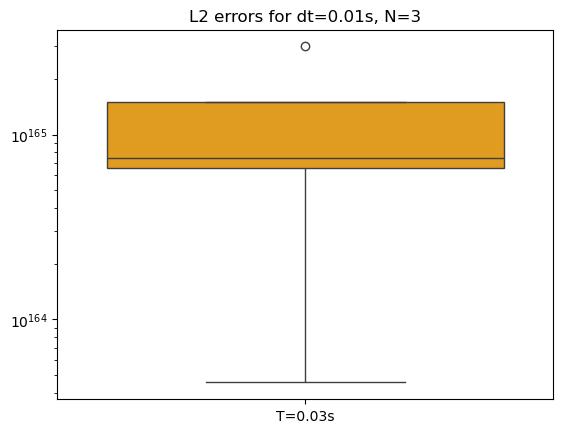

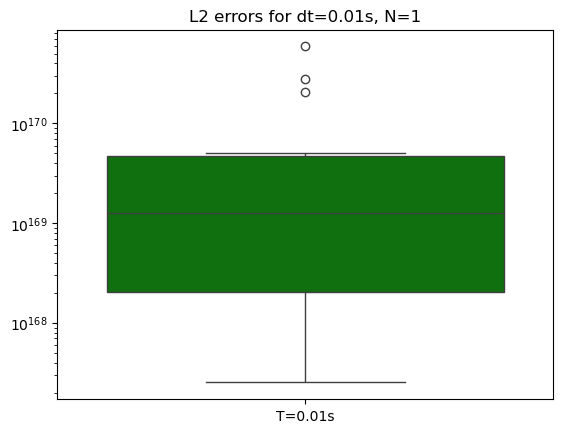

In [410]:
sns.boxplot(
    data=pd.DataFrame({
        #'T=0.5s': baseline_lorenz_05_01[metric][np.where(baseline_lorenz_05_01["L2"]>500)[0]],
        'T=0.03s': baseline_lorenz_003_01["L2"][np.where(baseline_lorenz_003_01["L2"]>500)[0]],
        #'T-0.01s': baseline_lorenz_001_01["L2"][np.where(baseline_lorenz_001_01["L2"]>500)[0]],
    }),
    color='orange'
)
plt.yscale("log")
plt.title("L2 errors for dt=0.01s, N=3")
plt.figure()
sns.boxplot(
    data=pd.DataFrame({
        #'T=0.5s': baseline_lorenz_05_01[metric][np.where(baseline_lorenz_05_01["L2"]>500)[0]],
        #'T=0.03s': baseline_lorenz_003_01["L2"][np.where(baseline_lorenz_003_01["L2"]>500)[0]],
        'T=0.01s': baseline_lorenz_001_01["L2"][np.where(baseline_lorenz_001_01["L2"]>500)[0]],
    }),
    color="green"
)
plt.yscale("log")
plt.title("L2 errors for dt=0.01s, N=1")



Degradation of performances when models trained on dt=0.01 are used with dt=0.1 at inference. 

**Can we define regimes based on KL div values ?**

Do we have collapse regime when KL >1 ?

In [490]:
np.where(baseline_lorenz_003_01["KL_x"] >1)[0]

array([  1,   8,  10,  22,  26,  41,  44,  47,  49,  77,  82,  84,  92,
        93, 102, 104, 130, 139, 140, 147, 148, 150, 165, 174, 177, 182,
       184, 190])

14.057470979434228

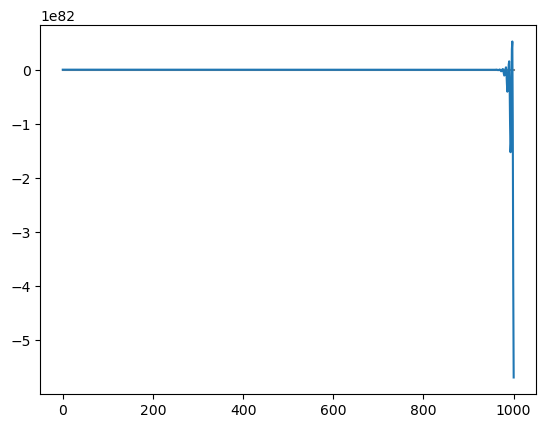

In [504]:
baseline_lorenz_001_01["KL_x"][np.where(baseline_lorenz_001_01["L2"]<500)[0]] #[np.where(baseline_lorenz_001_01["KL_x"]>1)[0]].idxmin()
k=10
plt.plot(baseline_lorenz_003_01["y_true"][k][:,0], label="true", color="grey")
plt.plot(baseline_lorenz_003_01["y_pred"][k][:,0], label="pred")
baseline_lorenz_003_01["KL_x"][k]


0.0051417415273545515 0.07524135496801301 0.08389286980147385


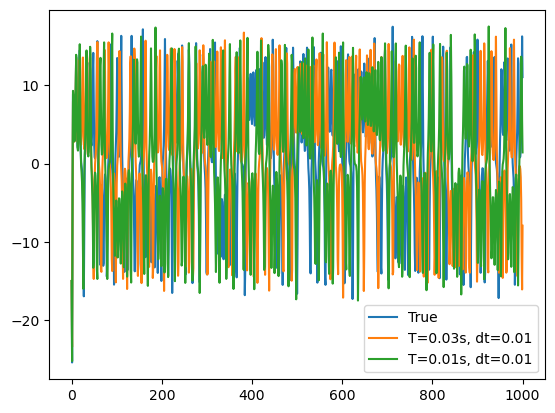

In [414]:
k = baseline_lorenz_05_01["KL_x"][baseline_lorenz_05_01["L2"]<500].idxmax()
plt.plot(baseline_lorenz_05_01["y_true"][k][:,0], label="True")
#plt.plot(baseline_lorenz_05_01["y_pred"][k][:,0], label="T=0.5s, dt=0.01")
plt.plot(baseline_lorenz_003_01["y_pred"][k][:,0], label="T=0.03s, dt=0.01")
#plt.plot(baseline_lorenz_001_01["y_pred"][k][:,0], label=f"T=0.01s, dt=0.1")
plt.plot(baseline_lorenz_001["y_pred"][k][::10,0], label=f"T=0.01s, dt=0.01")
plt.legend()
print(baseline_lorenz_001["KL_x"][k], baseline_lorenz_001_01["KL_x"][k], baseline_lorenz_003_01["KL_x"][k])

**Issue: jax does not run the same local or server**

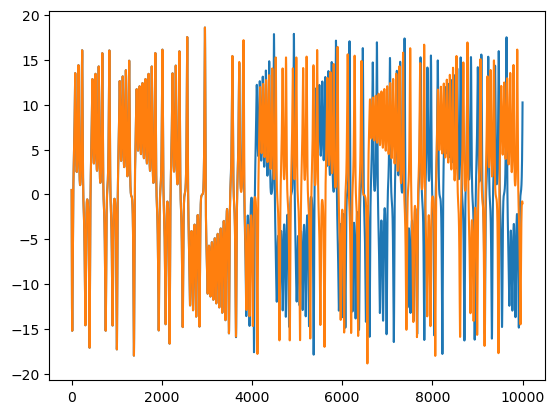

In [192]:
pred0 = model_baseline_lorenz_001(jnp.array(baseline_lorenz_001["y_true"][98][0,:]))
plt.plot(pred0[:,0])
plt.plot(baseline_lorenz_001["y_pred"][98][:,0])

# Lorenz dt_model=10*dt_num=0.1

## 1. Long-term performances

In [589]:
# True F, dt=0.1
true_lorenz_dt01 = np.load("/Users/mayajanvier/jax-phynity/data_exp/lorenz_gridsearch_dtdiff/lorenz100_0.1_test.npy", allow_pickle=True).item()

In [590]:
data = true_lorenz_dt01
states = jnp.array(data['states'])[:,::,:] 
print(states.shape)
results = {}
for k in range(data["states"].shape[0]):
    results[k] = {
                    'y_pred': np.array(states[k]).tolist(),
                }

(200, 1001, 3)


In [591]:
data_true_lorenz_dt01= pd.DataFrame(results).T

In [510]:
# 400 data points
data_lorenz_03_400 = pd.read_json("/Users/mayajanvier/jax-phynity/data_exp/lorenz_gridsearch_dtdiff/none_aug_0.3_12_pnuxhrrg/model_7.069e+01_longrun_dt_100.0_0.1.json").T
data_lorenz_01_400 = pd.read_json("/Users/mayajanvier/jax-phynity/data_exp/lorenz_gridsearch_dtdiff/none_aug_0.1_15_nd66zuw1/model_1.121e+01_longrun_dt_100.0_0.1.json").T

In [511]:
# 4000 data points
data_lorenz_03 = pd.read_json("/Users/mayajanvier/jax-phynity/data_exp/lorenz_gridsearch_dtdiff/none_aug_0.3_8_izbqyulv/model_2.101e+00_longrun_dt_100.0_0.01.json").T
data_lorenz_01 = pd.read_json("/Users/mayajanvier/jax-phynity/data_exp/lorenz_gridsearch_dtdiff/none_aug_0.1_5_56061blh/model_7.720e-01_longrun_dt_100.0_0.01.json").T

data_lorenz_03_01 = pd.read_json("/Users/mayajanvier/jax-phynity/data_exp/lorenz_gridsearch_dtdiff/none_aug_0.3_8_izbqyulv/model_2.101e+00_longrun_dt_100.0_0.1.json").T
data_lorenz_01_01 = pd.read_json("/Users/mayajanvier/jax-phynity/data_exp/lorenz_gridsearch_dtdiff/none_aug_0.1_5_56061blh/model_7.720e-01_longrun_dt_100.0_0.1.json").T

In [919]:
# set 1: nepoch=900, niter=1 for all
data_lorenz_05_01 = pd.read_json("/Users/mayajanvier/jax-phynity/data_exp/lorenz_gridsearch_dtdiff/none_aug_0.5_12_s4w5cw1b/model_5.830e+00_longrun_dt_100.0_0.1.json").T
data_lorenz_1_01 = pd.read_json("/Users/mayajanvier/jax-phynity/data_exp/lorenz_gridsearch_dtdiff/none_aug_1.0_15_blhw1xm7/model_2.483e+01_longrun_dt_100.0_0.1.json").T

# set2: same HP as twobody
data_lorenz_01_01_set2 = pd.read_json("/Users/mayajanvier/jax-phynity/data_exp/lorenz_gridsearch_dtdiff/none_aug_0.1_17_xgz5n1f5/model_8.681e-01_longrun_dt_100.0_0.1.json").T
data_lorenz_05_01_set2 = pd.read_json("/Users/mayajanvier/jax-phynity/data_exp/lorenz_gridsearch_dtdiff/none_aug_0.5_19_6f0ze5fi/model_3.637e+00_longrun_dt_100.0_0.1.json").T
data_lorenz_1_01_set2 = pd.read_json("/Users/mayajanvier/jax-phynity/data_exp/lorenz_gridsearch_dtdiff/none_aug_1.0_16_v3wvdrru/model_1.152e+01_longrun_dt_100.0_0.1.json").T


In [913]:
# verif sizes data
data1 = np.load("/Users/mayajanvier/jax-phynity/data_exp/lorenz_gridsearch_dtdiff/lorenz0.1_train.npy", allow_pickle=True).item()
data5 = np.load("/Users/mayajanvier/jax-phynity/data_exp/lorenz_gridsearch_dtdiff/lorenz0.5_train.npy", allow_pickle=True).item()
data10 = np.load("/Users/mayajanvier/jax-phynity/data_exp/lorenz_gridsearch_dtdiff/lorenz1.0_train.npy", allow_pickle=True).item()
data1["states"].shape, data5["states"].shape, data10["states"].shape

((4000, 11, 3), (800, 51, 3), (400, 101, 3))

In [512]:
data_lorenz_03 = compute_metrics_lorenz(data_lorenz_03)
data_lorenz_01 = compute_metrics_lorenz(data_lorenz_01)

data_lorenz_03_01 = compute_metrics_lorenz(data_lorenz_03_01)
data_lorenz_01_01 = compute_metrics_lorenz(data_lorenz_01_01)

In [513]:
data_lorenz_03_400 = compute_metrics_lorenz(data_lorenz_03_400)
data_lorenz_01_400 = compute_metrics_lorenz(data_lorenz_01_400)

In [920]:
data_lorenz_05_01 = compute_metrics_lorenz(data_lorenz_05_01)
data_lorenz_1_01 = compute_metrics_lorenz(data_lorenz_1_01)
data_lorenz_01_01_set2 = compute_metrics_lorenz(data_lorenz_01_01_set2)
data_lorenz_05_01_set2 = compute_metrics_lorenz(data_lorenz_05_01_set2)
data_lorenz_1_01_set2 = compute_metrics_lorenz(data_lorenz_1_01_set2)

In [595]:
data_true_lorenz_dt01["y_true"] = data_lorenz_01_01["y_true"]

In [597]:
data_true_lorenz_dt01 = compute_metrics_lorenz(data_true_lorenz_dt01)

/var/folders/d3/xx7sty_17dvbrq_tj5nl0_r40000gs/T/ipykernel_60399/1496776021.py:6: RuntimeWarning: overflow encountered in square
  data["L2"] = data.apply(lambda x: np.mean(np.array((x["y_true"] - x["y_pred"])**2)), axis=1)
/var/folders/d3/xx7sty_17dvbrq_tj5nl0_r40000gs/T/ipykernel_60399/1496776021.py:7: RuntimeWarning: overflow encountered in square
  data["L2_5s"] = data.apply(lambda x: np.mean(np.array((x["y_true"][:,:501] - x["y_pred"][:,:501])**2)), axis=1)
/var/folders/d3/xx7sty_17dvbrq_tj5nl0_r40000gs/T/ipykernel_60399/1496776021.py:8: RuntimeWarning: overflow encountered in square
  data["L2_0.5s"] = data.apply(lambda x: np.mean(np.array((x["y_true"][:,:51] - x["y_pred"][:,:51])**2)), axis=1)
/var/folders/d3/xx7sty_17dvbrq_tj5nl0_r40000gs/T/ipykernel_60399/1496776021.py:9: RuntimeWarning: overflow encountered in square
  data["L2_0.1s"] = data.apply(lambda x: np.mean(np.array((x["y_true"][:,:11] - x["y_pred"][:,:11])**2)), axis=1)
/var/folders/d3/xx7sty_17dvbrq_tj5nl0_r40000gs/

Text(0.5, 1.0, 'RK4, different dt, true F, traj 102')

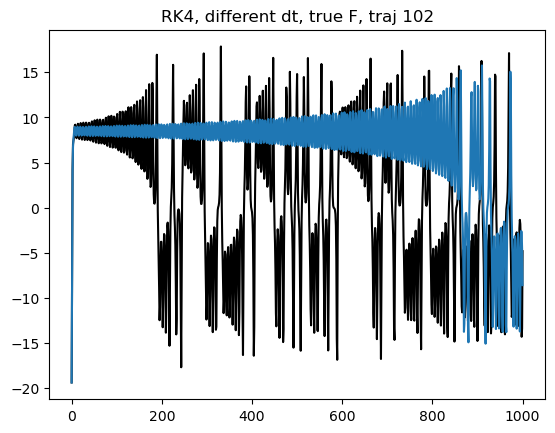

In [623]:
k=102
plt.plot(data_true_lorenz_dt01["y_true"][k][:,0], label="True, dt=0.1", color="black")
plt.plot(data_true_lorenz_dt01["y_pred"][k][:,0], label="True, dt=0.1")
plt.title("RK4, different dt, true F, traj 102")

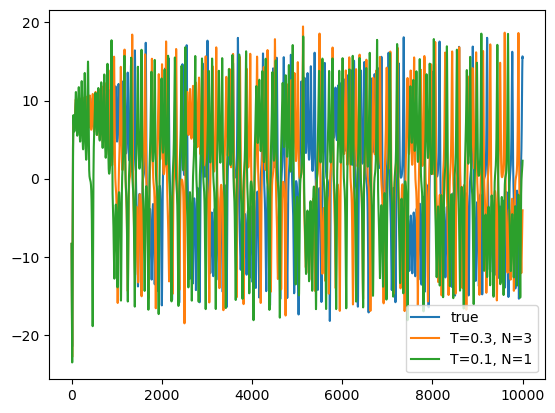

In [638]:
k=82
time=-1
plt.plot(data_lorenz_01["y_true"][k][:time,0], label="true")
#plt.plot(baseline_lorenz_003["y_pred"][k][0:time:10,0], label="T=0.03, N=3")
plt.plot(data_lorenz_03["y_pred"][k][:time,0], label="T=0.3, N=3")
plt.plot(data_lorenz_01["y_pred"][k][:time,0], label="T=0.1, N=1")
plt.legend()


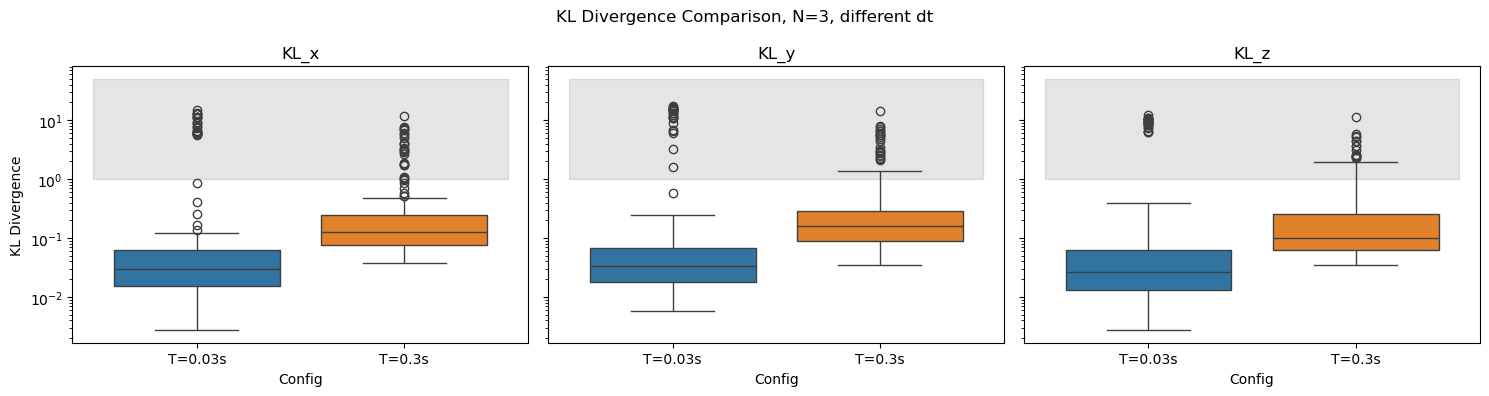

In [161]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

for i, metric in enumerate(["KL_x", "KL_y", "KL_z"]):
    sns.boxplot(
        data=pd.DataFrame({
            'T=0.03s': baseline_lorenz_003[metric],
            'T=0.3s': data_lorenz_03[metric],
        }),
        ax=axes[i]
    )
    axes[i].fill_between([-0.5, 1.5],1, 5e1, label="Collapse area", color='black', alpha=0.1)
    axes[i].set_title(metric)
    axes[i].set_yscale("log")
    axes[i].set_ylabel("KL Divergence" if i == 0 else "")
    axes[i].set_xlabel("Config")

plt.suptitle("KL Divergence Comparison, N=3, different dt")
plt.tight_layout()
plt.show()


In [169]:
for metric in ["KL_x", "KL_y", "KL_z"]:
    n3 = np.sum(baseline_lorenz_003[metric] > 1)
    n3_dt = np.sum(data_lorenz_03[metric] > 1)
    print(f"{metric}>1 → dt=0.01={n3}, dt=0.1={n3_dt}")

KL_x>1 → dt=0.01=24, dt=0.1=25
KL_y>1 → dt=0.01=24, dt=0.1=27
KL_z>1 → dt=0.01=24, dt=0.1=29


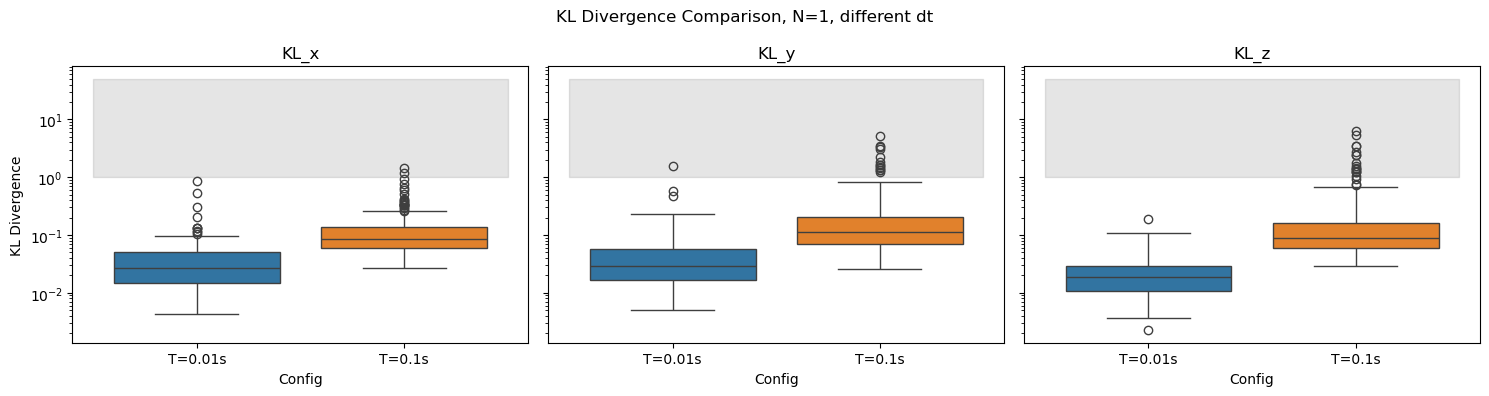

In [181]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

for i, metric in enumerate(["KL_x", "KL_y", "KL_z"]):
    sns.boxplot(
        data=pd.DataFrame({
            'T=0.01s': baseline_lorenz_001[metric],
            'T=0.1s': data_lorenz_01[metric],
        }),
        ax=axes[i]
    )
    axes[i].fill_between([-0.5, 1.5],1, 5e1, label="Collapse area", color='black', alpha=0.1)
    axes[i].set_title(metric)
    axes[i].set_yscale("log")
    axes[i].set_ylabel("KL Divergence" if i == 0 else "")
    axes[i].set_xlabel("Config")

plt.suptitle("KL Divergence Comparison, N=1, different dt")
plt.tight_layout()
plt.show()


On observe une dégradation des performances quand le dt du modèle augmente. 

Text(0.5, 0.48, 'KL Divergence Comparison,  dt_test=0.1')

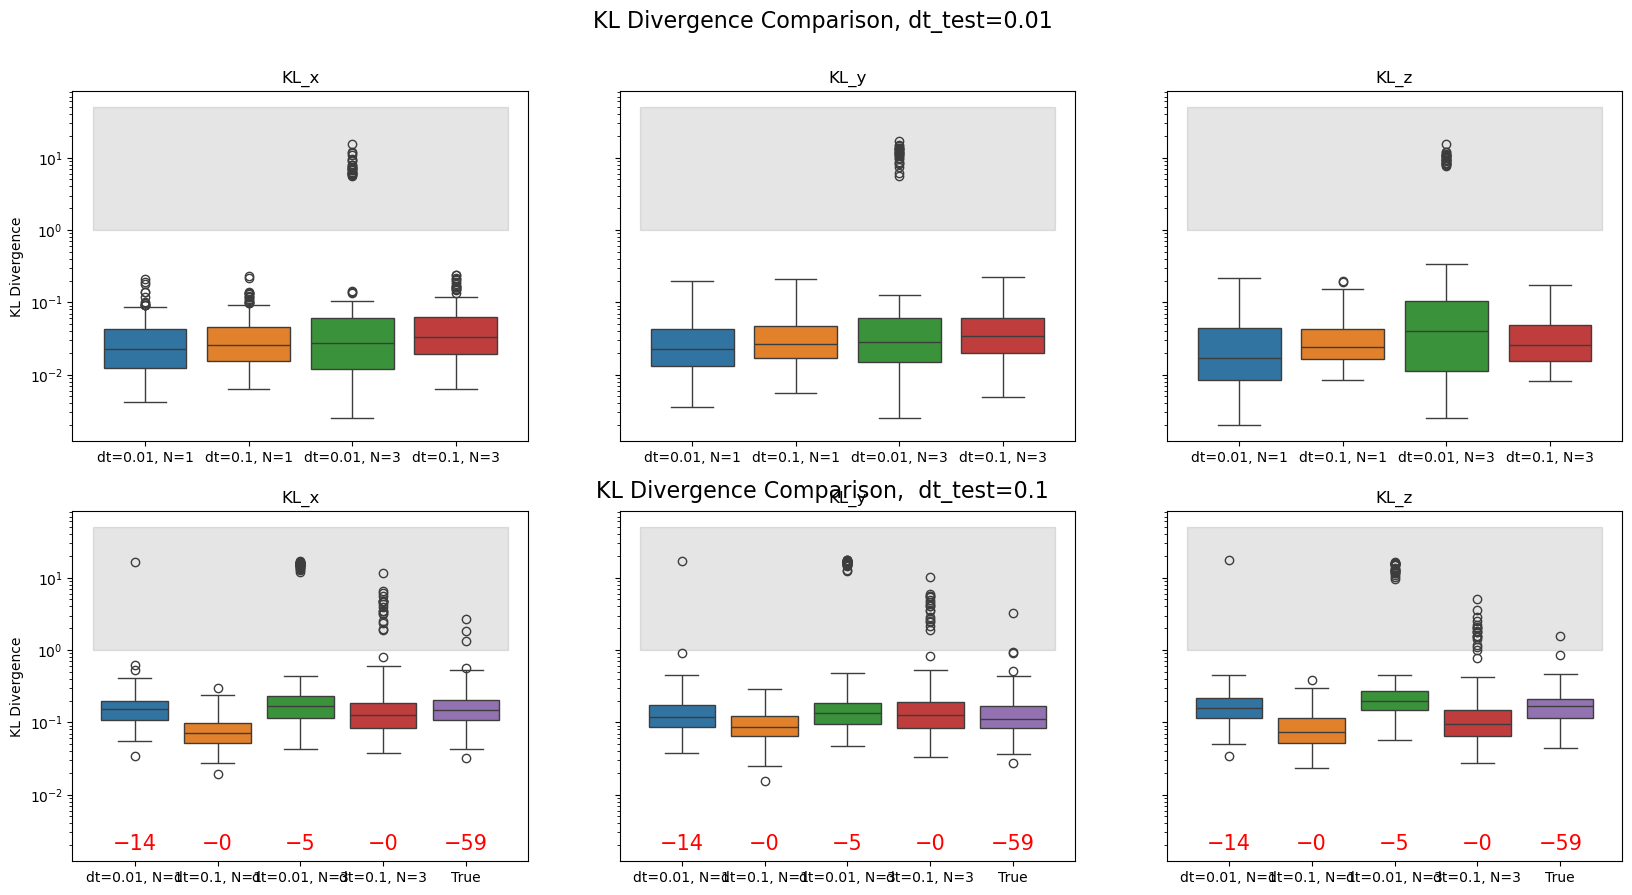

In [630]:
fig, axes = plt.subplots(2, 3, figsize=(20, 10), sharey=True)

for i, metric in enumerate(["KL_x", "KL_y", "KL_z"]):
    sns.boxplot(
        data=pd.DataFrame({
            'dt=0.01, N=1': baseline_lorenz_001[metric],
            'dt=0.1, N=1': data_lorenz_01[metric],
            'dt=0.01, N=3': baseline_lorenz_003[metric],
            'dt=0.1, N=3': data_lorenz_03[metric],
        }),
        ax=axes[0][i]
    )
    axes[0][i].fill_between([-0.5, 3.5],1, 5e1, label="Collapse area", color='black', alpha=0.1)
    axes[0][i].set_title(metric)
    axes[0][i].set_yscale("log")
    axes[0][i].set_ylabel("KL Divergence" if i == 0 else "")
    #axes[0][i].set_xlabel("Config")

for i, metric in enumerate(["KL_x", "KL_y", "KL_z"]):
    mask_003 = baseline_lorenz_003_01["L2"] < 500
    mask_001 = baseline_lorenz_001_01["L2"] < 500
    mask_01 = data_lorenz_01_01["L2"] <500
    mask_03 = data_lorenz_03_01["L2"] <500
    mask_true = data_true_lorenz_dt01["L2"] <500
    sns.boxplot(
        data=pd.DataFrame({
            'dt=0.01, N=1': baseline_lorenz_001_01[metric][mask_001],
            'dt=0.1, N=1': data_lorenz_01_01[metric][mask_01],
            'dt=0.01, N=3': baseline_lorenz_003_01[metric][mask_003],
            'dt=0.1, N=3': data_lorenz_03_01[metric][mask_03],
            'True': data_true_lorenz_dt01[metric][mask_true],
        }),
        ax=axes[1][i]
    )
    # add number of excluded outliers in the plot as text
    total = [len(baseline_lorenz_001_01[metric]),
            len(data_lorenz_01_01[metric]),
            len(baseline_lorenz_003_01[metric]),
            len(data_lorenz_03_01[metric]),
            len(data_true_lorenz_dt01[metric])]
    kept = [mask_001.sum(), mask_01.sum(), mask_003.sum(), mask_03.sum(), mask_true.sum()]
    excluded = [t - k for t, k in zip(total, kept)]

    # --- Annotate below each box ---
    for j, excl in enumerate(excluded):
        axes[1][i].text(
            j, 0.02, f"−{excl}",
            ha="center", va="bottom", transform=axes[1][i].get_xaxis_transform(),
            fontsize=15, color="red"
        )
    axes[1][i].fill_between([-0.5, 4.5],1, 5e1, label="Collapse area", color='black', alpha=0.1)
    axes[1][i].set_title(metric)
    axes[1][i].set_yscale("log")
    axes[1][i].set_ylabel("KL Divergence" if i == 0 else "")
    #axes[1][i].set_xlabel("Config")

fig.text(0.5, 0.95, "KL Divergence Comparison, dt_test=0.01", 
         ha='center', va='center', fontsize=16)
fig.text(0.5, 0.48, "KL Divergence Comparison,  dt_test=0.1", 
         ha='center', va='center', fontsize=16)


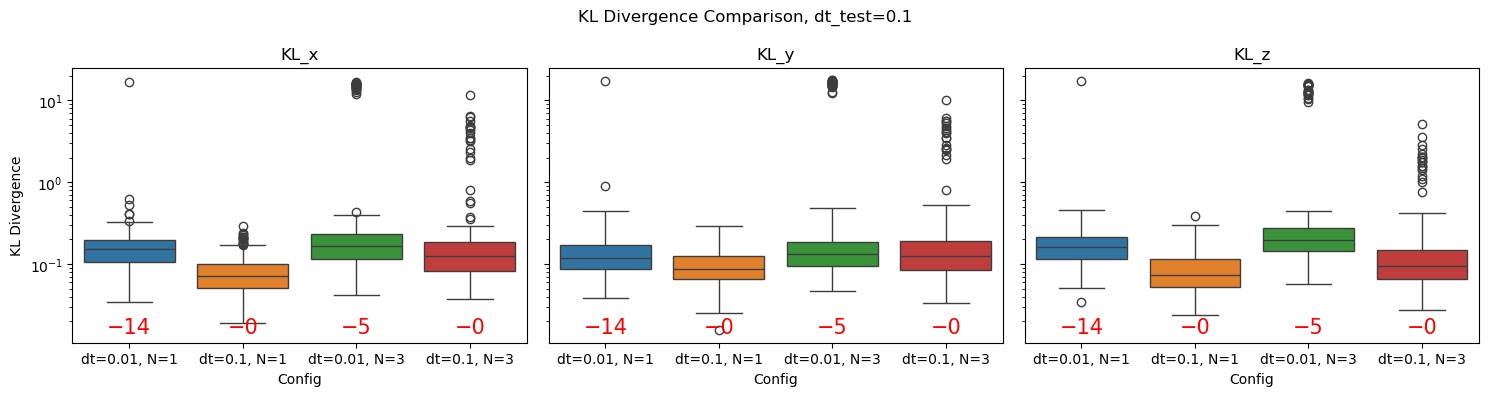

In [521]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

for i, metric in enumerate(["KL_x", "KL_y", "KL_z"]):
    mask_003 = baseline_lorenz_003_01["L2"] < 500
    mask_001 = baseline_lorenz_001_01["L2"] < 500
    mask_01 = data_lorenz_01_01["L2"] <500
    mask_03 = data_lorenz_03_01["L2"] <500

    sns.boxplot(
        data=pd.DataFrame({
            'dt=0.01, N=1': baseline_lorenz_001_01[metric][mask_001],
            'dt=0.1, N=1': data_lorenz_01_01[metric][mask_01],
            'dt=0.01, N=3': baseline_lorenz_003_01[metric][mask_003],
            'dt=0.1, N=3': data_lorenz_03_01[metric][mask_03],

        }),
        ax=axes[i]
    )
    # add number of excluded outliers in the plot as text
    total = [len(baseline_lorenz_001_01[metric]),
            len(data_lorenz_01_01[metric]),
            len(baseline_lorenz_003_01[metric]),
            len(data_lorenz_03_01[metric])]
    kept = [mask_001.sum(), mask_01.sum(), mask_003.sum(), mask_03.sum()]
    excluded = [t - k for t, k in zip(total, kept)]

    # --- Annotate below each box ---
    for j, excl in enumerate(excluded):
        axes[i].text(
            j, 0.02, f"−{excl}",
            ha="center", va="bottom", transform=axes[i].get_xaxis_transform(),
            fontsize=15, color="red"
        )
    #axes[i].fill_between([-0.5, 3.5],1, 5e1, label="Collapse area", color='black', alpha=0.1)
    axes[i].set_title(metric)
    axes[i].set_yscale("log")
    axes[i].set_ylabel("KL Divergence" if i == 0 else "")
    axes[i].set_xlabel("Config")

plt.suptitle("KL Divergence Comparison, dt_test=0.1")
plt.tight_layout()
plt.show()


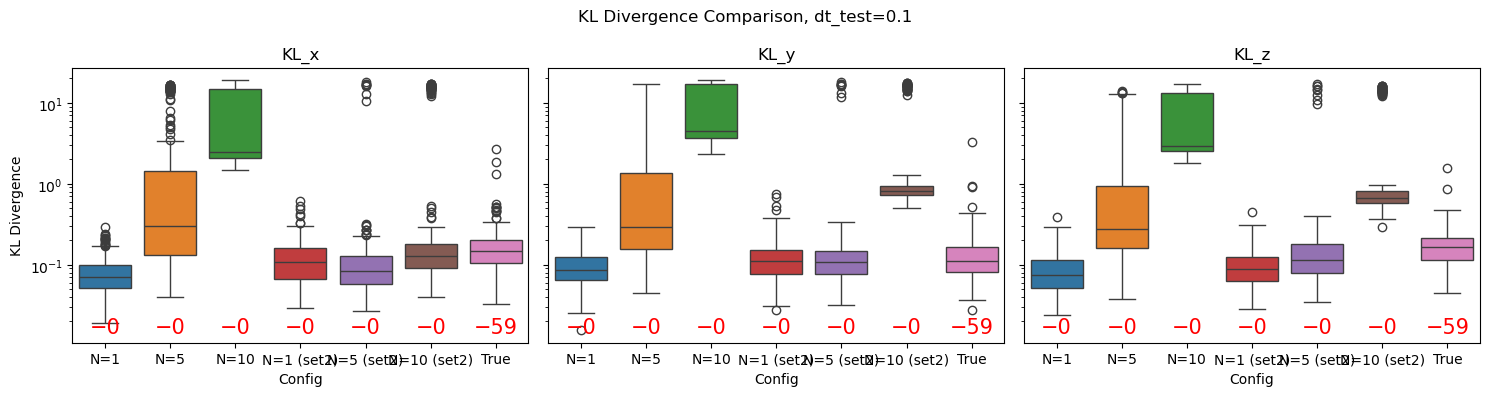

In [985]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

for i, metric in enumerate(["KL_x", "KL_y", "KL_z"]):
    mask01 = data_lorenz_01_01["L2"] <500
    mask05 = data_lorenz_05_01["L2"] <500
    mask1 = data_lorenz_1_01["L2"] <500

    mask01_set2 = data_lorenz_01_01_set2["L2"] <500
    mask05_set2 = data_lorenz_05_01_set2["L2"] <500
    mask1_set2 = data_lorenz_1_01_set2["L2"] <500
    masktrue = data_true_lorenz_dt01["L2"] <500

    sns.boxplot(
        data=pd.DataFrame({
            'N=1': data_lorenz_01_01[metric][mask01],
            'N=5': data_lorenz_05_01[metric][mask05],
            'N=10': data_lorenz_1_01[metric][mask1],
            'N=1 (set2)': data_lorenz_01_01_set2[metric][mask01_set2],
            'N=5 (set2)': data_lorenz_05_01_set2[metric][mask05_set2],
            'N=10 (set2)': data_lorenz_1_01_set2[metric][mask1_set2],
            'True': data_true_lorenz_dt01[metric][masktrue],

        }),
        ax=axes[i]
    )
    # add number of excluded outliers in the plot as text
    total = [len(data_lorenz_01_01[metric]),
            len(data_lorenz_05_01[metric]),
            len(data_lorenz_1_01[metric]),
            len(data_lorenz_01_01_set2[metric]),
            len(data_lorenz_05_01_set2[metric]),
            len(data_lorenz_1_01_set2[metric]),
            len(data_true_lorenz_dt01[metric])]
    kept = [mask01.sum(), mask05.sum(), mask1.sum(), mask01_set2.sum(), mask05_set2.sum(), mask1_set2.sum(), masktrue.sum()]
    excluded = [t - k for t, k in zip(total, kept)]

    # --- Annotate below each box ---
    for j, excl in enumerate(excluded):
        axes[i].text(
            j, 0.02, f"−{excl}",
            ha="center", va="bottom", transform=axes[i].get_xaxis_transform(),
            fontsize=15, color="red"
        )
    #axes[i].fill_between([-0.5, 3.5],1, 5e1, label="Collapse area", color='black', alpha=0.1)
    axes[i].set_title(metric)
    axes[i].set_yscale("log")
    axes[i].set_ylabel("KL Divergence" if i == 0 else "")
    axes[i].set_xlabel("Config")

plt.suptitle("KL Divergence Comparison, dt_test=0.1")
plt.tight_layout()
plt.show()


In [955]:
mask01_set2.sum(), mask05_set2.sum(), mask1_set2.sum()

(200, 192, 170)

Text(0.5, 0.98, 'L2 Comparison, dt_test=0.1')

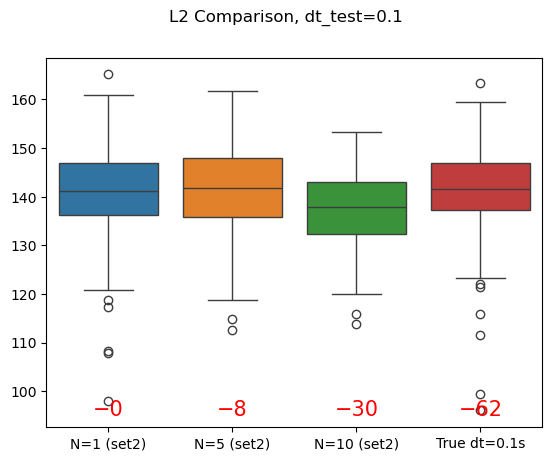

In [983]:
metric="L2"
fig, axes = plt.subplots()
mask01_set2 = data_lorenz_01_01_set2["KL_x"] < 1
mask05_set2 = data_lorenz_05_01_set2["KL_x"] < 1
mask1_set2 = data_lorenz_1_01_set2["KL_x"] < 1
masktrue = data_true_lorenz_dt01["KL_x"] < 1
sns.boxplot(
        data=pd.DataFrame({
            # 'N=1': data_lorenz_01_01[metric][mask01],
            # 'N=5': data_lorenz_05_01[metric][mask05],
            # 'N=10': data_lorenz_1_01[metric][mask1],
            'N=1 (set2)': data_lorenz_01_01_set2[metric][mask01_set2],
            'N=5 (set2)': data_lorenz_05_01_set2[metric][mask05_set2],
            'N=10 (set2)': data_lorenz_1_01_set2[metric][mask1_set2],
            "True dt=0.1s": data_true_lorenz_dt01[metric][masktrue],

        }))
total = [
            len(data_lorenz_01_01_set2[metric]),
            len(data_lorenz_05_01_set2[metric]),
            len(data_lorenz_1_01_set2[metric]),
            len(data_true_lorenz_dt01[metric])]
kept = [mask01_set2.sum(), mask05_set2.sum(), mask1_set2.sum(), masktrue.sum()]
excluded = [t - k for t, k in zip(total, kept)]

# --- Annotate below each box ---
for j, excl in enumerate(excluded):
    axes.text(
        j, 0.02, f"−{excl}",
        ha="center", va="bottom", transform=axes.get_xaxis_transform(),
        fontsize=15, color="red"
    )
plt.suptitle("L2 Comparison, dt_test=0.1")

Text(0.5, 1.0, 'Smoothed (kernel=50) L2 state time error, dt=0.1s')

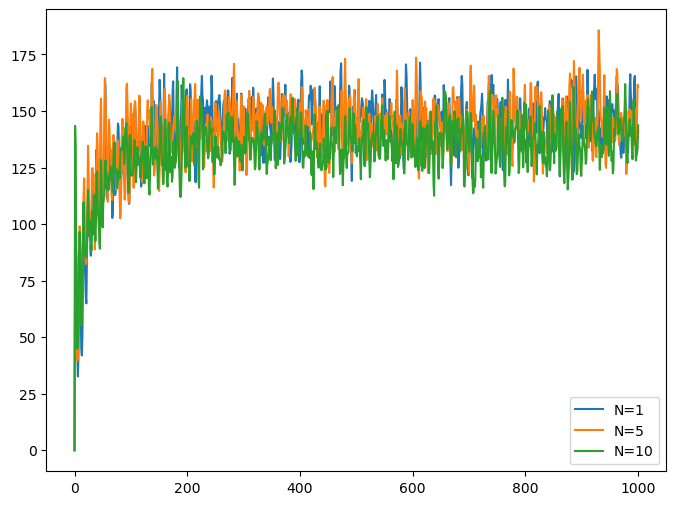

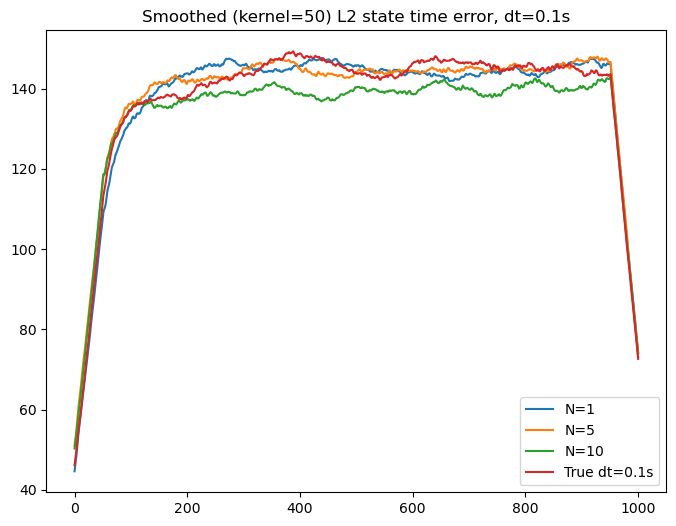

In [984]:
fig, ax = plt.subplots(figsize=(8, 6))
plt.plot(data_lorenz_01_01_set2["L2_state_time"].mean(), label="N=1")
plt.plot(data_lorenz_05_01_set2["L2_state_time"].mean(), label="N=5")
plt.plot(data_lorenz_1_01_set2["L2_state_time"].mean(), label="N=10")

plt.legend()

fig, ax = plt.subplots(figsize=(8, 6))
# plot smoothed version,window=50
kernel_size = 100
kernel = np.ones(kernel_size) / kernel_size
plt.plot(np.convolve(data_lorenz_01_01_set2["L2_state_time"][mask01_set2].mean(), kernel, mode="same"), label="N=1")
plt.plot(np.convolve(data_lorenz_05_01_set2["L2_state_time"][mask05_set2].mean(), kernel, mode="same"), label="N=5")
plt.plot(np.convolve(data_lorenz_1_01_set2["L2_state_time"][mask1_set2].mean(), kernel, mode="same"), label="N=10")
plt.plot(np.convolve(data_true_lorenz_dt01["L2_state_time"][masktrue].mean(), kernel, mode="same"), label="True dt=0.1s")
plt.legend()
plt.title("Smoothed (kernel=50) L2 state time error, dt=0.1s")


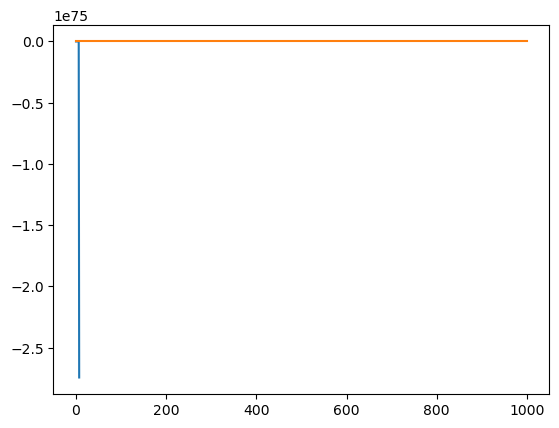

In [993]:
plt.plot(data_true_lorenz_dt01["y_pred"][195][:,0])
plt.plot(data_true_lorenz_dt01["y_true"][195][:,0])

1.8145368678847111 0.5559391181246639 0.13090742075731396


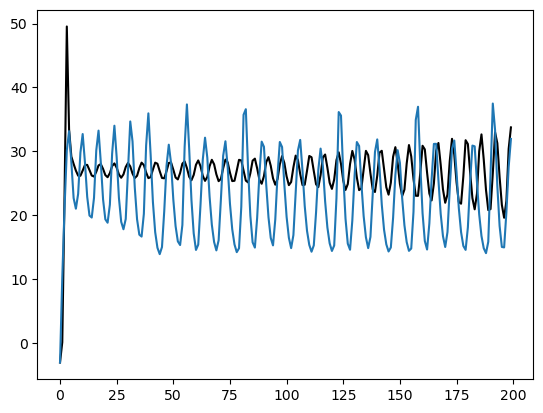

In [936]:
k=data_lorenz_1_01["KL_z"].idxmin()
time=200
plt.plot(data_lorenz_1_01["y_true"][k][:time,2], label="True, dt=0.1", color="black")
plt.plot(data_lorenz_1_01["y_pred"][k][:time,2], label="Pred, N=10")
# plt.plot(data_lorenz_05_01["y_pred"][k][:time,2], label="Pred, N=5")
# plt.plot(data_lorenz_01_01["y_pred"][k][:time,2], label="Pred, N=1")
print(data_lorenz_1_01["KL_z"][k], data_lorenz_05_01["KL_z"][k], data_lorenz_01_01["KL_z"][k])


0.290781953248831 14.588703158014948 0.06855849707232298


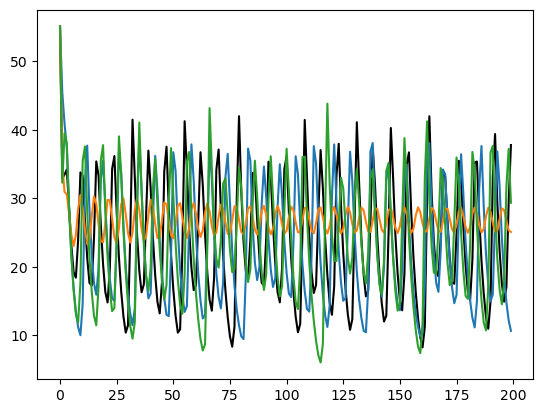

In [939]:
k=data_lorenz_1_01_set2["KL_z"].idxmin()
time=200
plt.plot(data_lorenz_1_01_set2["y_true"][k][:time,2], label="True, dt=0.1", color="black")
plt.plot(data_lorenz_1_01_set2["y_pred"][k][:time,2], label="Pred, N=10")
plt.plot(data_lorenz_05_01_set2["y_pred"][k][:time,2], label="Pred, N=5")
plt.plot(data_lorenz_01_01_set2["y_pred"][k][:time,2], label="Pred, N=1")
print(data_lorenz_1_01_set2["KL_z"][k], data_lorenz_05_01_set2["KL_z"][k], data_lorenz_01_01_set2["KL_z"][k])


In [997]:
k= 195
y_rk4_dt01L, _,_,_= RK_solver_fixed(F_lorenz,baseline_lorenz_001_01["y_pred"][k][0,:], dt=0.1, num_steps=1000, tableau=RK_tableaux["RK4"] )
y_rk4_dt001L, _,_,_= RK_solver_fixed(F_lorenz,baseline_lorenz_001_01["y_pred"][k][0,:], dt=0.01, num_steps=10000, tableau=RK_tableaux["RK4"] )

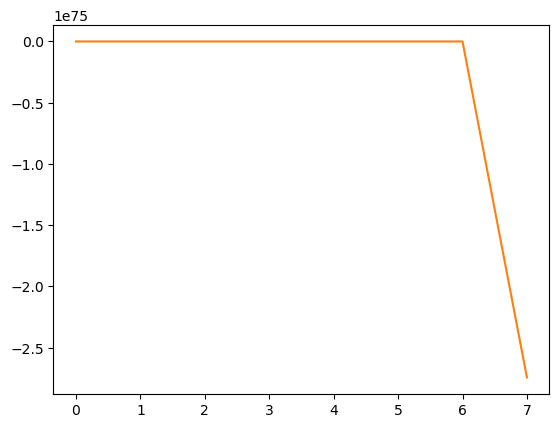

In [1006]:
time = 10
plt.plot(y_rk4_dt001L[0,:time:10], label="RK4 dt=0.01s")
plt.plot(y_rk4_dt01L[0,:time], label="RK4 dt=0.1s")

In [615]:
y_rk4_dt01L[1,::] == data_true_lorenz_dt01["y_pred"][k][:,1]

Array([ True, False, False, ..., False, False, False], dtype=bool)

Changement de machine introduit des erreurs 

0.07469566196946134

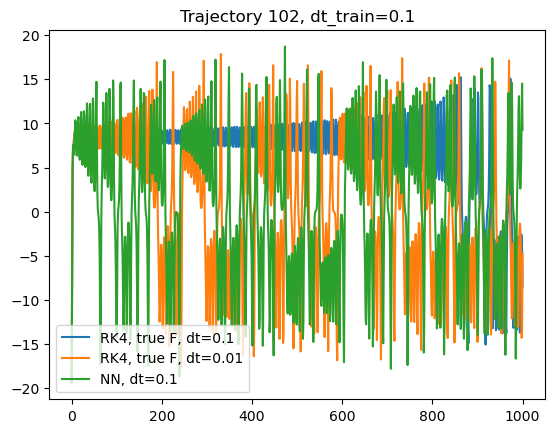

In [624]:
#plt.plot(data_lorenz_03_01["y_pred"][data_lorenz_03_01["KL_y"].idxmax()][:,0])
#plt.plot(baseline_lorenz_001_01["y_true"][baseline_lorenz_001_01["KL_y"].idxmax()][:,0])
#plt.plot(y_rk4_dt01L[0,:], label="true, dt=0.1")
#plt.plot(y_rk4_dt001L[0,::10], label="true, dt=0.01")
plt.plot(data_true_lorenz_dt01["y_pred"][k][:,0], label="RK4, true F, dt=0.1")
plt.plot(data_true_lorenz_dt01["y_true"][k][:,0], label="RK4, true F, dt=0.01")
plt.plot(data_lorenz_01_01["y_pred"][k][:,0], label="NN, dt=0.1")

#plt.plot(baseline_lorenz_001_01["y_pred"][baseline_lorenz_001_01["KL_y"].idxmax()][:,0], label="dt_test=0.1")
#plt.plot(baseline_lorenz_001["y_pred"][baseline_lorenz_001_01["KL_y"].idxmax()][::10,0],label="dt_test=0.01")
plt.title(f"Trajectory {k}, dt_train=0.1")
plt.legend()
data_lorenz_01_01["KL_x"][k]

2.800416045704687

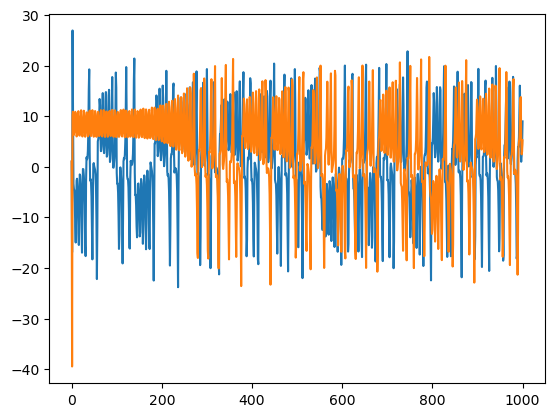

In [258]:
k=64
plt.plot(data_lorenz_03_01["y_true"][k][:,1])
plt.plot(data_lorenz_03_01["y_pred"][k][:,1])
data_lorenz_03_01["KL_y"][k]

Data problem:

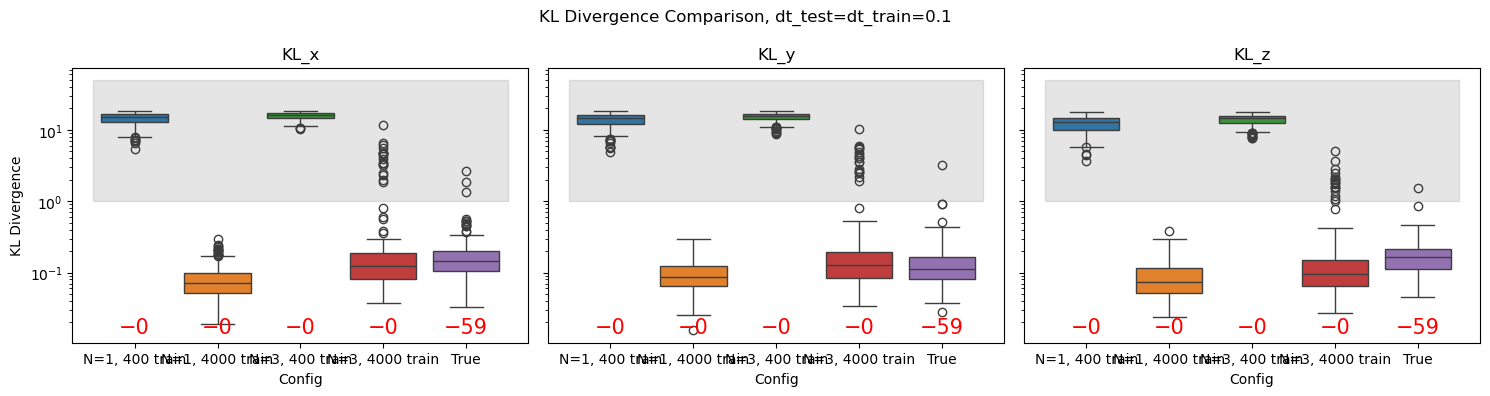

In [626]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

for i, metric in enumerate(["KL_x", "KL_y", "KL_z"]):
    mask_01 = data_lorenz_01_01["L2"] <500
    mask_03 = data_lorenz_03_01["L2"] <500
    mask_01_400 = data_lorenz_01_400["L2"] <500
    mask_03_400 = data_lorenz_03_400["L2"] <500
    mask_true = data_true_lorenz_dt01["L2"] <500
    sns.boxplot(
        data=pd.DataFrame({
            'N=1, 400 train': data_lorenz_01_400[metric][mask_01_400],
            'N=1, 4000 train': data_lorenz_01_01[metric][mask_01],
            'N=3, 400 train': data_lorenz_03_400[metric][mask_03_400],
            'N=3, 4000 train': data_lorenz_03_01[metric][mask_03],
            "True": data_true_lorenz_dt01[metric][mask_true],
        }),
        ax=axes[i]
    )
    # add number of excluded outliers in the plot as text
    total = [len(data_lorenz_01_400[metric]),
            len(data_lorenz_01_01[metric]),
            len(data_lorenz_03_400[metric]),
            len(data_lorenz_03_01[metric]),
            len(data_true_lorenz_dt01[metric])]
    kept = [mask_01_400.sum(), mask_01.sum(), mask_03_400.sum(), mask_03.sum(), mask_true.sum()]
    excluded = [t - k for t, k in zip(total, kept)]

    # --- Annotate below each box ---
    for j, excl in enumerate(excluded):
        axes[i].text(
            j, 0.02, f"−{excl}",
            ha="center", va="bottom", transform=axes[i].get_xaxis_transform(),
            fontsize=15, color="red"
        )
    axes[i].fill_between([-0.5, 4.5],1, 5e1, label="Collapse area", color='black', alpha=0.1)
    axes[i].set_title(metric)
    axes[i].set_yscale("log")
    axes[i].set_ylabel("KL Divergence" if i == 0 else "")
    axes[i].set_xlabel("Config")

plt.suptitle("KL Divergence Comparison, dt_test=dt_train=0.1")
plt.tight_layout()
plt.show()


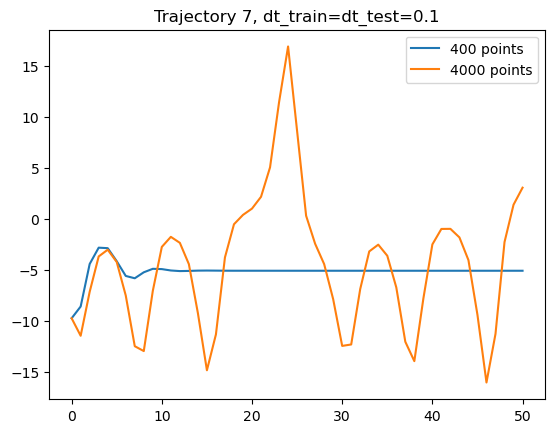

In [559]:
time=51
plt.plot(data_lorenz_01_400["y_pred"][7][:time,0], label="400 points")
plt.plot(data_lorenz_01_01["y_pred"][7][:time,0], label="4000 points")
plt.title("Trajectory 7, dt_train=dt_test=0.1" )
plt.legend()

## 2. $L_\theta$ and jacobian norms

We compare the N=1 models under different training configurations.

In [49]:
dtL = 0.1
dtL_num = 0.01


In [1140]:
def F_lorenz(s,t):
    x, y, z = s
    sigma = 10.0
    rho = 28.0
    beta = 8.0 / 3.0
    x_prime = sigma * (y - x)
    y_prime = x * (rho - z) - y
    z_prime = x * y - beta * z
    return jnp.array([x_prime, y_prime, z_prime])

In [59]:
# T_max=1s, dt=dt_num=0.01
experiment_path1L = "/Users/mayajanvier/jax-phynity/data_exp/lorenz_gridsearch/none_aug_0.01_2_lj5ayrlu"
model_baseline_lorenz_001 = load_best_model_dt(dtL_num, experiment_path1L, "lorenz", integration_method, data_integration_method="RK4", dt_num=0.01, duration=100)

# T_max=1s. dt=10dt_num=0.1
experiment_path1L_400 = "/Users/mayajanvier/jax-phynity/data_exp/lorenz_gridsearch_dtdiff/none_aug_0.1_15_nd66zuw1"
model_baseline_lorenz_01_400 =load_best_model_dt(dtL, experiment_path1L_400, "lorenz", integration_method, data_integration_method="RK4", dt_num=0.01, duration=100)

# T_max=10s, dt=10dt_num=0.1
experiment_path1L_4000 = "/Users/mayajanvier/jax-phynity/data_exp/lorenz_gridsearch_dtdiff/none_aug_0.1_5_56061blh"
model_baseline_lorenz_01_4000 =load_best_model_dt(dtL, experiment_path1L_4000, "lorenz", integration_method, data_integration_method="RK4", dt_num=0.01, duration=100)

/Users/mayajanvier/jax-phynity/data_exp/lorenz_gridsearch/none_aug_0.01_2_lj5ayrlu/model_6.202e-03.eqx
{'dt': 0.01, 'test data dt': 0.01, 'dt factor': 1}
/Users/mayajanvier/jax-phynity/data_exp/lorenz_gridsearch_dtdiff/none_aug_0.1_15_nd66zuw1/model_1.121e+01.eqx
{'dt': 0.1, 'test data dt': 0.01, 'dt factor': 10}
/Users/mayajanvier/jax-phynity/data_exp/lorenz_gridsearch_dtdiff/none_aug_0.1_5_56061blh/model_7.720e-01.eqx
{'dt': 0.1, 'test data dt': 0.01, 'dt factor': 10}


In [1007]:
experiment_01_set2 = "/Users/mayajanvier/jax-phynity/data_exp/lorenz_gridsearch_dtdiff/none_aug_0.1_17_xgz5n1f5"
model_baseline_lorenz_01_set2 = load_best_model_dt(dtL, experiment_01_set2, "lorenz", integration_method, data_integration_method="RK4", dt_num=0.01, duration=100)

experiment_05_set2 = "/Users/mayajanvier/jax-phynity/data_exp/lorenz_gridsearch_dtdiff/none_aug_0.5_19_6f0ze5fi"
model_baseline_lorenz_05_set2 = load_best_model_dt(dtL, experiment_05_set2, "lorenz", integration_method, data_integration_method="RK4", dt_num=0.01, duration=100)

experiment_1_set2 = "/Users/mayajanvier/jax-phynity/data_exp/lorenz_gridsearch_dtdiff/none_aug_1.0_16_v3wvdrru"
model_baseline_lorenz_1_set2 = load_best_model_dt(dtL, experiment_1_set2, "lorenz", integration_method, data_integration_method="RK4", dt_num=0.01, duration=100)

/Users/mayajanvier/jax-phynity/data_exp/lorenz_gridsearch_dtdiff/none_aug_0.1_17_xgz5n1f5/model_8.681e-01.eqx
{'dt': 0.1, 'test data dt': 0.01, 'dt factor': 10}
/Users/mayajanvier/jax-phynity/data_exp/lorenz_gridsearch_dtdiff/none_aug_0.5_19_6f0ze5fi/model_3.637e+00.eqx
{'dt': 0.1, 'test data dt': 0.01, 'dt factor': 10}
/Users/mayajanvier/jax-phynity/data_exp/lorenz_gridsearch_dtdiff/none_aug_1.0_16_v3wvdrru/model_1.152e+01.eqx
{'dt': 0.1, 'test data dt': 0.01, 'dt factor': 10}


In [60]:
yL_100s_001 = get_states(baseline_lorenz_001, type='lorenz')
yL_100s_01 = get_states(baseline_lorenz_001_01, type='lorenz')

(2000200, 3) (3,)
(200200, 3) (3,)


In [1042]:
yL_100s_01_dt01 = get_states(data_true_lorenz_dt01, type='lorenz', bool_true=False)

(200200, 3) (3,)


In [1022]:
yL_01_set2_pred = get_states(data_lorenz_01_01_set2, type='lorenz', bool_true=False)
yL_05_set2_pred = get_states(data_lorenz_05_01_set2, type='lorenz', bool_true=False)
yL_1_set2_pred = get_states(data_lorenz_1_01_set2, type='lorenz', bool_true=False)

(200200, 3) (3,)
(200200, 3) (3,)
(200200, 3) (3,)


In [ ]:
yL_001_pred = get_states(baseline_lorenz_001_01, type='lorenz', bool_true=False)
yL_01_pred = get_states(data_lorenz_01_01, type='lorenz', bool_true=False)
yL_03_pred = get_states(data_lorenz_03_01, type='lorenz', bool_true=False)
yL_01_400_pred = get_states(data_lorenz_01_400, type='lorenz', bool_true=False)
yL_01_4000_pred = get_states(data_lorenz_01_4000, type='lorenz', bool_true=False)


In [54]:
jac_true_lorenz_001 = compute_jacobian_test(F_lorenz, yL_100s_001, bool_true=True)
jac_true_lorenz_01 = compute_jacobian_test(F_lorenz, yL_100s_01, bool_true=True)

In [61]:
jac_baseline_lorenz_001 = compute_jacobian_test(model_baseline_lorenz_001, yL_100s_001, bool_true=False)
jac_baseline_lorenz_01_400 = compute_jacobian_test(model_baseline_lorenz_01_400, yL_100s_01, bool_true=False)
jac_baseline_lorenz_01_4000 = compute_jacobian_test(model_baseline_lorenz_01_4000, yL_100s_01, bool_true=False)

In [1046]:
jac_baseline_lorenz_01_set2 = compute_jacobian_test(model_baseline_lorenz_01_set2, yL_100s_01, bool_true=False)
jac_baseline_lorenz_05_set2 = compute_jacobian_test(model_baseline_lorenz_05_set2, yL_100s_01, bool_true=False)
jac_baseline_lorenz_1_set2 = compute_jacobian_test(model_baseline_lorenz_1_set2, yL_100s_01, bool_true=False)

# on their own predictions
jac_baseline_lorenz_01_set2_own = compute_jacobian_test(model_baseline_lorenz_01_set2, yL_01_set2_pred, bool_true=False)
jac_baseline_lorenz_05_set2_own = compute_jacobian_test(model_baseline_lorenz_05_set2, yL_05_set2_pred, bool_true=False)
jac_baseline_lorenz_1_set2_own = compute_jacobian_test(model_baseline_lorenz_1_set2, yL_1_set2_pred, bool_true=False)
jac_true_lorenz_01_dt01 = compute_jacobian_test(F_lorenz, yL_100s_01_dt01, bool_true=True)


Text(0.5, 1.0, 'Jacobian norms of 200 trajectories, dt_train=dt_test=0.1s')

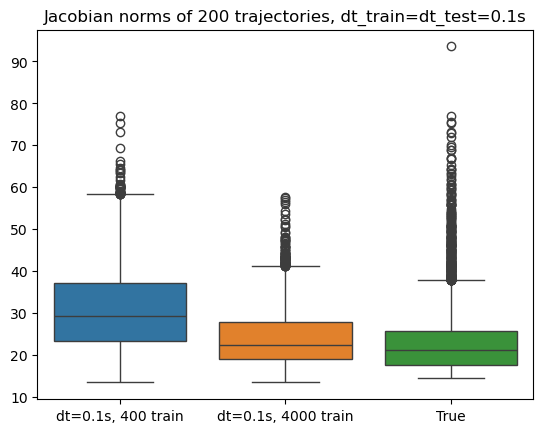

In [63]:
sns.boxplot(pd.DataFrame({
    #"dt=0.01s": jac_baseline_lorenz_001,
    "dt=0.1s, 400 train": jac_baseline_lorenz_01_400,
    "dt=0.1s, 4000 train": jac_baseline_lorenz_01_4000,
    "True": jac_true_lorenz_01
}))
plt.title("Jacobian norms of 200 trajectories, dt_train=dt_test=0.1s")

- With only 400 data points, we see that the jacobian norms are too high although the Lipschitz constant is respected. -> **Here maybe our jacobian loss could be of use.**
- With 4000 data points, the median is better estimated although we do not reach some extreme values. The Lipschitz constant is also respected.



Text(0.5, 1.0, 'Jacobian norms of 200 trajectories, dt_train=dt_test=0.01s')

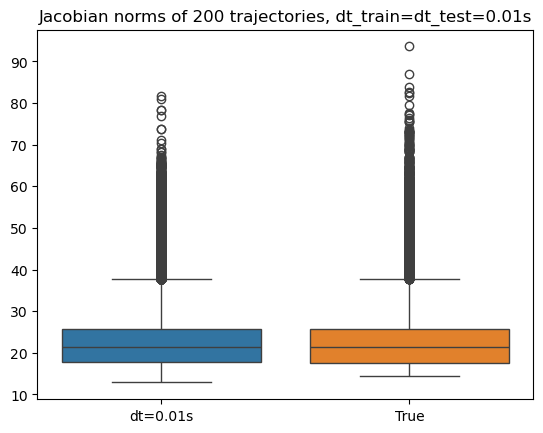

In [65]:
sns.boxplot(pd.DataFrame({
    "dt=0.01s": jac_baseline_lorenz_001,
    "True": jac_true_lorenz_001
}))
plt.title("Jacobian norms of 200 trajectories, dt_train=dt_test=0.01s")

The estimation of the jacobian norms is almost perfect, and more extreme values are recovered contrary to before. 

Text(0.5, 1.0, 'Jacobian norms of true trajectories, different dt')

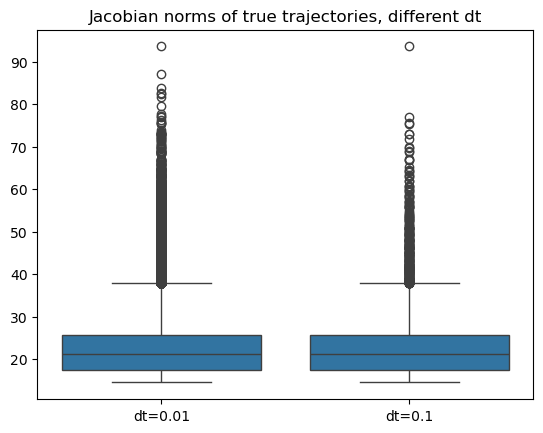

In [67]:
sns.boxplot(pd.DataFrame({
    "dt=0.01": jac_true_lorenz_001,
    
}))
sns.boxplot(pd.DataFrame({
    "dt=0.1": jac_true_lorenz_01,
    
}))
plt.title("Jacobian norms of true trajectories, different dt")

In [69]:
print(f"Min:dt=0.1:{jac_true_lorenz_01.min()}, dt=0.01:{jac_true_lorenz_001.min()}")
print(f"Max:dt=0.1:{jac_true_lorenz_01.max()}, dt=0.01:{jac_true_lorenz_001.max()}")
print(f"Mean:dt=0.1:{jac_true_lorenz_01.mean()}, dt=0.01:{jac_true_lorenz_001.mean()}")
print(f"Median:dt=0.1:{np.median(jac_true_lorenz_01)}, dt=0.01:{np.median(jac_true_lorenz_001)}")

Min:dt=0.1:14.543402931305366, dt=0.01:14.51036660188019
Max:dt=0.1:93.57844743373494, dt=0.01:93.57844743373494
Mean:dt=0.1:21.978607547026414, dt=0.01:21.96887213685929
Median:dt=0.1:21.286394988253544, dt=0.01:21.277138077636593


Statistics are preserved, some extreme values are not represented when dt=0.1

Text(0.5, 1.0, 'on true trajectories, different N')

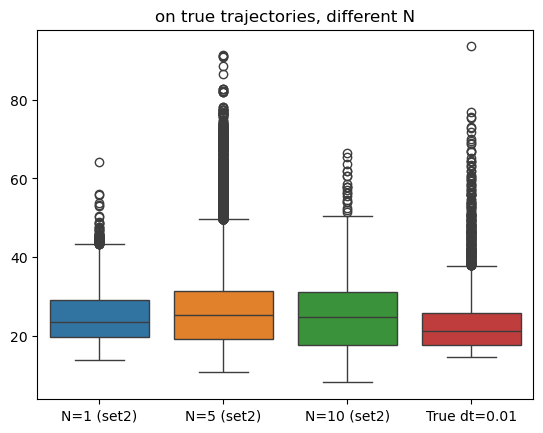

In [1050]:
sns.boxplot(pd.DataFrame({
    "N=1 (set2)": jac_baseline_lorenz_01_set2,
    "N=5 (set2)": jac_baseline_lorenz_05_set2,
    "N=10 (set2)": jac_baseline_lorenz_1_set2,
    #"True dt=0.1": jac_true_lorenz_01_dt01,
    "True dt=0.01": jac_true_lorenz_01
}))
plt.title('on true trajectories, different N')

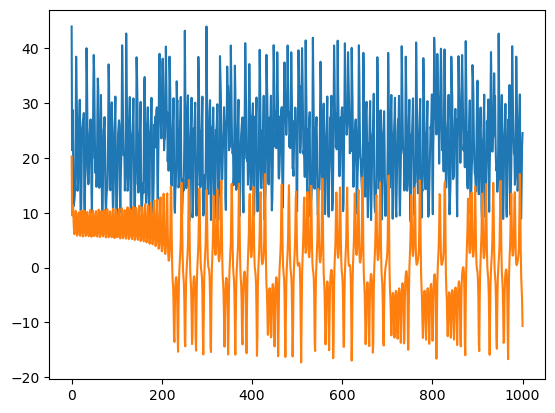

In [1041]:
plt.plot(jac_baseline_lorenz_1_set2_own.reshape(200,-1)[195,:])
plt.plot(jac_.reshape(200,-1)[195,:])

Text(0.5, 1.0, 'on their own predicted trajectories, different N')

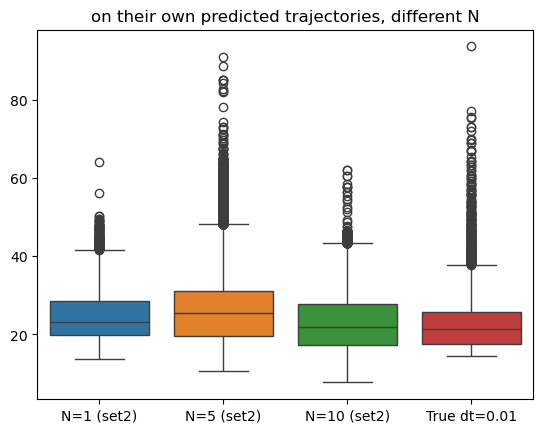

In [1051]:
sns.boxplot(pd.DataFrame({
    "N=1 (set2)": jac_baseline_lorenz_01_set2_own,
    "N=5 (set2)": jac_baseline_lorenz_05_set2_own,
    "N=10 (set2)": jac_baseline_lorenz_1_set2_own,
    "True dt=0.01": jac_true_lorenz_01
}))
plt.title('on their own predicted trajectories, different N')

Text(0.5, 1.0, 'on own trajectories, different N, cutoff norm <500')

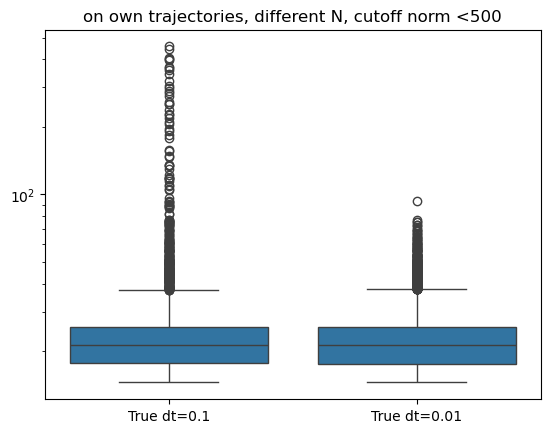

In [1066]:
sns.boxplot(pd.DataFrame({
    "True dt=0.1": jac_true_lorenz_01_dt01[jac_true_lorenz_01_dt01 <500],
    
}))
sns.boxplot(pd.DataFrame({
    "True dt=0.01": jac_true_lorenz_01}))
plt.yscale("log")
plt.title('on own trajectories, different N, cutoff norm <500')

## 3. Eigenvalues of $J_{F_\theta}$

In [76]:
true_eigensL_001 = jax.vmap(lambda x: get_eigenvalues_jacobian(F_lorenz, x))(yL_100s_001)
true_eigensL_01 = jax.vmap(lambda x: get_eigenvalues_jacobian(F_lorenz, x))(yL_100s_01)

In [1067]:
true_eigensL_dt01 = jax.vmap(lambda x: get_eigenvalues_jacobian(F_lorenz, x))(yL_100s_01_dt01)

Text(0.5, 1.0, 'time=6')

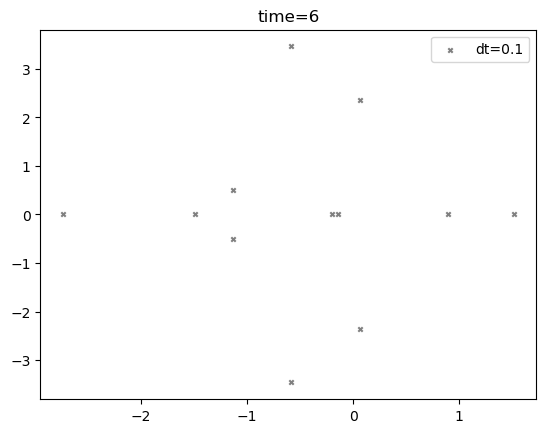

In [1131]:
fig, ax = plt.subplots()#plot_stability_domains()
time=4
ax.scatter(true_eigensL_dt01.reshape(200,1001,-1)[195,:time,:].real*dtL, true_eigensL_dt01.reshape(200,1001,-1)[195,:time,:].imag*dtL, label="dt=0.1", color='grey', s=10, marker="x", alpha=1)
#ax.scatter(true_eigensL_01.reshape(200,1001,-1)[195,:time,:].real, true_eigensL_01.reshape(200,1001,-1)[195,:time,:].imag, label="dt=0.01", color='red', s=10, marker="x", alpha=1)
plt.legend()
plt.title("time=6")

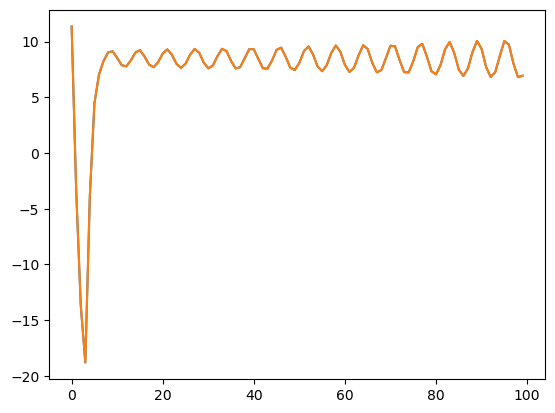

In [1138]:
time=100
plt.plot(data_true_lorenz_dt01["y_true"][195][:time,0], label="true")
plt.plot(data_lorenz_01["y_true"][195][:time*10:10,0], label="true")

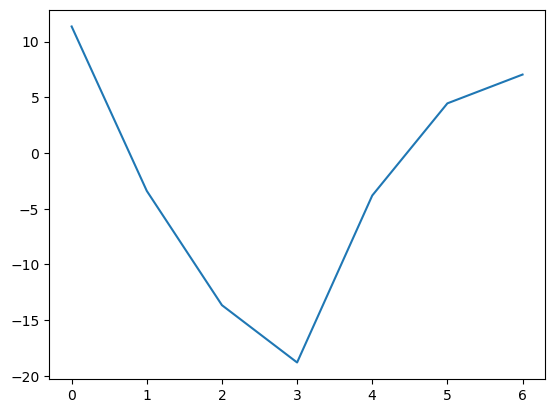

In [1153]:
time=7
yrk4_01, _,_,_ = RK_solver_fixed(F_lorenz, data_true_lorenz_dt01["y_pred"][195][0,:], dt=0.1, num_steps=1000, tableau=RK_tableaux["RK4"] )
yrk4_001, _,_,_ = RK_solver_fixed(F_lorenz, data_true_lorenz_dt01["y_pred"][195][0,:], dt=0.01, num_steps=10000, tableau=RK_tableaux["RK4"] )
#plt.plot(yrk4_01[0,:time], label="RK4, true F, dt=0.1")
plt.plot(yrk4_001[0,:time*10:10], label="RK4, true F, dt=0.01")

/Users/mayajanvier/.conda/envs/jax_env/lib/python3.10/site-packages/IPython/core/events.py:89: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  func(*args, **kwargs)
/Users/mayajanvier/.conda/envs/jax_env/lib/python3.10/site-packages/IPython/core/pylabtools.py:152: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


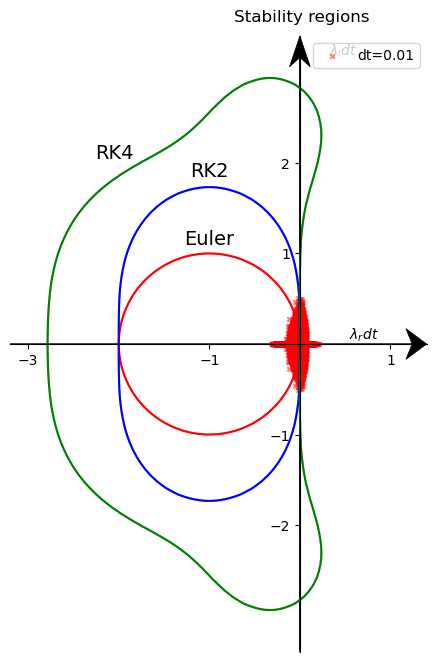

In [1173]:
fig, ax = plot_stability_domains()
#ax.scatter(true_eigensL_01.real*dtL, true_eigensL_01.imag*dtL, label="dt=0.1", color='grey', s=10, marker="x", alpha=0.1)
ax.scatter(true_eigensL_001.real*dtL_num, true_eigensL_001.imag*dtL_num, label="dt=0.01", color='red', s=10, marker="x", alpha=0.5)
plt.legend()

/Users/mayajanvier/.conda/envs/jax_env/lib/python3.10/site-packages/IPython/core/events.py:89: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  func(*args, **kwargs)
/Users/mayajanvier/.conda/envs/jax_env/lib/python3.10/site-packages/IPython/core/pylabtools.py:152: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


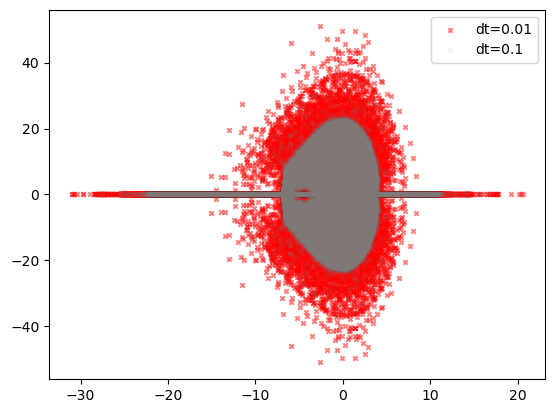

In [83]:
fig, ax = plt.subplots()
ax.scatter(true_eigensL_001.real, true_eigensL_001.imag, label="dt=0.01", color='red', s=10, marker="x", alpha=0.5)
ax.scatter(true_eigensL_01.real, true_eigensL_01.imag, label="dt=0.1", color='grey', s=10, marker="x", alpha=0.1)
plt.legend()


- On a bien les valeurs propres de la jacobienne pour les points de trajectoire dt=0.1 inclus dans ceux des trajectoires dt=0.01. 
- Pour dt=0.1, de nombreuses valeurs propres sont à partie réelle positive mais pas seulement. On observe aussi des valeurs en-dehors du domaine de stabilité de RK4, bien qu'à partie réelle négative. Cela explique les instabilités vues lorsque qu'on prédit avec le bon F mais dt=0.1. 

In [90]:
eigensL_001_001 = jax.vmap(lambda x: get_eigenvalues_jacobian(model_baseline_lorenz_001.model_aug, x))(yL_100s_001)
eigensL_001_01 = jax.vmap(lambda x: get_eigenvalues_jacobian(model_baseline_lorenz_001.model_aug, x))(yL_100s_01)

eigensL_01_400_001 = jax.vmap(lambda x: get_eigenvalues_jacobian(model_baseline_lorenz_01_400.model_aug, x))(yL_100s_001)
eigensL_01_400_01 = jax.vmap(lambda x: get_eigenvalues_jacobian(model_baseline_lorenz_01_400.model_aug, x))(yL_100s_01)

eigensL_01_4000_001 = jax.vmap(lambda x: get_eigenvalues_jacobian(model_baseline_lorenz_01_4000.model_aug, x))(yL_100s_001)
eigensL_01_4000_01 = jax.vmap(lambda x: get_eigenvalues_jacobian(model_baseline_lorenz_01_4000.model_aug, x))(yL_100s_01)

In [ ]:
# own predictions


In [1154]:
eigens_01_set2 = jax.vmap(lambda x: get_eigenvalues_jacobian(model_baseline_lorenz_01_set2.model_aug, x))(yL_100s_01)
eigens_05_set2 = jax.vmap(lambda x: get_eigenvalues_jacobian(model_baseline_lorenz_05_set2.model_aug, x))(yL_100s_01)
eigens_1_set2 = jax.vmap(lambda x: get_eigenvalues_jacobian(model_baseline_lorenz_1_set2.model_aug, x))(yL_100s_01)
eigens_01_set2_own = jax.vmap(lambda x: get_eigenvalues_jacobian(model_baseline_lorenz_01_set2.model_aug, x))(yL_01_set2_pred)  
eigens_05_set2_own = jax.vmap(lambda x: get_eigenvalues_jacobian(model_baseline_lorenz_05_set2.model_aug, x))(yL_05_set2_pred)
eigens_1_set2_own = jax.vmap(lambda x: get_eigenvalues_jacobian(model_baseline_lorenz_1_set2.model_aug, x))(yL_1_set2_pred)


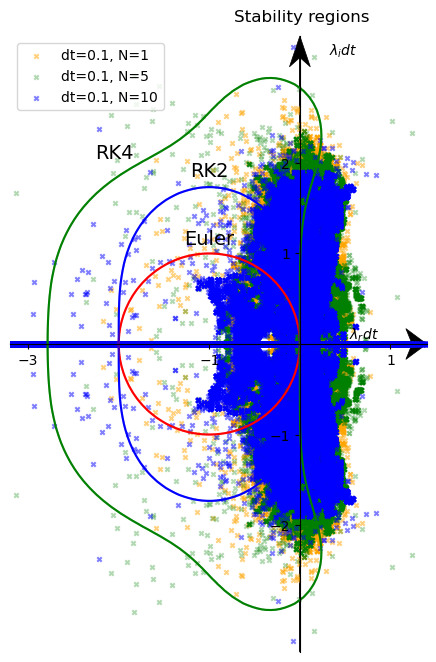

In [1176]:
fig, ax = plot_stability_domains()
#fig, ax = plt.subplots(4,1, sharex=True, sharey=True, figsize=(8,12))
#ax.scatter(true_eigensL_01.real*dtL, true_eigensL_01.imag*dtL, label="dt=0.01, True F", color='grey', s=10, marker="x", alpha=0.5)
ax.scatter(eigens_01_set2_own.real*dtL, eigens_01_set2_own.imag*dtL, label="dt=0.1, N=1", color='orange', s=10, marker="x", alpha=0.5)
ax.scatter(eigens_05_set2_own.real*dtL, eigens_05_set2_own.imag*dtL, label="dt=0.1, N=5", color='green', s=10, marker="x", alpha=0.3)
ax.scatter(eigens_1_set2_own.real*dtL, eigens_1_set2_own.imag*dtL, label="dt=0.1, N=10", color='blue', s=10, marker="x", alpha=0.5)
# for i in range(4):
#     ax[i].legend()
ax.legend()

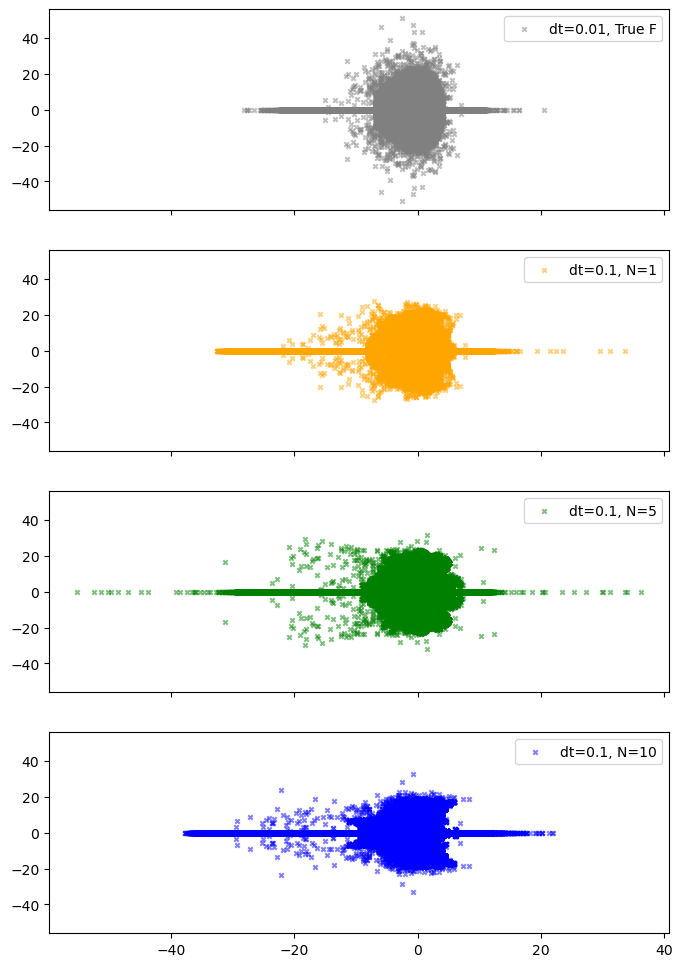

In [1164]:
#fig, ax = plot_stability_domains()
fig, ax = plt.subplots(4,1, sharex=True, sharey=True, figsize=(8,12))
ax[0].scatter(true_eigensL_01.real, true_eigensL_01.imag, label="dt=0.01, True F", color='grey', s=10, marker="x", alpha=0.5)
ax[1].scatter(eigens_01_set2_own.real, eigens_01_set2_own.imag, label="dt=0.1, N=1", color='orange', s=10, marker="x", alpha=0.5)
ax[2].scatter(eigens_05_set2_own.real, eigens_05_set2_own.imag, label="dt=0.1, N=5", color='green', s=10, marker="x", alpha=0.5)
ax[3].scatter(eigens_1_set2_own.real, eigens_1_set2_own.imag, label="dt=0.1, N=10", color='blue', s=10, marker="x", alpha=0.5)
for i in range(4):
    ax[i].legend()

In [1168]:
def plot_time_shots_eigen_trajLorenz(id_traj, times, eigens_val, baseline, color, true_traj=False):
    for i, time in enumerate(times):
        fig, ax = plt.subplots(2,1, figsize=(5,5))
        if i == 1:
            old_time = times[0]
        vp_real, vp_imag = eigens_val.reshape(200,-1,3)[id_traj,:time,:].real, eigens_val.reshape(200,-1,3)[id_traj,:time,:].imag
        ax[1].plot(vp_real, vp_imag, 'x', label=f"time={time}", color=color )
        if true_traj:
            ax[0].plot(baseline["y_true"][id_traj][:time,0], label=f"time={time}", color=color)
        else:
            ax[0].plot(baseline["y_pred"][id_traj][:time,0], label=f"time={time}", color=color)
        fig.suptitle(f"Trajectory {id_traj}, time={time}")
        ax[1].set_xlim([-10, 10])
        ax[1].set_ylim([-10, 10])
        if i > 0:
            vp_real_new, vp_imag_new = eigens_val.reshape(200,-1,3)[id_traj,old_time:time,:].real, eigens_val.reshape(200,-1,3)[id_traj,old_time:time,:].imag
            ax[0].plot(baseline["y_pred"][id_traj][old_time:time,0], label=f"time={time} new", color='red')
            ax[1].plot(vp_real_new, vp_imag_new, 'x', label=f"time={time} new", color='red')
            old_time = time
            plt.show()

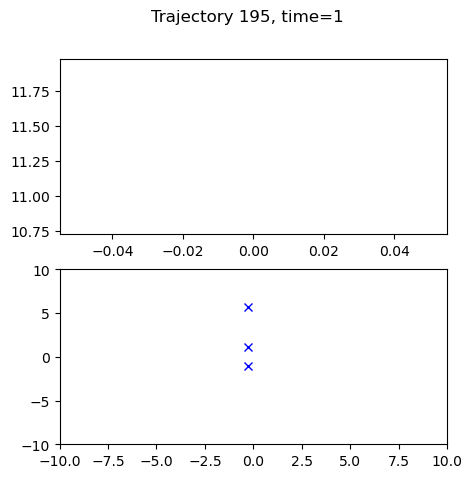

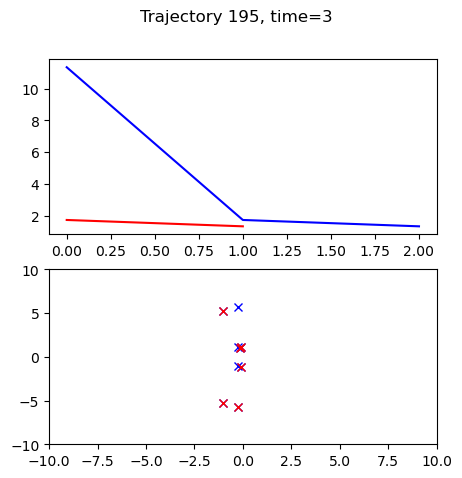

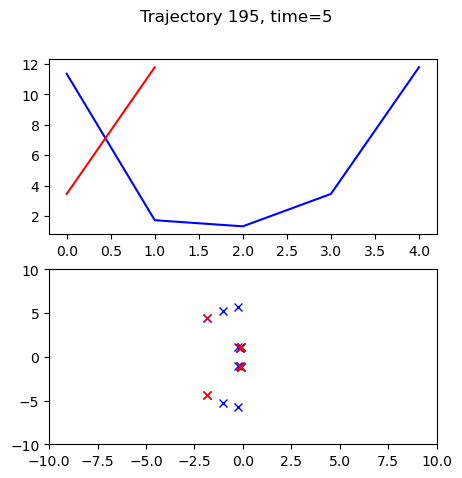

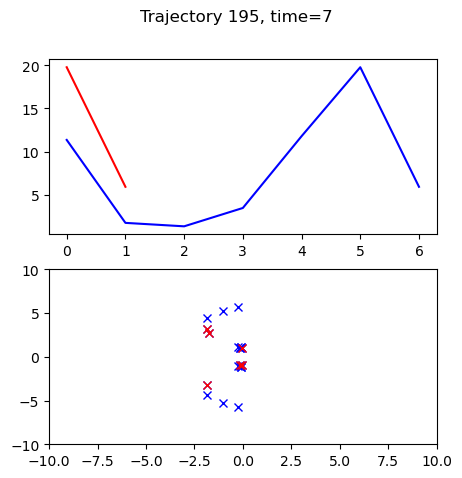

In [1170]:
plot_time_shots_eigen_trajLorenz(195,[1,3,5,7], eigens_01_own, data_lorenz_01_01_set2, color="blue", )

/Users/mayajanvier/jax-phynity/metrics.py:296: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


Text(0.7, 1.0, 'NN trained with dt_train=0.01s')

/Users/mayajanvier/.conda/envs/jax_env/lib/python3.10/site-packages/IPython/core/events.py:89: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  func(*args, **kwargs)
/Users/mayajanvier/.conda/envs/jax_env/lib/python3.10/site-packages/IPython/core/pylabtools.py:152: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


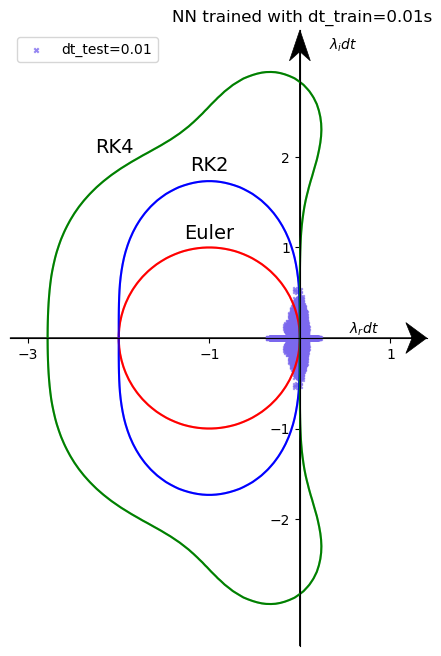

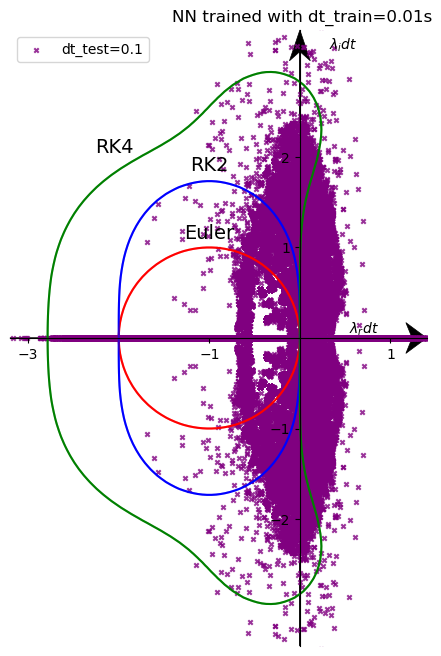

In [117]:
fig, ax = plot_stability_domains()
ax.scatter(eigensL_001_001.real*dtL_num, eigensL_001_001.imag*dtL_num, label="dt_test=0.01", color='mediumslateblue', s=10, marker="x", alpha=0.8)
plt.legend()
plt.title("NN trained with dt_train=0.01s")

fig, ax = plot_stability_domains()
ax.scatter(eigensL_001_01.real*dtL, eigensL_001_01.imag*dtL, label="dt_test=0.1", color='purple', s=10, marker="x", alpha=0.8)
plt.legend()
plt.title("NN trained with dt_train=0.01s")


We see that indeed our hypothesis that the eigenvalues end up outside of the stability domain when dt=0.1 is true. 

/Users/mayajanvier/.conda/envs/jax_env/lib/python3.10/site-packages/IPython/core/events.py:89: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  func(*args, **kwargs)
/Users/mayajanvier/.conda/envs/jax_env/lib/python3.10/site-packages/IPython/core/pylabtools.py:152: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


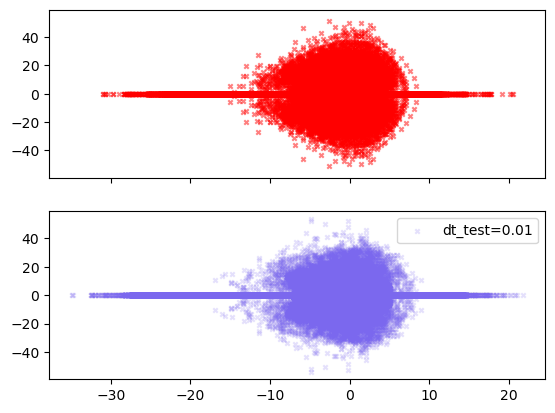

In [108]:
fig, ax = plt.subplots(2, sharex=True, sharey=True)
ax[0].scatter(true_eigensL_001.real, true_eigensL_001.imag, label="True", color='red', s=10, marker="x", alpha=0.5)
ax[1].scatter(eigensL_001_001.real, eigensL_001_001.imag, label="dt_test=0.01", color='mediumslateblue', s=10, marker="x", alpha=0.2)
#ax.scatter(eigensL_001_01.real, eigensL_001_01.imag, label="dt_test=0.1", color='purple', s=10, marker="x", alpha=0.3)
plt.legend()

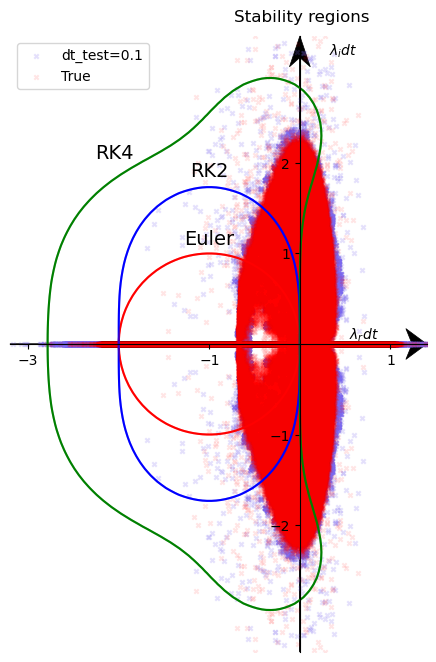

In [120]:
fig, ax = plot_stability_domains()
ax.scatter(eigensL_001_01.real*dtL, eigensL_001_01.imag*dtL, label="dt_test=0.1", color='mediumslateblue', s=10, marker="x", alpha=0.2)
ax.scatter(true_eigensL_01.real*dtL, true_eigensL_01.imag*dtL, label="True", color='red', s=10, marker="x", alpha=0.1)
#ax.scatter(eigensL_001_01.real, eigensL_001_01.imag, label="dt_test=0.1", color='purple', s=10, marker="x", alpha=0.3)
plt.legend()

Draw convex hull of both 

KeyboardInterrupt: 

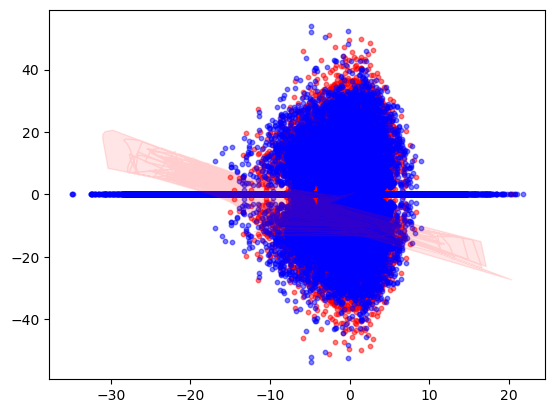

In [106]:
import numpy as np
from scipy.spatial import ConvexHull
import matplotlib.pyplot as plt

def draw_envelope_safe(x, y, ax, color, alpha=0.1):
    points = np.column_stack((x, y))
    if len(points) < 3:
        return  # not enough points

    # Add a tiny jitter to avoid QHull precision errors
    points += 1e-10 * np.random.randn(*points.shape)

    try:
        hull = ConvexHull(points, qhull_options='QJ')  # "QJ" joggles input
        hull_points = points[hull.vertices]
        hull_points = np.concatenate([hull_points, hull_points[:1]])
        ax.fill(hull_points[:, 0], hull_points[:, 1], color=color, alpha=alpha)
    except Exception as e:
        print("ConvexHull failed:", e)

# Example usage:
fig, ax = plt.subplots()
ax.scatter(true_eigensL_001.real, true_eigensL_001.imag, color='red', s=10, alpha=0.5)
ax.scatter(eigensL_001_001.real, eigensL_001_001.imag, color='blue', s=10, alpha=0.5)

draw_envelope_safe(true_eigensL_001.real, true_eigensL_001.imag, ax, color='red', alpha=0.1)
draw_envelope_safe(eigensL_001_001.real, eigensL_001_001.imag, ax, color='blue', alpha=0.1)

plt.show()


In [111]:
true_eigensL_001.real.min(), true_eigensL_001.real.max(), eigensL_001_001.real.min(), eigensL_001_001.real.max()
#true_eigensL_001.imag.min(), true_eigensL_001.imag.max(), eigensL_001_001.imag.min(), eigensL_001_001.imag.max()

(Array(-31.0280009, dtype=float64),
 Array(20.57803311, dtype=float64),
 Array(-34.93058403, dtype=float64),
 Array(21.72040782, dtype=float64))

Eigenvalues 


Sanity check: dt=0.1 eigenvalues included in dt=0.01 eigenvalues

Text(0.7, 1.0, 'NN trained with dt_train=0.1s')

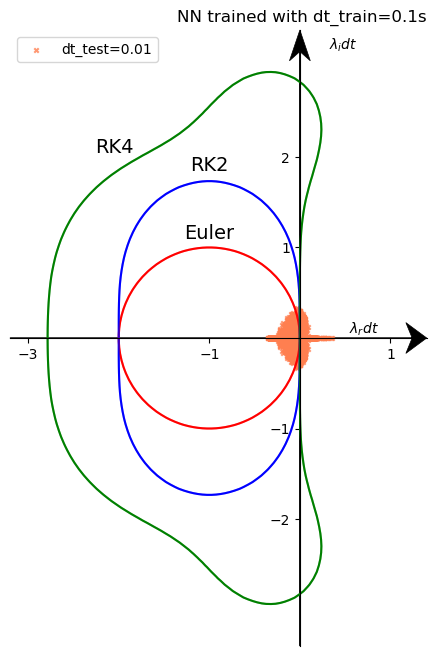

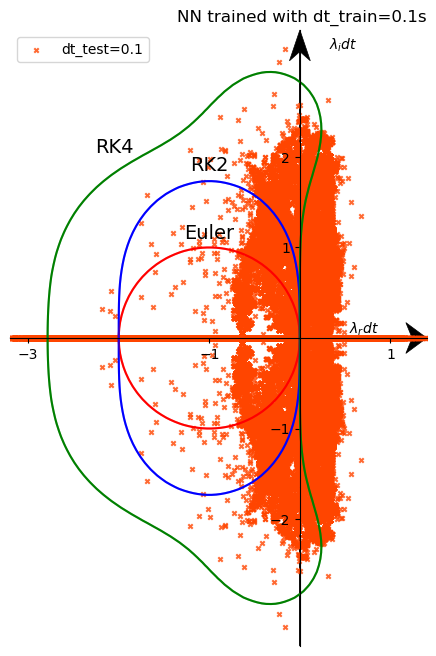

In [96]:
fig, ax = plot_stability_domains()
ax.scatter(eigensL_01_4000_001.real*dtL_num, eigensL_01_4000_001.imag*dtL_num, label="dt_test=0.01", color='coral', s=10, marker="x", alpha=0.8)
plt.legend()
plt.title("NN trained with dt_train=0.1s")

fig, ax = plot_stability_domains()
ax.scatter(eigensL_01_4000_01.real*dtL, eigensL_01_4000_01.imag*dtL, label="dt_test=0.1", color='orangered', s=10, marker="x", alpha=0.8)
plt.legend()
plt.title("NN trained with dt_train=0.1s")


Text(0.5, 1.0, 'dt_test=0.01s')

/Users/mayajanvier/.conda/envs/jax_env/lib/python3.10/site-packages/IPython/core/events.py:89: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  func(*args, **kwargs)
/Users/mayajanvier/.conda/envs/jax_env/lib/python3.10/site-packages/IPython/core/pylabtools.py:152: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


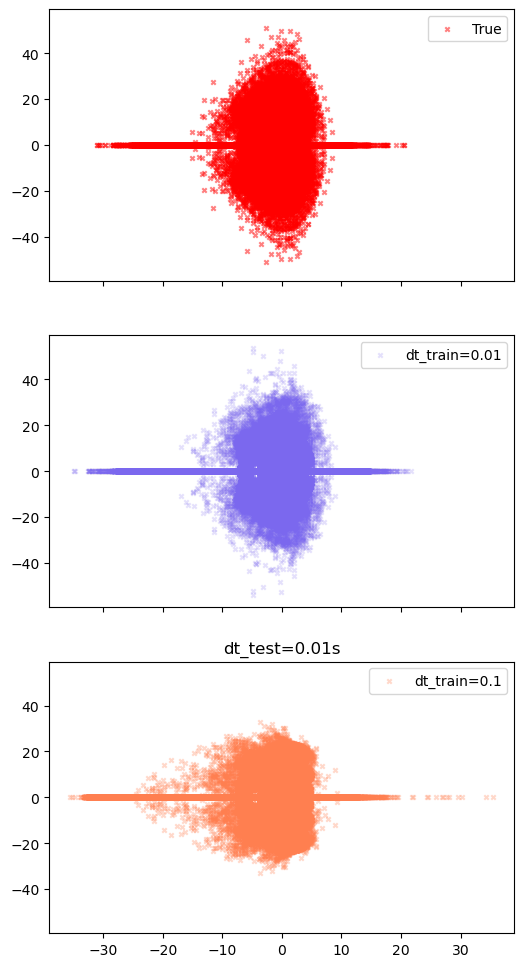

In [124]:
fig, ax = plt.subplots(3, sharex=True, sharey=True, figsize=(6,12))
ax[0].scatter(true_eigensL_001.real, true_eigensL_001.imag, label="True", color='red', s=10, marker="x", alpha=0.5)
ax[1].scatter(eigensL_001_001.real, eigensL_001_001.imag, label="dt_train=0.01", color='mediumslateblue', s=10, marker="x", alpha=0.2)
ax[2].scatter(eigensL_01_4000_001.real, eigensL_01_4000_001.imag, label="dt_train=0.1", color='coral', s=10, marker="x", alpha=0.3)
for i in range(3):
    ax[i].legend()
plt.title("dt_test=0.01s")

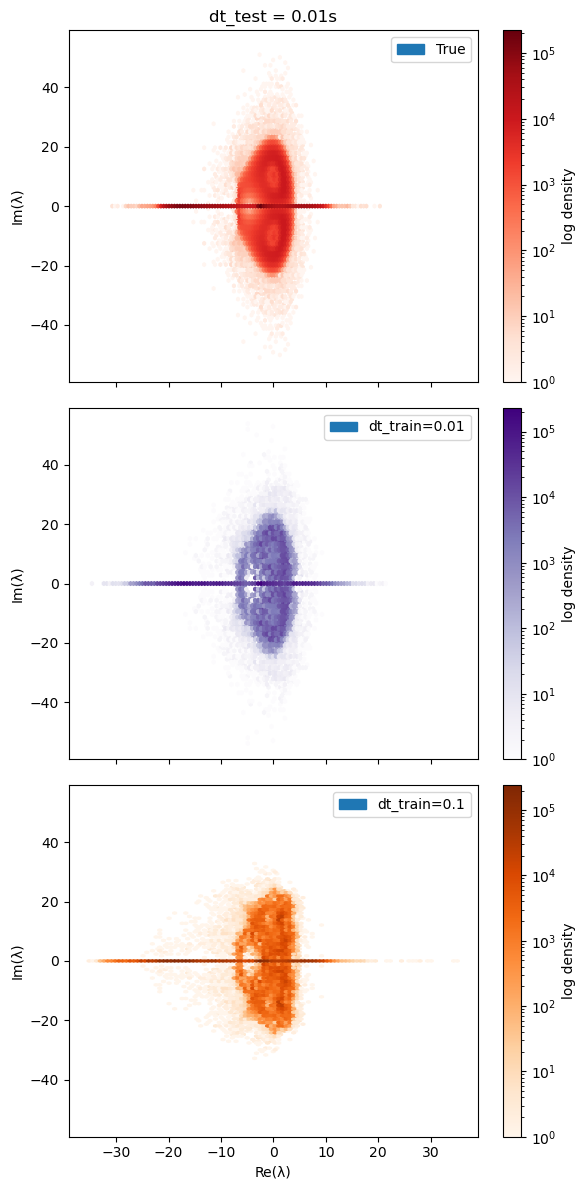

In [130]:
fig, ax = plt.subplots(3, sharex=True, sharey=True, figsize=(6, 12))

datasets = [
    (true_eigensL_001, "True", "Reds"),
    (eigensL_001_001, "dt_train=0.01", "Purples"),
    (eigensL_01_4000_001, "dt_train=0.1", "Oranges")
]

for i, (data, label, cmap) in enumerate(datasets):
    hb = ax[i].hexbin(
        data.real, data.imag,
        gridsize=100, cmap=cmap, bins='log'
    )
    ax[i].legend([label])
    fig.colorbar(hb, ax=ax[i], label='log density')

ax[0].set_title("dt_test = 0.01s")
ax[-1].set_xlabel("Re(λ)")
for a in ax:
    a.set_ylabel("Im(λ)")

plt.tight_layout()
plt.show()


In [123]:
len(np.where(eigensL_001_001.real >0)[0]), len(np.where(eigensL_01_4000_001.real >0)[0]), len(np.where(true_eigensL_001.real >0)[0])

(2177912, 2338348, 2175773)

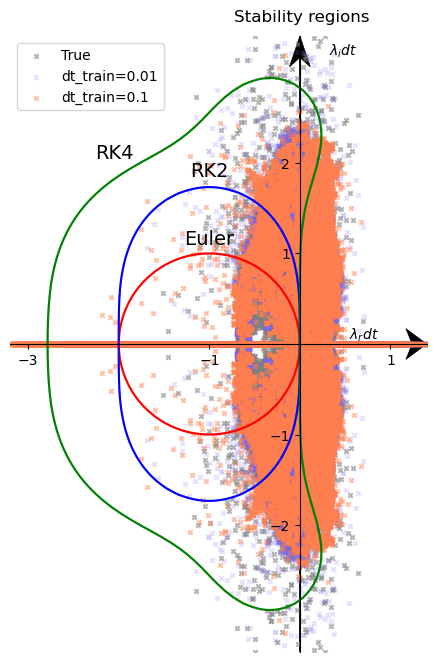

In [129]:
fig, ax = plot_stability_domains()
ax.scatter(true_eigensL_01.real*dtL, true_eigensL_01.imag*dtL, label="True", color='grey', s=10, marker="x", alpha=0.6)
ax.scatter(eigensL_001_01.real*dtL, eigensL_001_01.imag*dtL, label="dt_train=0.01", color='mediumslateblue', s=10, marker="x", alpha=0.2)
ax.scatter(eigensL_01_4000_01.real*dtL, eigensL_01_4000_01.imag*dtL, label="dt_train=0.1", color='coral', s=10, marker="x", alpha=0.5)
plt.legend()

Extreme imaginary parts are contained when trained with dt=0.1, although more real parts are positive or too negative for RK4 stability region.

Text(0.5, 1.0, 'dt_test=0.01s')

/Users/mayajanvier/.conda/envs/jax_env/lib/python3.10/site-packages/IPython/core/events.py:89: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  func(*args, **kwargs)
/Users/mayajanvier/.conda/envs/jax_env/lib/python3.10/site-packages/IPython/core/pylabtools.py:152: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


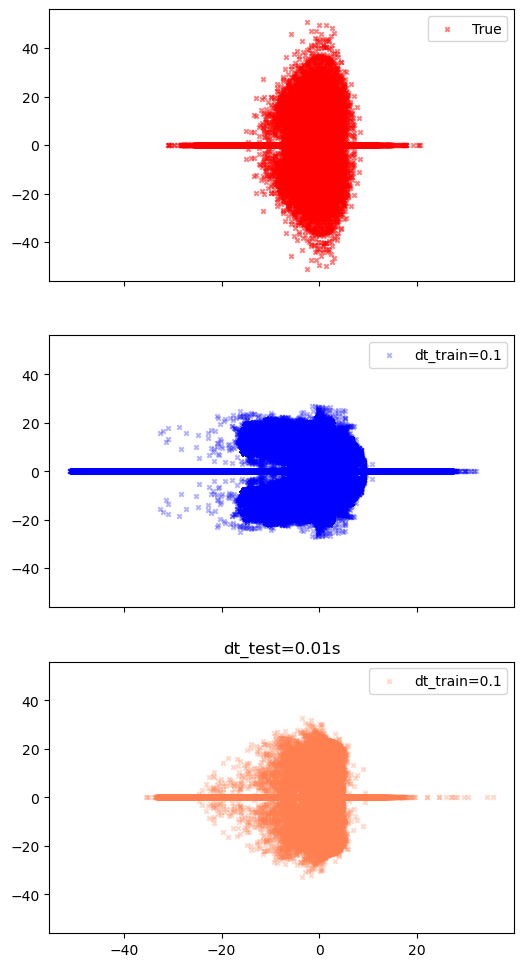

In [133]:
fig, ax = plt.subplots(3, sharex=True, sharey=True, figsize=(6,12))
ax[0].scatter(true_eigensL_001.real, true_eigensL_001.imag, label="True", color='red', s=10, marker="x", alpha=0.5)
ax[1].scatter(eigensL_01_400_001.real, eigensL_01_400_001.imag, label="dt_train=0.1", color='blue', s=10, marker="x", alpha=0.3)
ax[2].scatter(eigensL_01_4000_001.real, eigensL_01_4000_001.imag, label="dt_train=0.1", color='coral', s=10, marker="x", alpha=0.3)
for i in range(3):
    ax[i].legend()
plt.title("dt_test=0.01s")

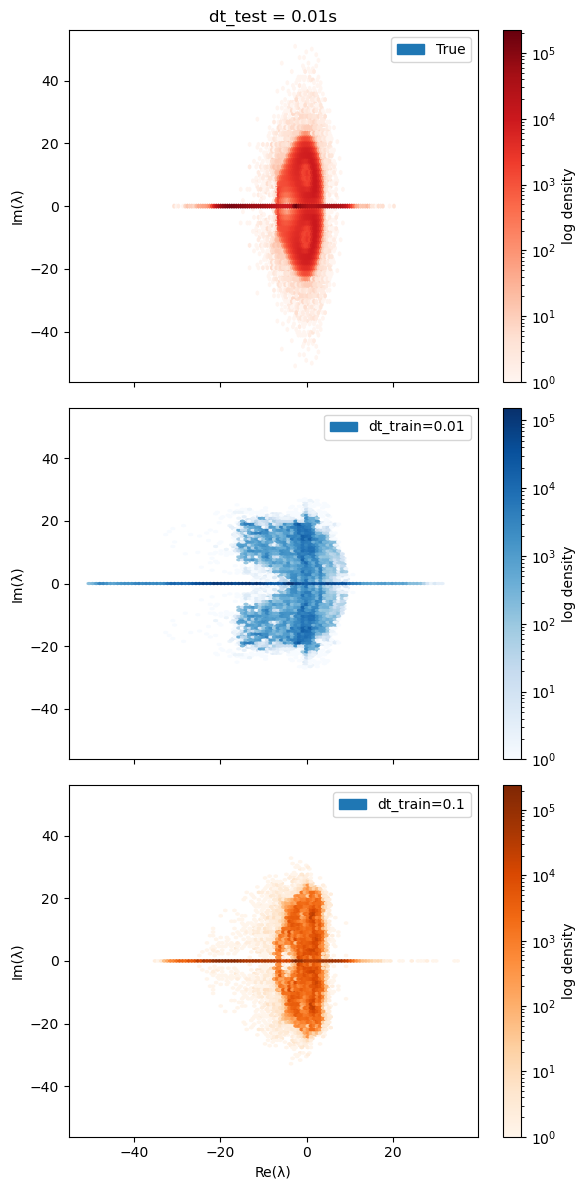

In [134]:
fig, ax = plt.subplots(3, sharex=True, sharey=True, figsize=(6, 12))

datasets = [
    (true_eigensL_001, "True", "Reds"),
    (eigensL_01_400_001, "dt_train=0.01", "Blues"),
    (eigensL_01_4000_001, "dt_train=0.1", "Oranges")
]

for i, (data, label, cmap) in enumerate(datasets):
    hb = ax[i].hexbin(
        data.real, data.imag,
        gridsize=100, cmap=cmap, bins='log'
    )
    ax[i].legend([label])
    fig.colorbar(hb, ax=ax[i], label='log density')

ax[0].set_title("dt_test = 0.01s")
ax[-1].set_xlabel("Re(λ)")
for a in ax:
    a.set_ylabel("Im(λ)")

plt.tight_layout()
plt.show()


### N=50 vs N=1
dt=0.1: no explosion of error but N=1 yes: what does the eigenvalues look like ? 

In [631]:
experiment_path50L = "/Users/mayajanvier/jax-phynity/data_exp/lorenz_gridsearch/none_aug_0.5_6_az5bbul5"
model_baseline_lorenz_05 = load_best_model_dt(dtL_num, experiment_path50L, "lorenz", integration_method, data_integration_method="RK4", dt_num=0.01, duration=100)

/Users/mayajanvier/jax-phynity/data_exp/lorenz_gridsearch/none_aug_0.5_6_az5bbul5/model_2.792e+01.eqx
{'dt': 0.01, 'test data dt': 0.01, 'dt factor': 1}


In [634]:
eigensL_05_001 = jax.vmap(lambda x: get_eigenvalues_jacobian(model_baseline_lorenz_05.model_aug, x))(yL_100s_001)

Error in callback <function _draw_all_if_interactive at 0x119e54a60> (for post_execute):


KeyboardInterrupt: 

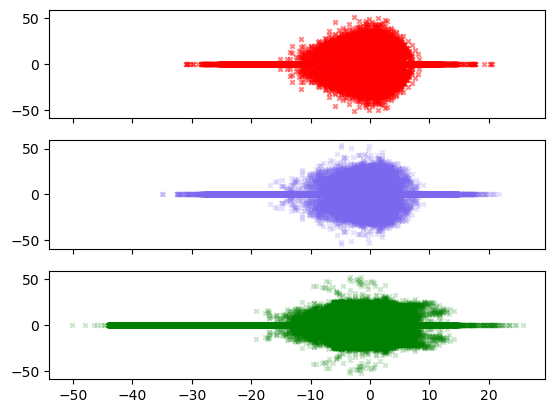

In [637]:
fig, ax = plt.subplots(3, sharex=True, sharey=True)
ax[0].scatter(true_eigensL_001.real, true_eigensL_001.imag, label="True", color='red', s=10, marker="x", alpha=0.5)
ax[1].scatter(eigensL_001_001.real, eigensL_001_001.imag, label="N=1", color='mediumslateblue', s=10, marker="x", alpha=0.2)
ax[2].scatter(eigensL_05_001.real, eigensL_05_001.imag, label="N=50", color='green', s=10, marker="x", alpha=0.2)



On dirait qu'avoir des parties réelles très négatives stabilise l'integration ?? 

### Eigenvalues of divergent trajectories

## 4. Offline errors

In [141]:
out_lorenz_001 = jax.vmap(F_lorenz)(yL_100s_001)
out_lorenz_01 = jax.vmap(F_lorenz)(yL_100s_01)

out_lorenz_001_001 = jax.vmap(model_baseline_lorenz_001.model_aug)(yL_100s_001)
out_lorenz_001_01 = jax.vmap(model_baseline_lorenz_001.model_aug)(yL_100s_01)

out_lorenz_01_400_001 = jax.vmap(model_baseline_lorenz_01_400.model_aug)(yL_100s_001)
out_lorenz_01_400_01 = jax.vmap(model_baseline_lorenz_01_400.model_aug)(yL_100s_01)

out_lorenz_01_4000_001 = jax.vmap(model_baseline_lorenz_01_4000.model_aug)(yL_100s_001)
out_lorenz_01_4000_01 = jax.vmap(model_baseline_lorenz_01_4000.model_aug)(yL_100s_01)

In [143]:
# errors
error_lorenz_001_001 = jnp.linalg.norm(out_lorenz_001 - out_lorenz_001_001, axis=1)
error_lorenz_001_01 = jnp.linalg.norm(out_lorenz_01 - out_lorenz_001_01, axis=1)
error_lorenz_01_400_001 = jnp.linalg.norm(out_lorenz_001 - out_lorenz_01_400_001, axis=1)
error_lorenz_01_400_01 = jnp.linalg.norm(out_lorenz_01 - out_lorenz_01_400_01, axis=1)
error_lorenz_01_4000_001 = jnp.linalg.norm(out_lorenz_001 - out_lorenz_01_4000_001, axis=1)
error_lorenz_01_4000_01 = jnp.linalg.norm(out_lorenz_01 - out_lorenz_01_4000_01, axis=1)

In [149]:
print("error lorenz dt_train=0.01, dt_test=0.01", error_lorenz_001_001.mean(), "error lorenz dt_train=0.01, dt_test=0.1", error_lorenz_001_01.mean())
print("error lorenz dt_train= 0.1, dt_test=0.01", error_lorenz_01_400_001.mean(), "error lorenz dt_train=0.1, dt_test=0.1", error_lorenz_01_400_01.mean())
print("error lorenz dt_train= 0.1, dt_test=0.01", error_lorenz_01_4000_001.mean(), "error lorenz dt_train=0.1, dt_test=0.1", error_lorenz_01_4000_01.mean())

error lorenz dt_train=0.01, dt_test=0.01 1.6665851997022467 error lorenz dt_train=0.01, dt_test=0.1 1.6903472395385957
error lorenz dt_train= 0.1, dt_test=0.01 63.4429932426972 error lorenz dt_train=0.1, dt_test=0.1 63.590493998464744
error lorenz dt_train= 0.1, dt_test=0.01 4.312329204538381 error lorenz dt_train=0.1, dt_test=0.1 4.460508128044056


- Error of 400 data points driven by offline error: $F$ is not learnt yet, **maybe learning $J_F$ can help here**
- Smaller dt allow better learning of $F$

In [150]:
# J_F errors
jacobian_lorenz_001_001 = jax.vmap(jax.jacfwd(model_baseline_lorenz_001.model_aug))(yL_100s_001)
jacobian_lorenz_001_01 = jax.vmap(jax.jacfwd(model_baseline_lorenz_001.model_aug))(yL_100s_01)

jacobian_lorenz_01_400_001 = jax.vmap(jax.jacfwd(model_baseline_lorenz_01_400.model_aug))(yL_100s_001)
jacobian_lorenz_01_400_01 = jax.vmap(jax.jacfwd(model_baseline_lorenz_01_400.model_aug))(yL_100s_01)

jacobian_lorenz_01_4000_001 = jax.vmap(jax.jacfwd(model_baseline_lorenz_01_4000.model_aug))(yL_100s_001)
jacobian_lorenz_01_4000_01 = jax.vmap(jax.jacfwd(model_baseline_lorenz_01_4000.model_aug))(yL_100s_01)

In [153]:
jacobian_true_001 = jax.vmap(jax.jacfwd(F_lorenz))(yL_100s_001)
jacobian_true_01 = jax.vmap(jax.jacfwd(F_lorenz))(yL_100s_01)

In [157]:
# jacobian errors
error_jacobian_lorenz_001_001 = jnp.linalg.norm(jacobian_true_001 - jacobian_lorenz_001_001, axis=(1,2))
error_jacobian_lorenz_001_01 = jnp.linalg.norm(jacobian_true_01 - jacobian_lorenz_001_01, axis=(1,2))

error_jacobian_lorenz_01_400_001 = jnp.linalg.norm(jacobian_true_001 - jacobian_lorenz_01_400_001, axis=(1,2))
error_jacobian_lorenz_01_400_01 = jnp.linalg.norm(jacobian_true_01 - jacobian_lorenz_01_400_01, axis=(1,2))

error_jacobian_lorenz_01_4000_001 = jnp.linalg.norm(jacobian_true_001 - jacobian_lorenz_01_4000_001, axis=(1,2))
error_jacobian_lorenz_01_4000_01 = jnp.linalg.norm(jacobian_true_01 - jacobian_lorenz_01_4000_01, axis=(1,2))


In [158]:
print("error jacobian lorenz dt_train=0.01, dt_test=0.01", error_jacobian_lorenz_001_001.mean(), "error jacobian lorenz dt_train=0.01, dt_test=0.1", error_jacobian_lorenz_001_01.mean())
print("error jacobian lorenz dt_train= 0.1, dt_test=0.01", error_jacobian_lorenz_01_400_001.mean(), "error jacobian lorenz dt_train=0.1, dt_test=0.1", error_jacobian_lorenz_01_400_01.mean())
print("error jacobian lorenz dt_train= 0.1, dt_test=0.01", error_jacobian_lorenz_01_4000_001.mean(), "error jacobian lorenz dt_train=0.1, dt_test=0.1", error_jacobian_lorenz_01_4000_01.mean())

error jacobian lorenz dt_train=0.01, dt_test=0.01 1.7911222915626475 error jacobian lorenz dt_train=0.01, dt_test=0.1 1.7952731673362876
error jacobian lorenz dt_train= 0.1, dt_test=0.01 15.17235386752437 error jacobian lorenz dt_train=0.1, dt_test=0.1 15.174978657430643
error jacobian lorenz dt_train= 0.1, dt_test=0.01 3.89705784016485 error jacobian lorenz dt_train=0.1, dt_test=0.1 3.907724401092246


- For data points 4000, dt=0.1 and dt=0.01, errors on jacobian are really close to the offline error values
- For data points 400, dt=0.1, errors on jacobian are higher but smaller than offline errors